In [3]:
import polars as pl
import matplotlib.pyplot as plt

In [4]:
df = pl.read_csv(source="../data/diabetic_data.csv")

In [5]:
df.head()

encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
i64,i64,str,str,str,str,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2278392,8222157,"""Caucasian""","""Female""","""[0-10)""","""?""",6,25,1,1,"""?""","""Pediatrics-Endocrinology""",41,0,1,0,0,0,"""250.83""","""?""","""?""",1,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""NO"""
149190,55629189,"""Caucasian""","""Female""","""[10-20)""","""?""",1,1,7,3,"""?""","""?""",59,0,18,0,0,0,"""276""","""250.01""","""255""",9,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""",""">30"""
64410,86047875,"""AfricanAmerican""","""Female""","""[20-30)""","""?""",1,1,7,2,"""?""","""?""",11,5,13,2,0,1,"""648""","""250""","""V27""",6,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""NO"""
500364,82442376,"""Caucasian""","""Male""","""[30-40)""","""?""",1,1,7,2,"""?""","""?""",44,1,16,0,0,0,"""8""","""250.43""","""403""",7,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
16680,42519267,"""Caucasian""","""Male""","""[40-50)""","""?""",1,1,7,1,"""?""","""?""",51,0,8,0,0,0,"""197""","""157""","""250""",5,"""None""","""None""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""


In [6]:
# Remove unwanted columns and turn readmission into binary
df = df.drop("encounter_id","patient_nbr")

df = df.with_columns(
    pl.col("readmitted")
    .replace({
        "NO": 0,
        "<30": 1,
        ">30": 1
    }).cast(pl.Int64)
)

In [7]:
new_column_names = {
    "race" : "Race",
    "gender": "Gender",
    "age": "Age",
    "weight": "Weight",
    "admission_type_id": "Admission Type",
    "discharge_disposition_id": "Discharge Disposition",
    "admission_source_id": "Admission Source",
    "time_in_hospital": "Days Hospitalized",
    "payer_code": "Payer",
    "medical_specialty": "Doctor Specialization",
    "num_lab_procedures": "Total Lab Procedures",
    "num_procedures": "Total Non-Lab Procedures",
    "num_medications": "Total Medications",
    "number_outpatient": "Total Outpatient Visits",
    "number_emergency": "Total Emergency Visits",
    "number_inpatient": "Total Inpatient Visits",
    "diag_1": "Primary Diagnosis",
    "diag_2": "Secondary Diagnosis",
    "diag_3": "Additional Secondary Diagnosis",
    "number_diagnoses": "Total Diagnoses",
    "max_glu_serum": "Max Glucose Serum Result",
    "A1Cresult": "A1C Test Result",
    "metformin": "Metformin Dosage",
    "repaglinide": "Repaglinide Dosage",
    "nateglinide": "Nateglinide Dosage",
    "chlorpropamide": "Chlorproamide Dosage",
    "glimepiride": "Glimepiride Dosage",
    "acetohexamide": "Acetohexamide Dosage",
    "glipizide": "Glipizide Dosage",
    "glyburide": "Glyburide Dosage",
    "tolbutamide": "Tolbutamide Dosage",
    "pioglitazone": "Pioglitazone Dosage",
    "rosiglitazone": "Rosiglitazone Dosage",
    "acarbose": "Acarbose Dosage",
    "miglitol": "Miglitol Dosage",
    "troglitazone": "Troglitazone Dosage",
    "tolazamide": "Tolazamide Dosage",
    "examide": "Examide Dosage",
    "citoglipton": "Citoglipton Dosage",
    "insulin": "Insulin Dosage",
    "glyburide-metformin": "Glyburide-Metoformin Dosage",
    "glipizide-metformin": "Glipizide-Metformin Dosage",
    "glimepiride-pioglitazone": "Glimepiride-Pioglitazone Dosage",
    "metformin-rosiglitazone": "Metformin-Rosiglitazone Dosage",
    "metformin-pioglitazone": "Metformin-Pigolitazone Dosage",
    "change": "Change in Dosages",
    "diabetesMed": "Diabetes Medication Prescribed",
    "readmitted": "Readmitted"
}

df = df.rename(mapping=new_column_names)

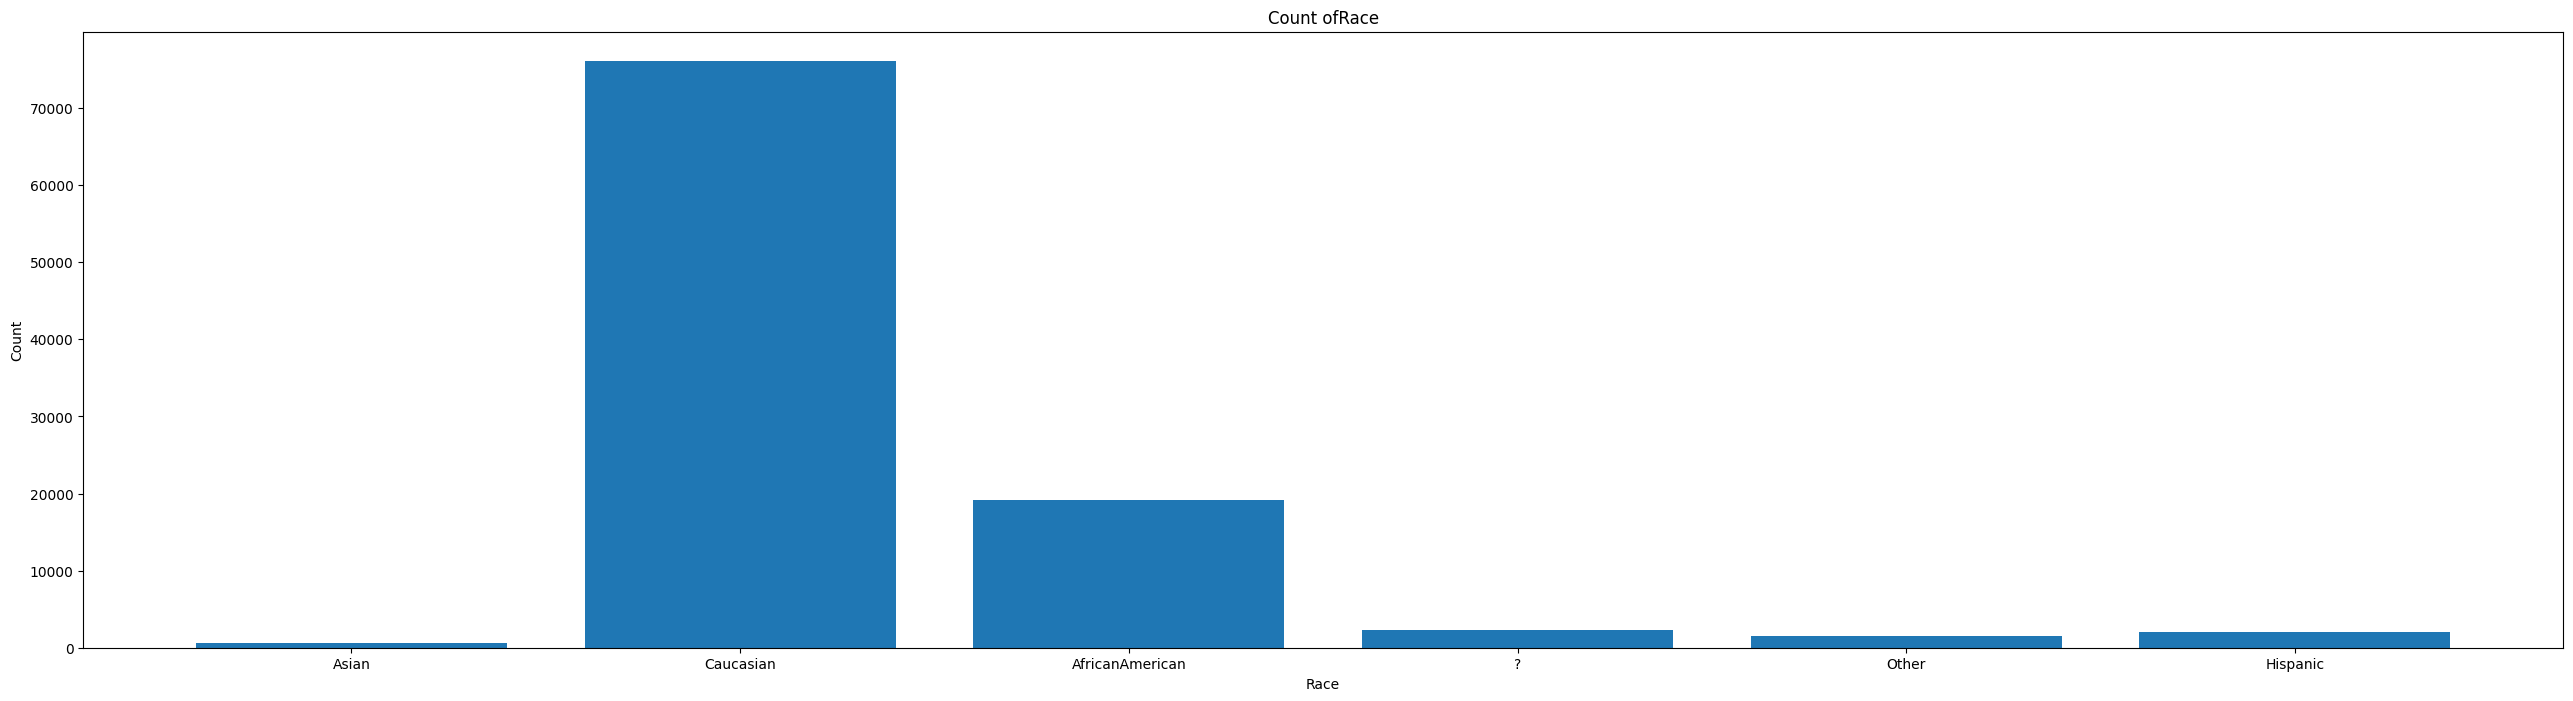

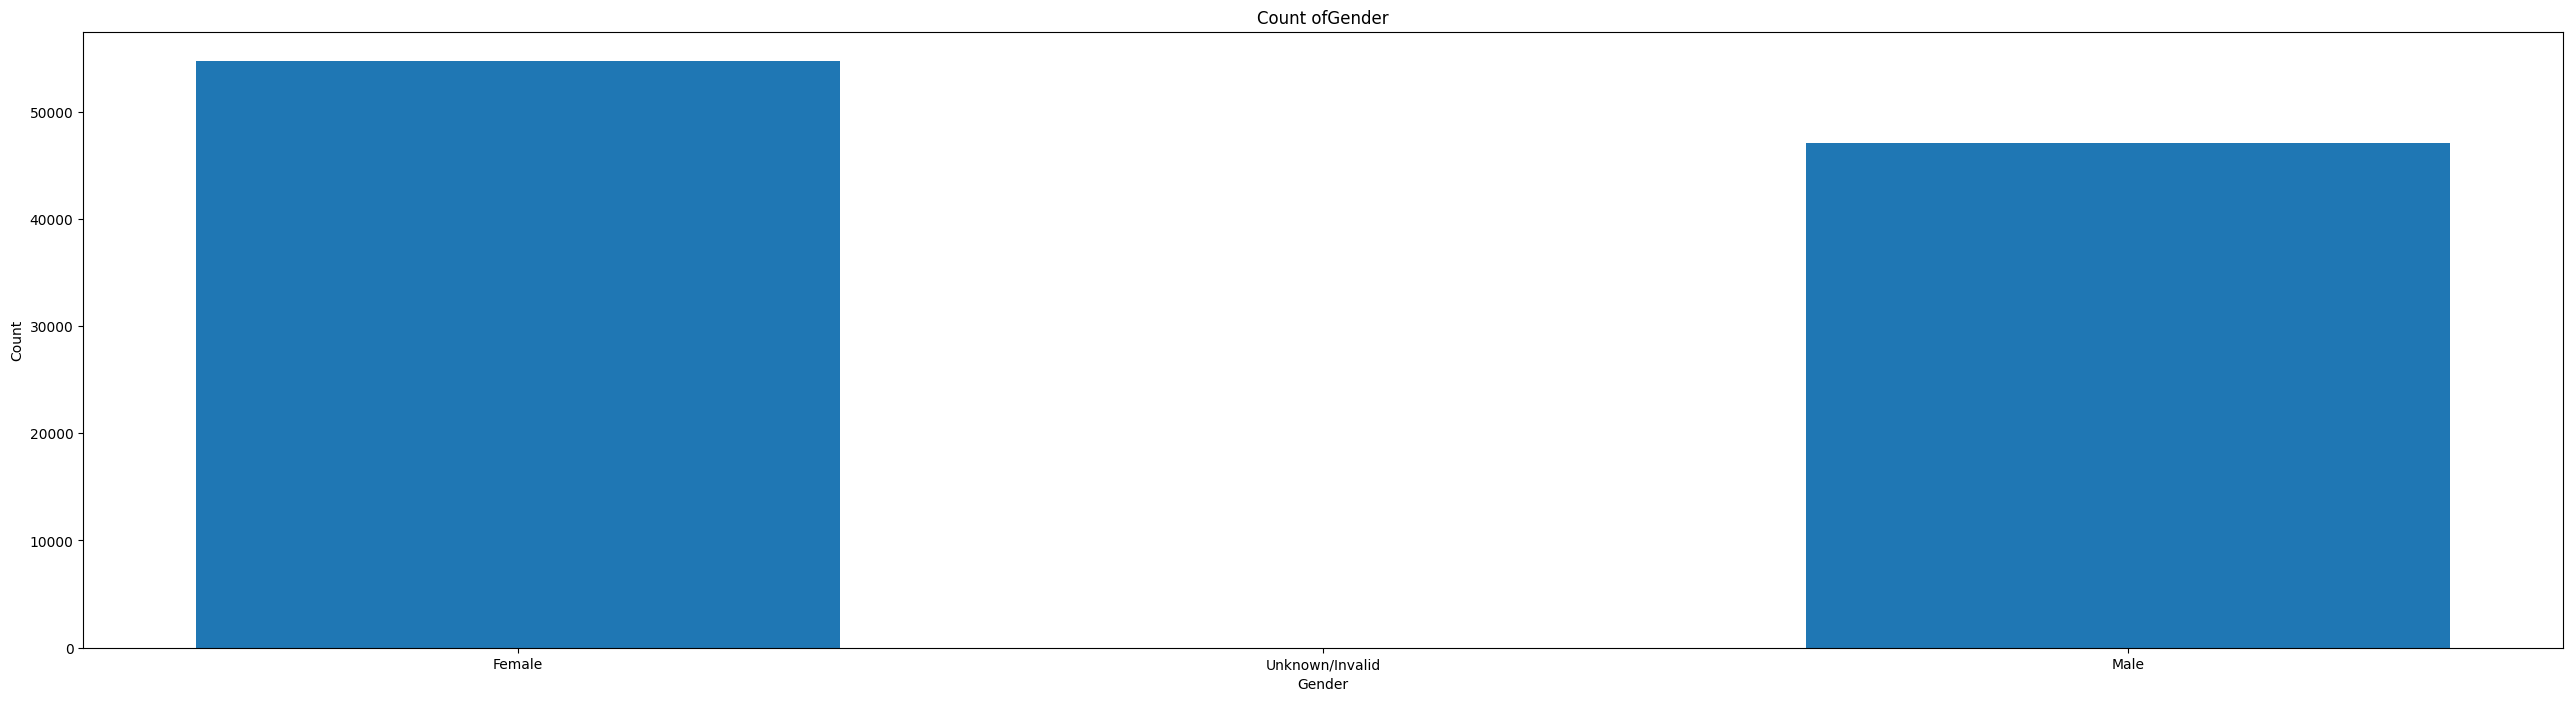

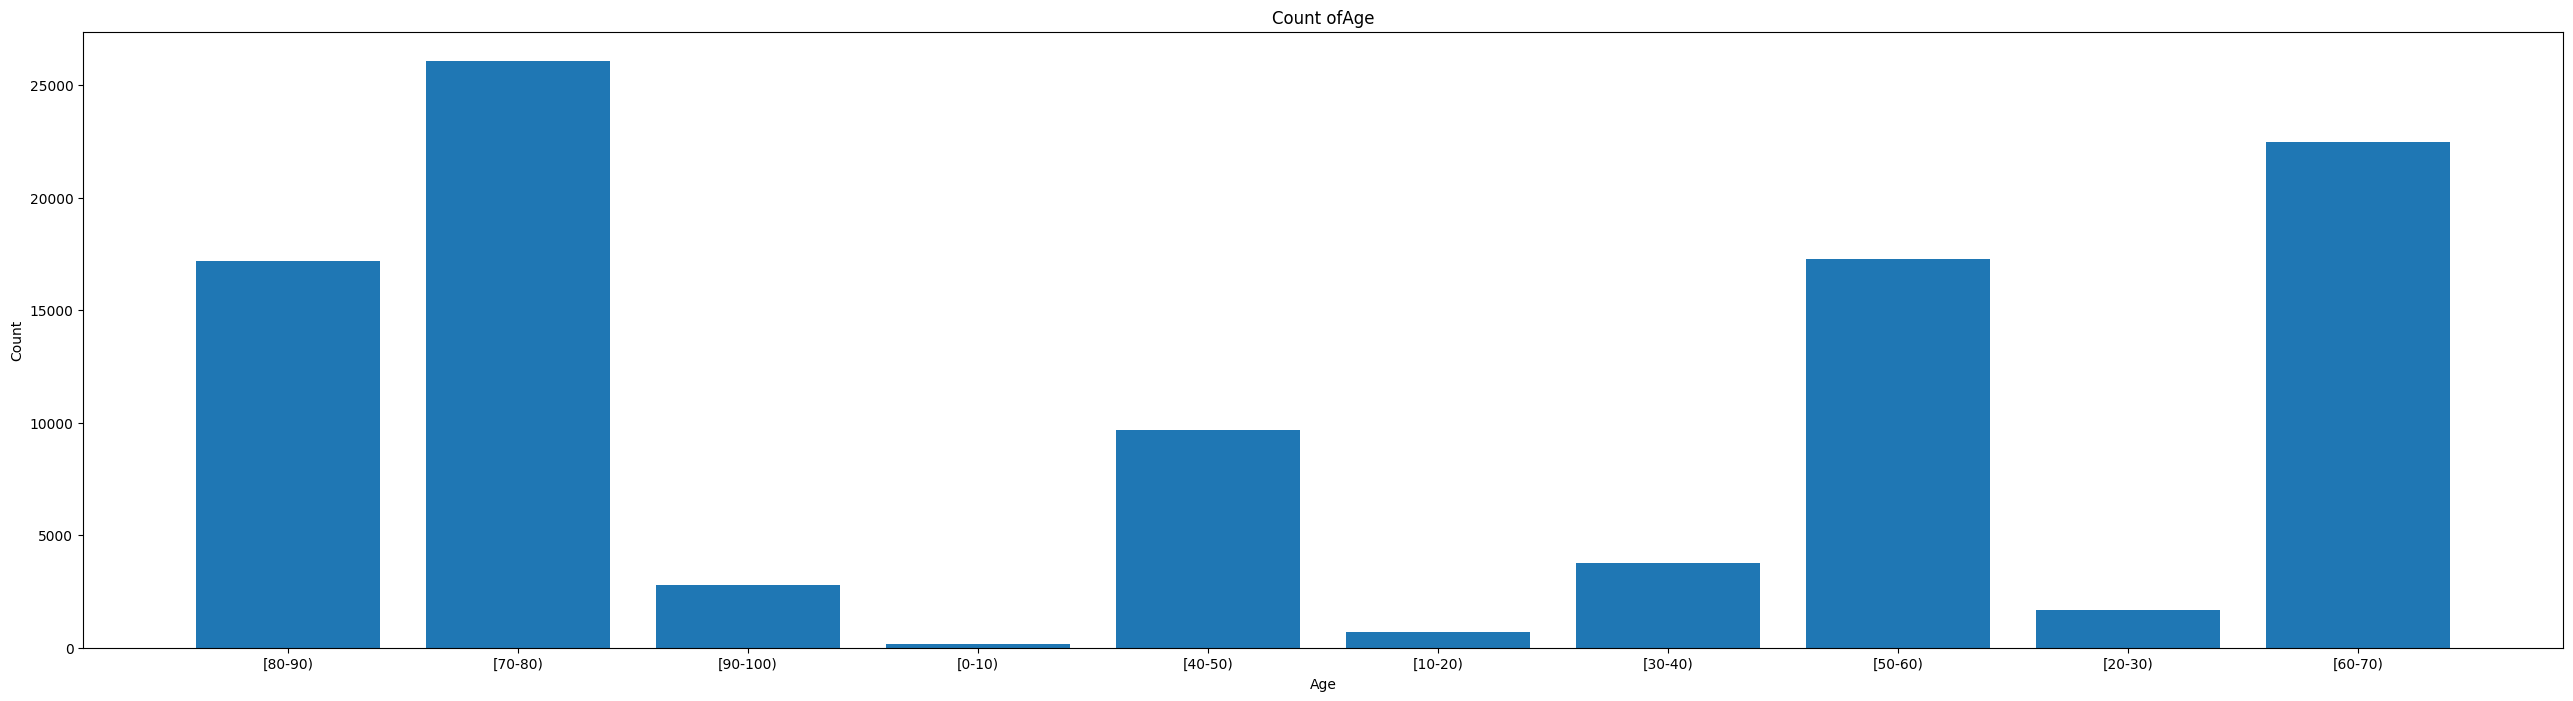

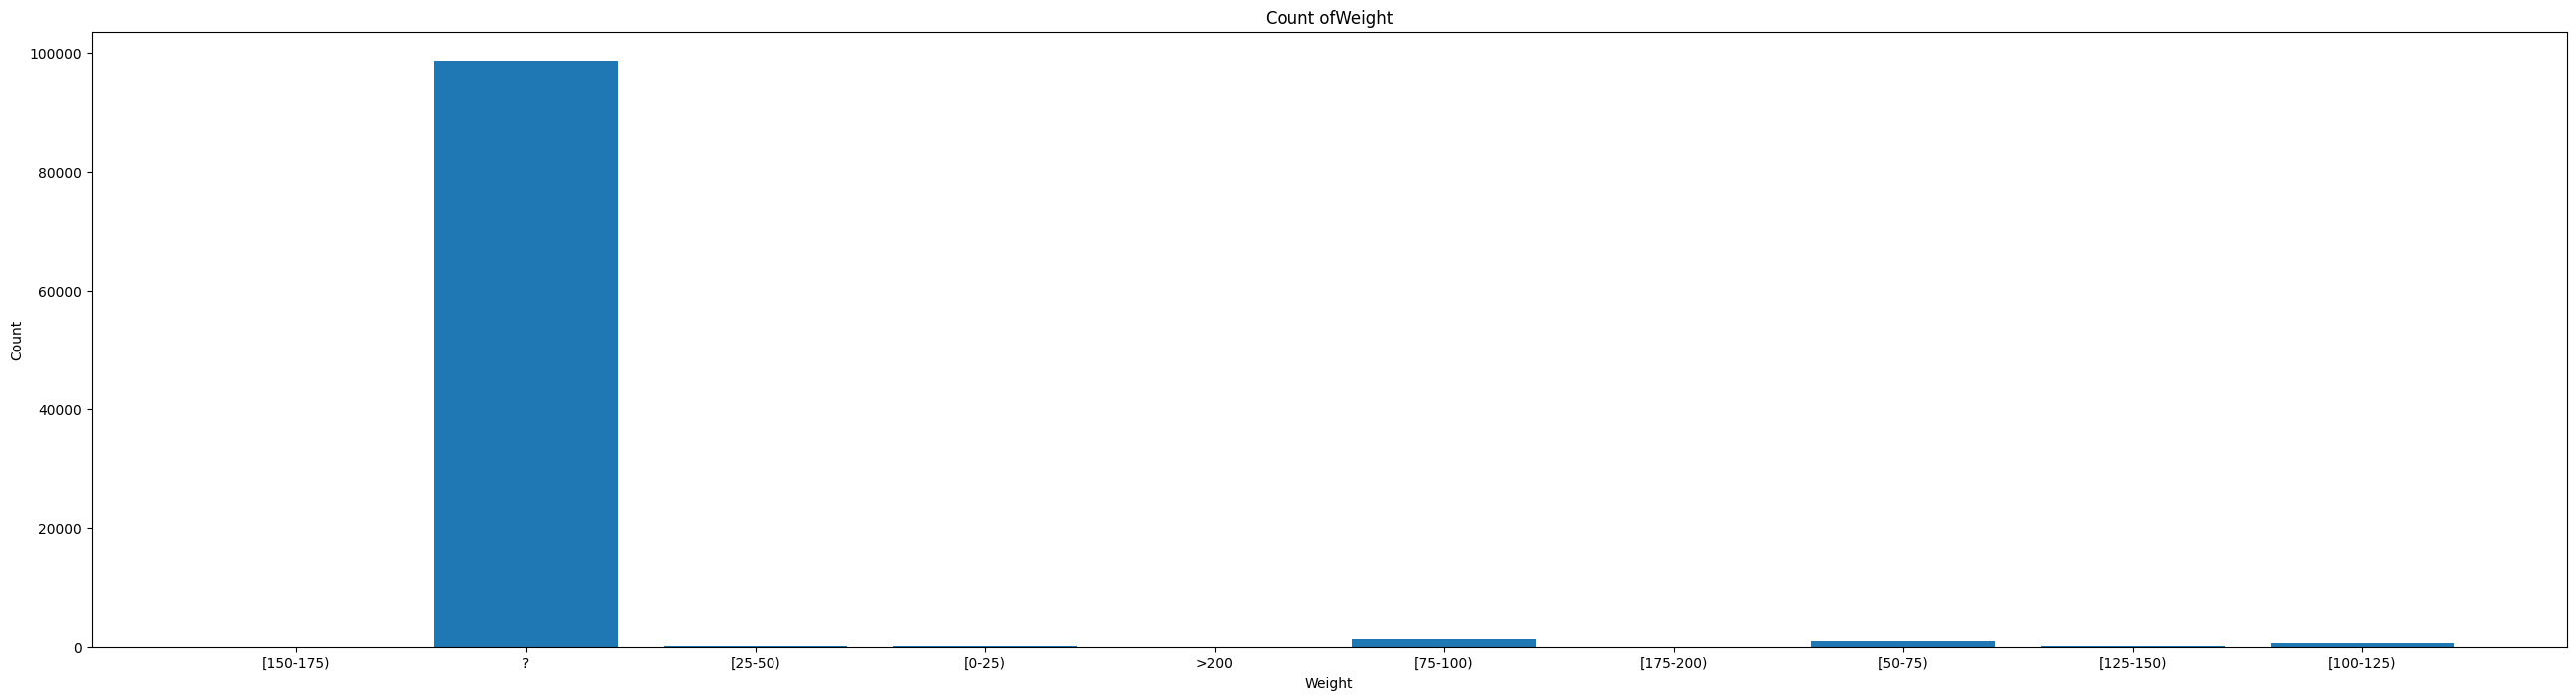

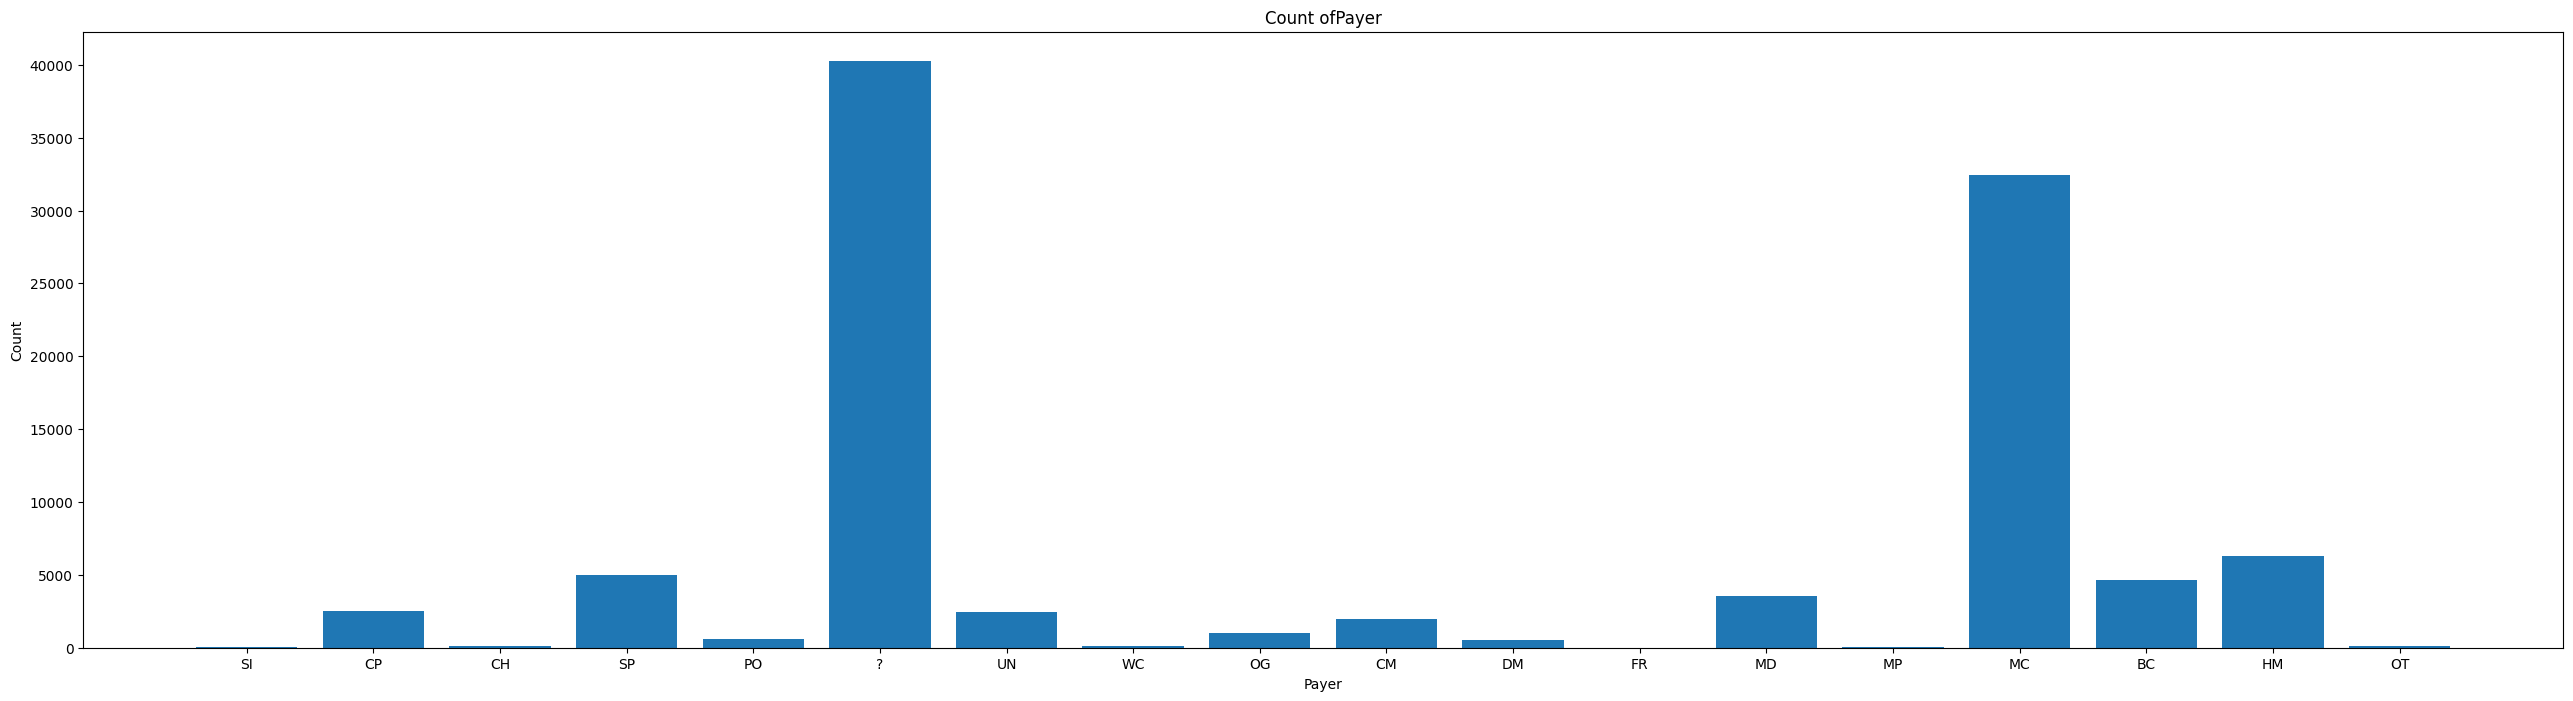

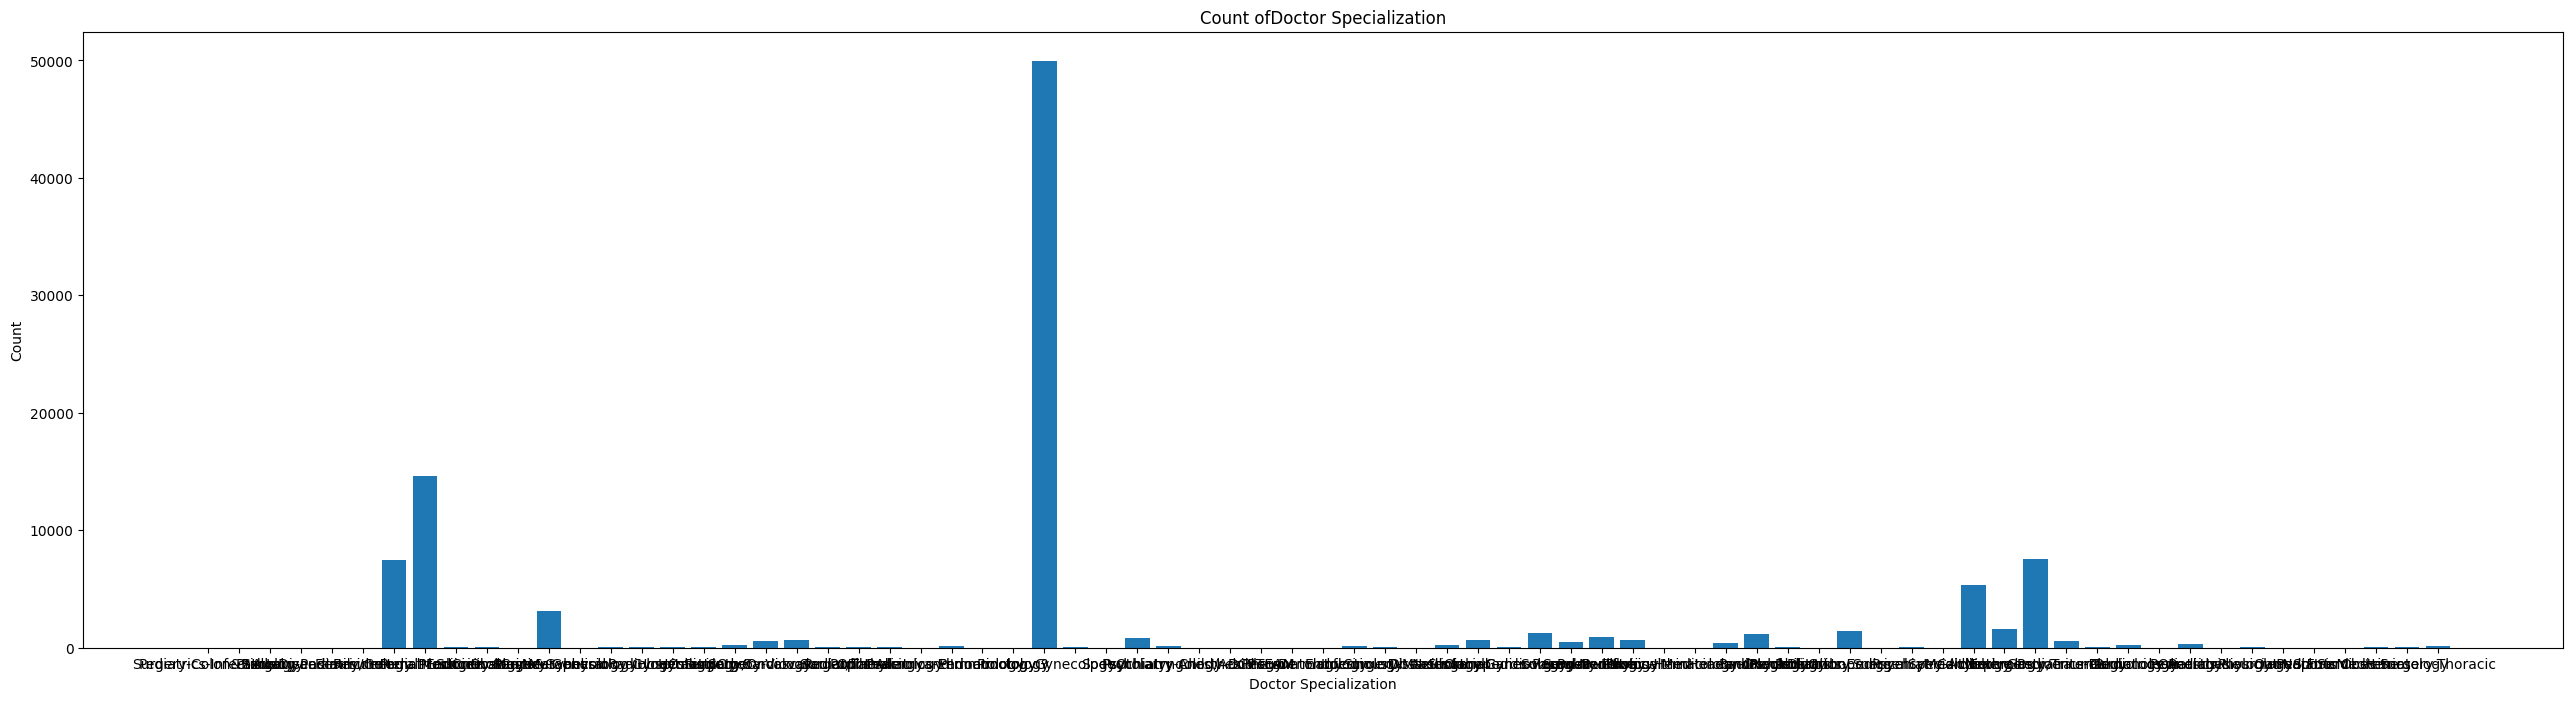

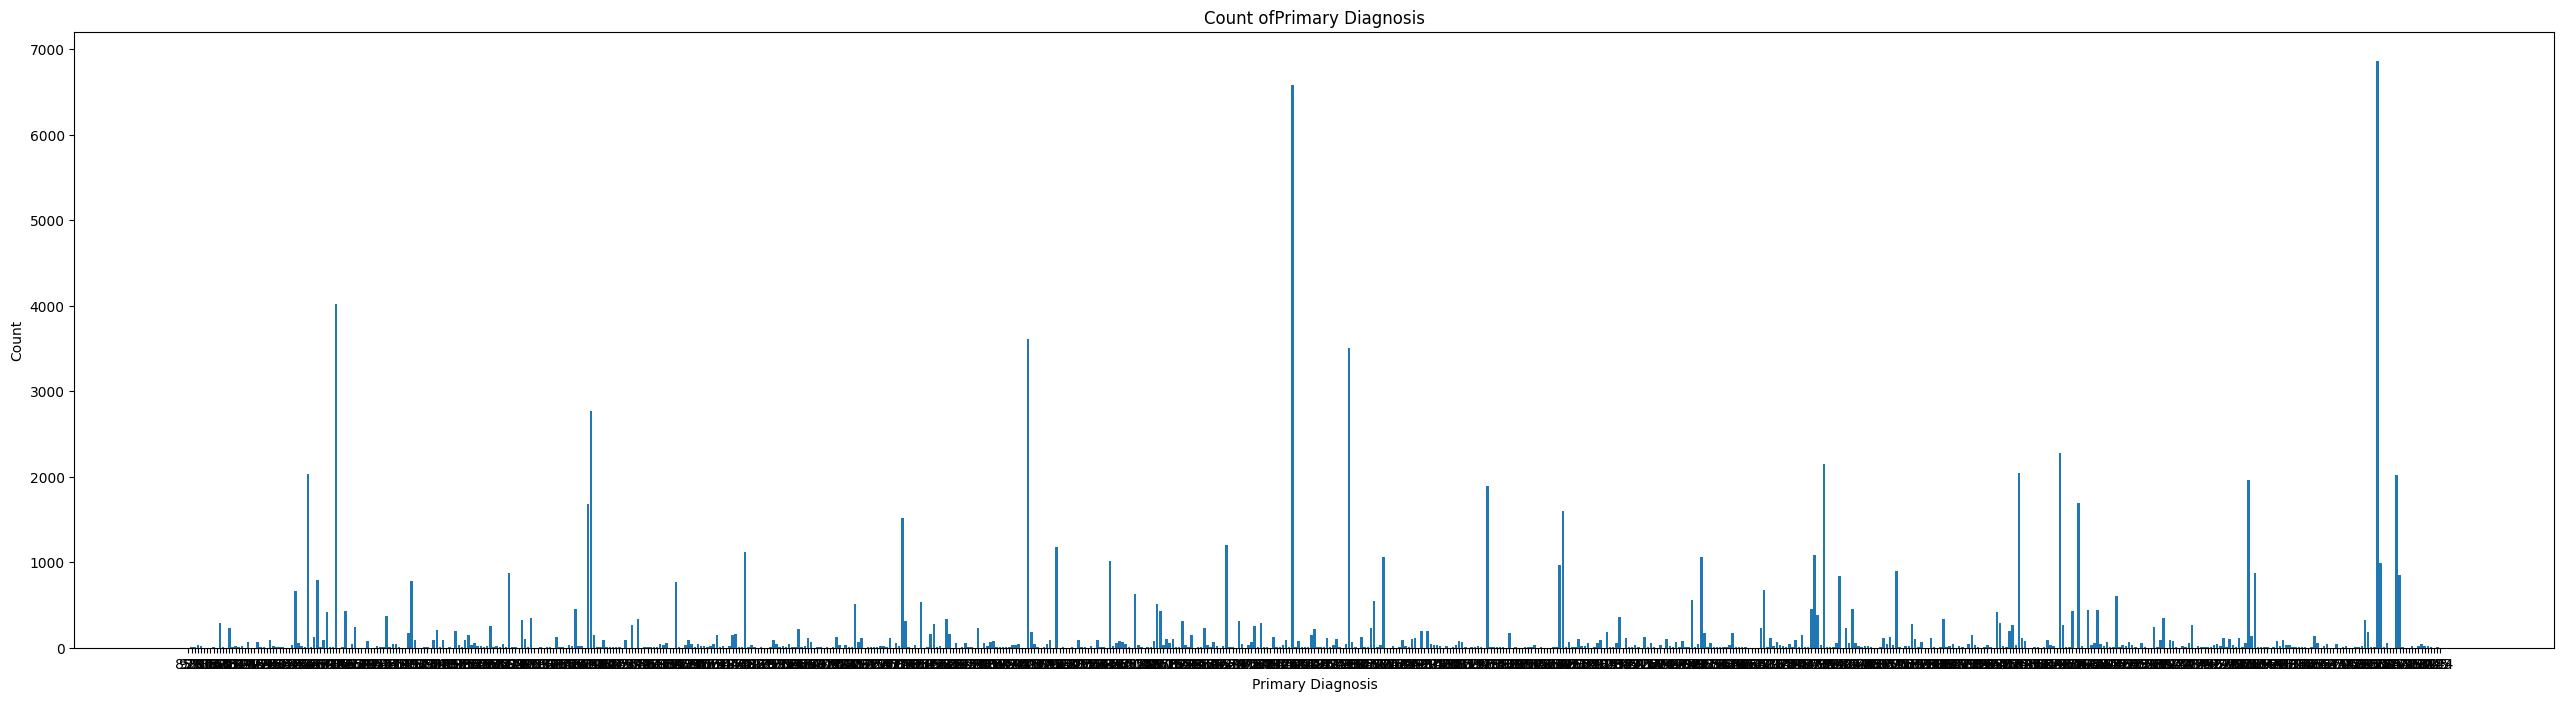

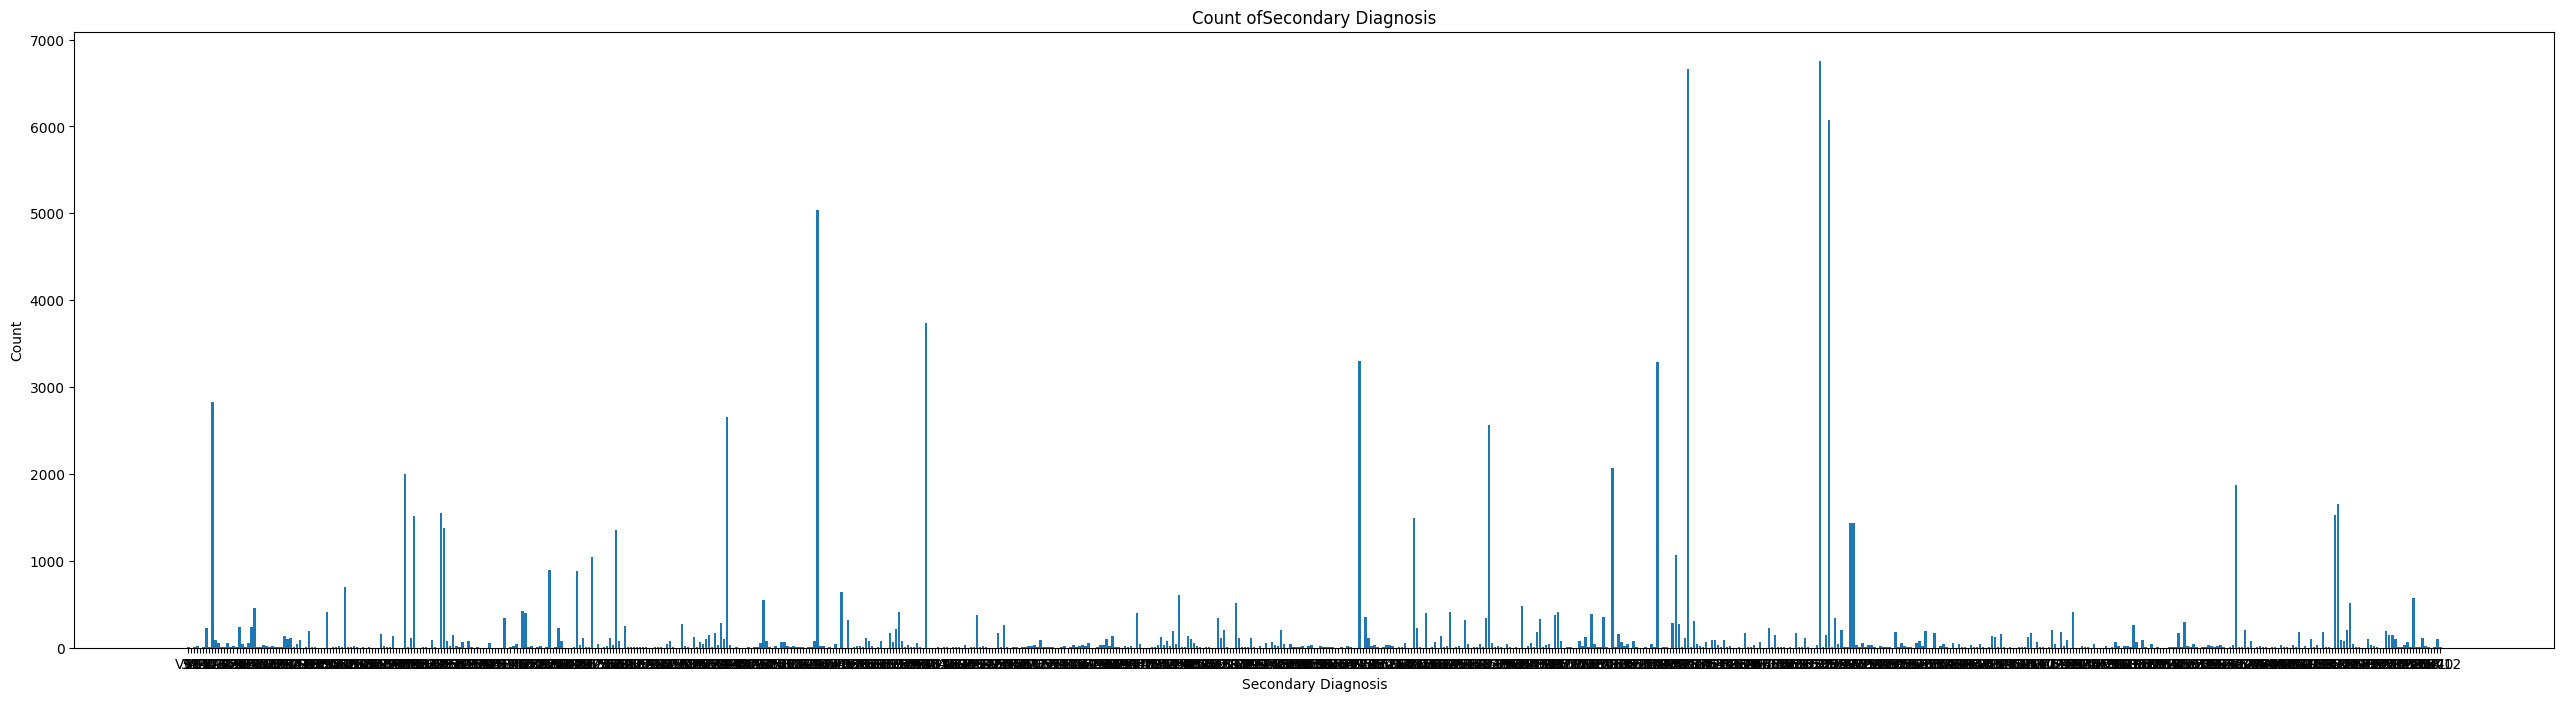

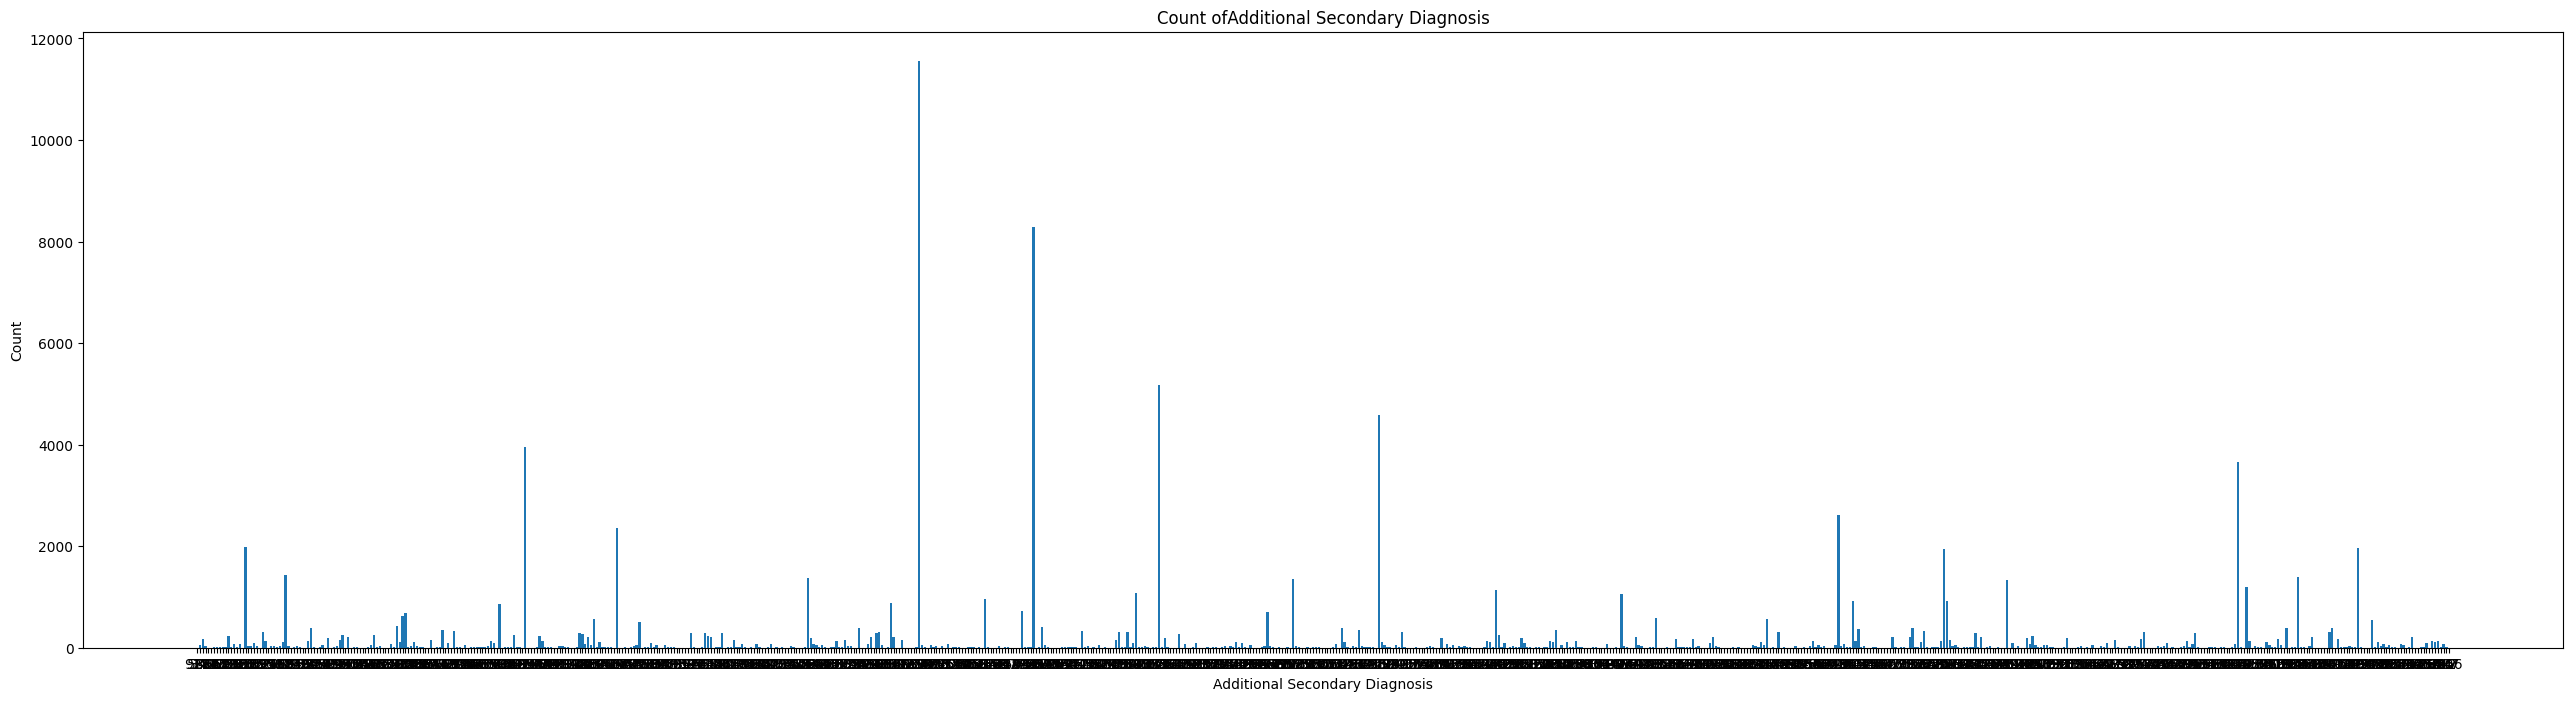

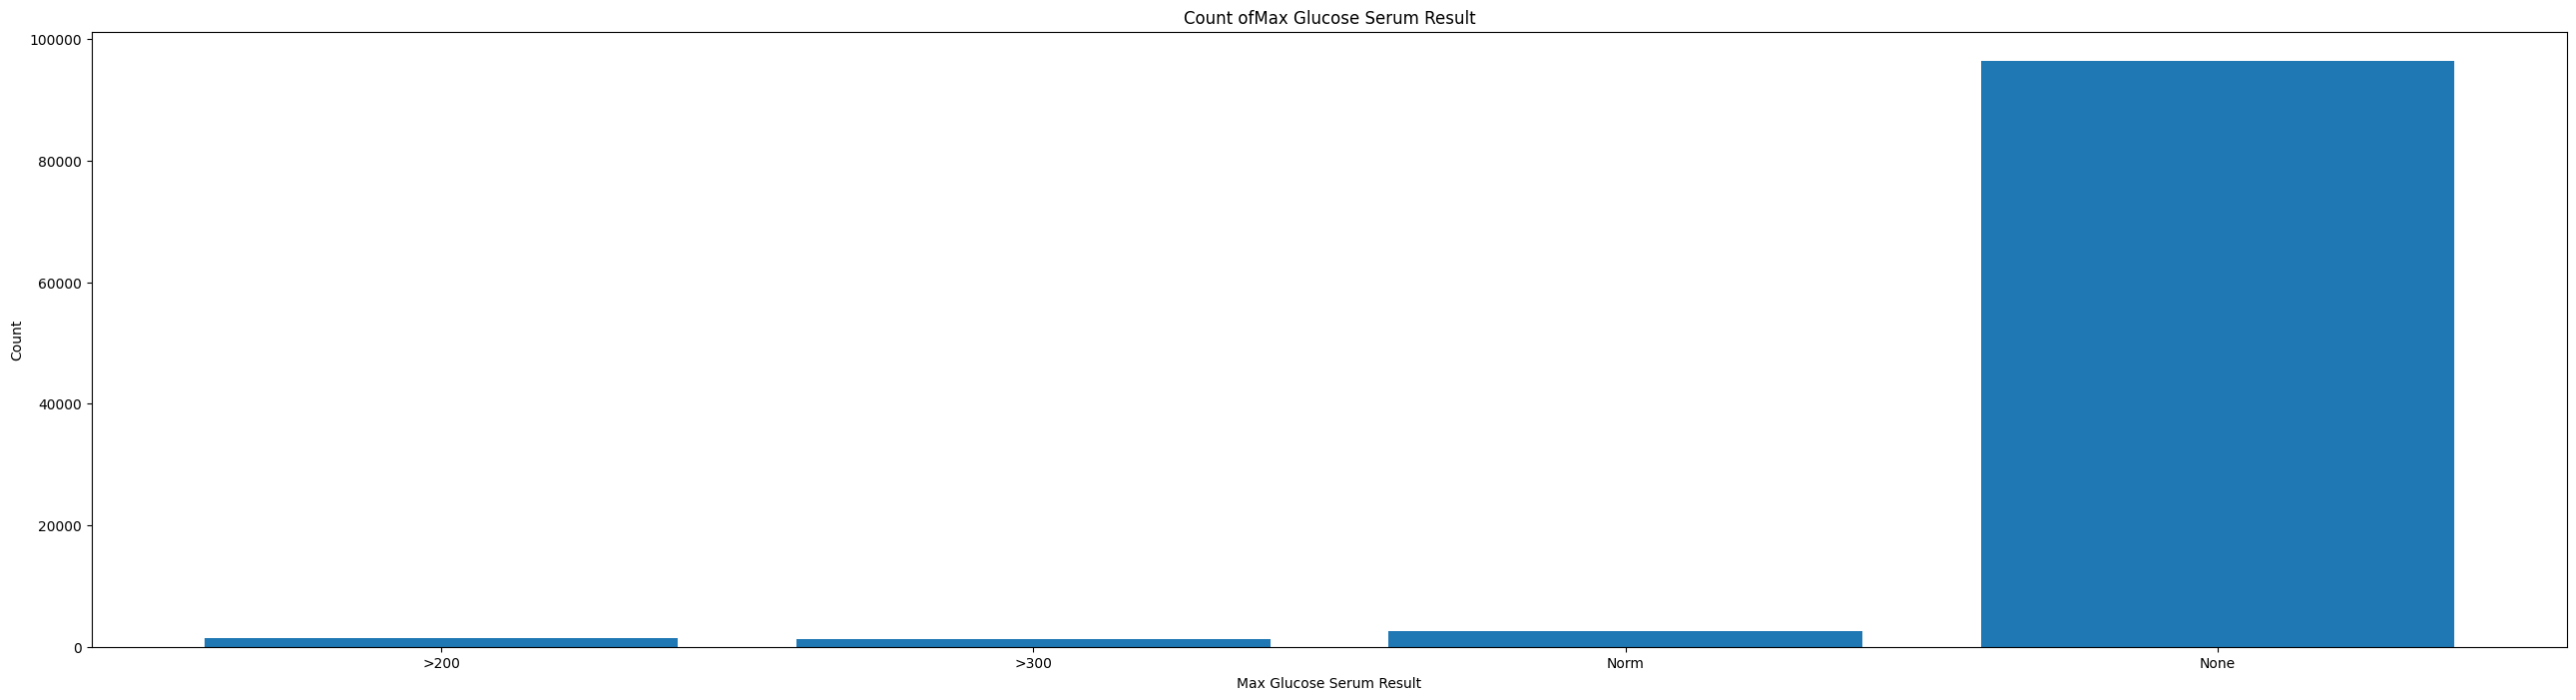

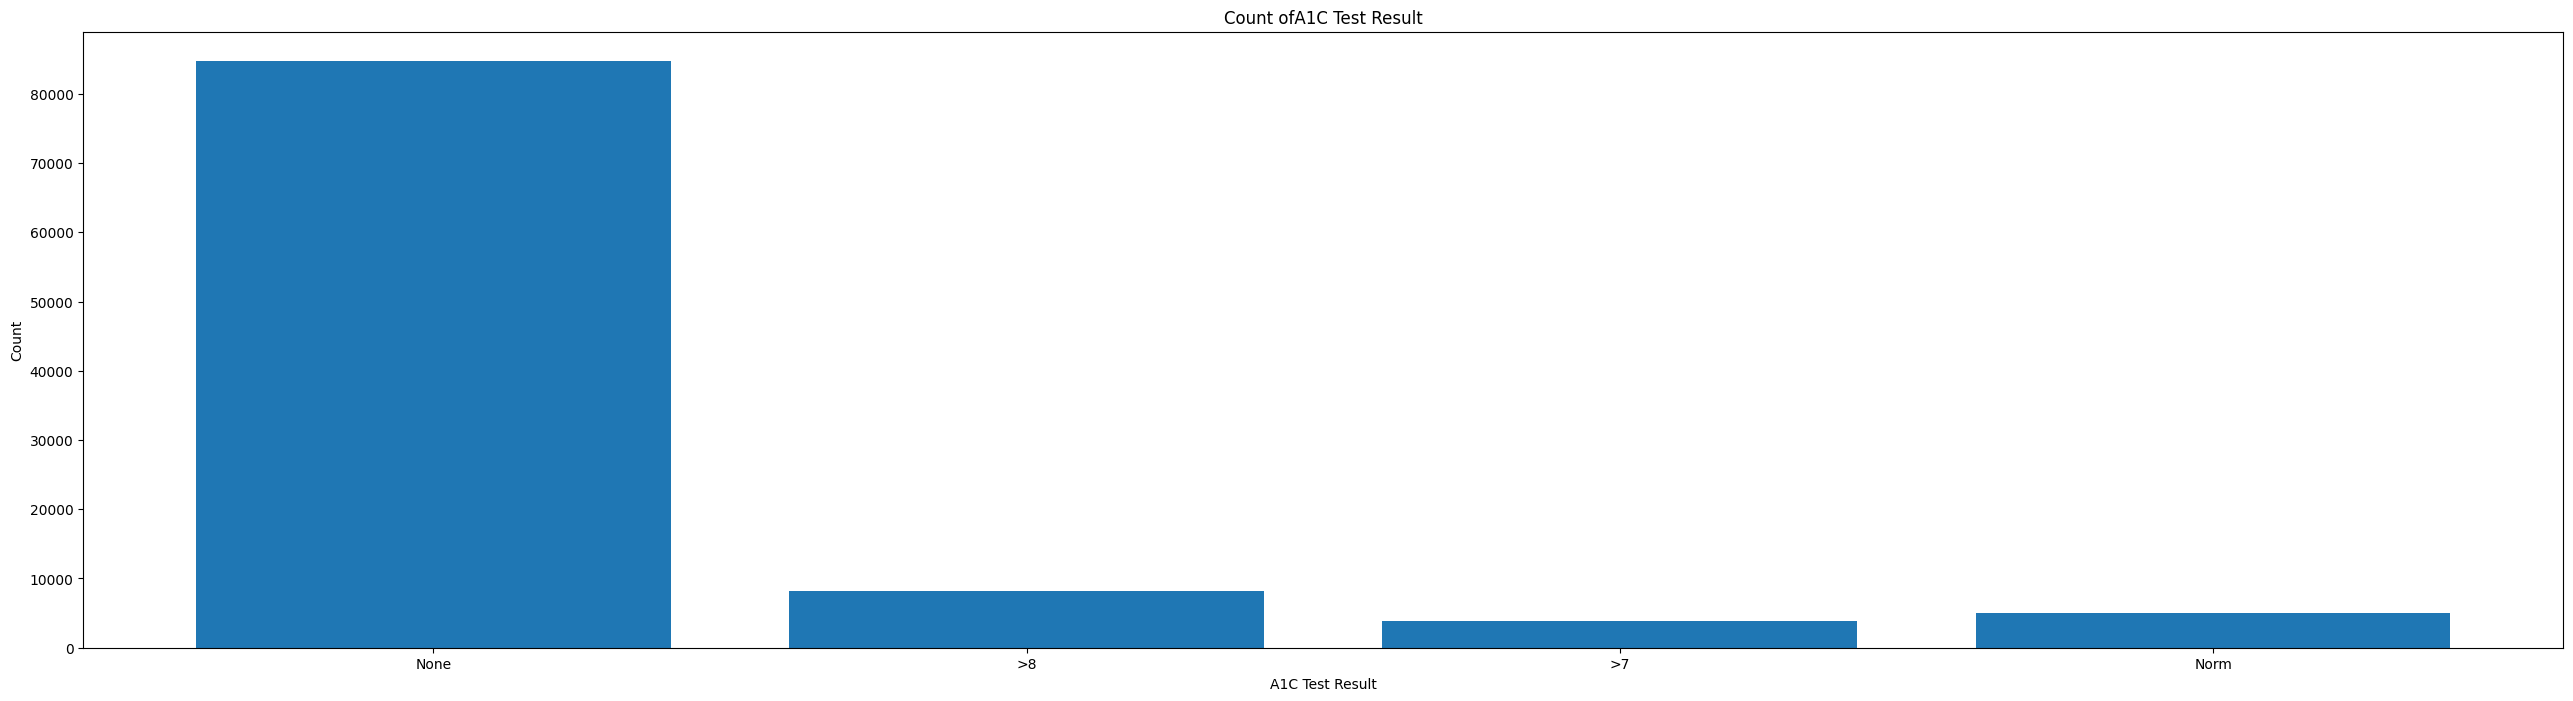

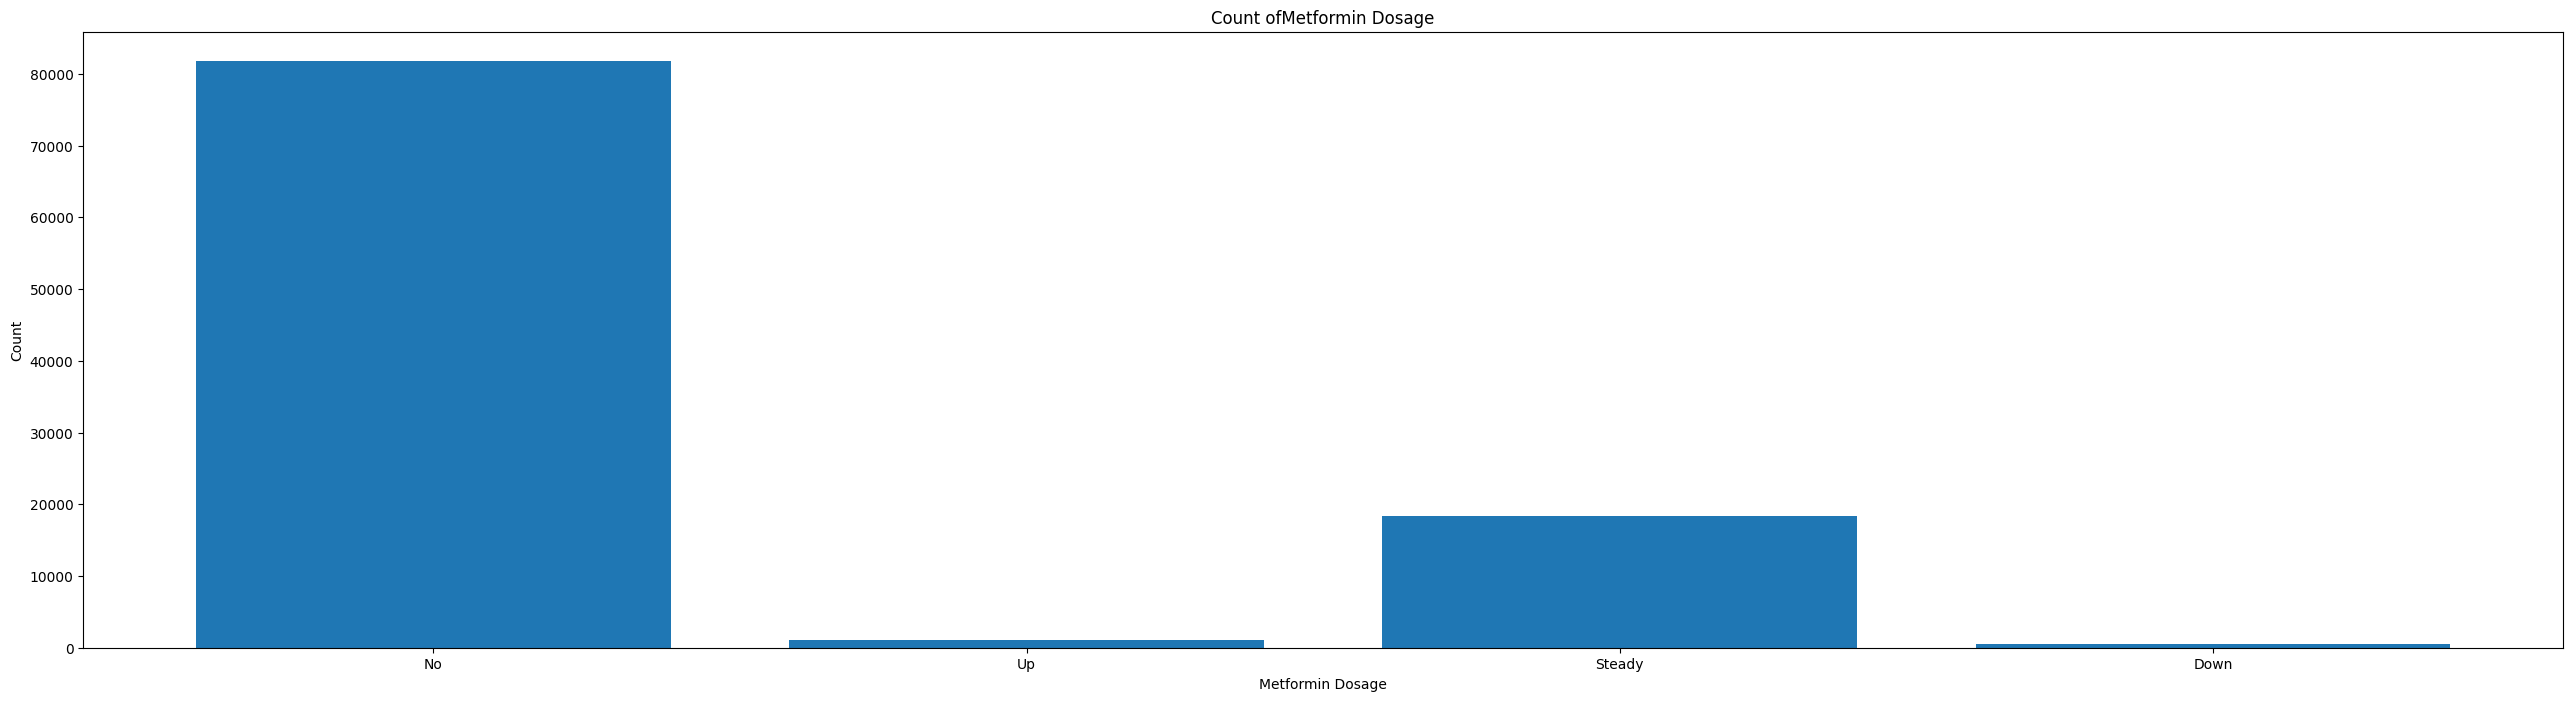

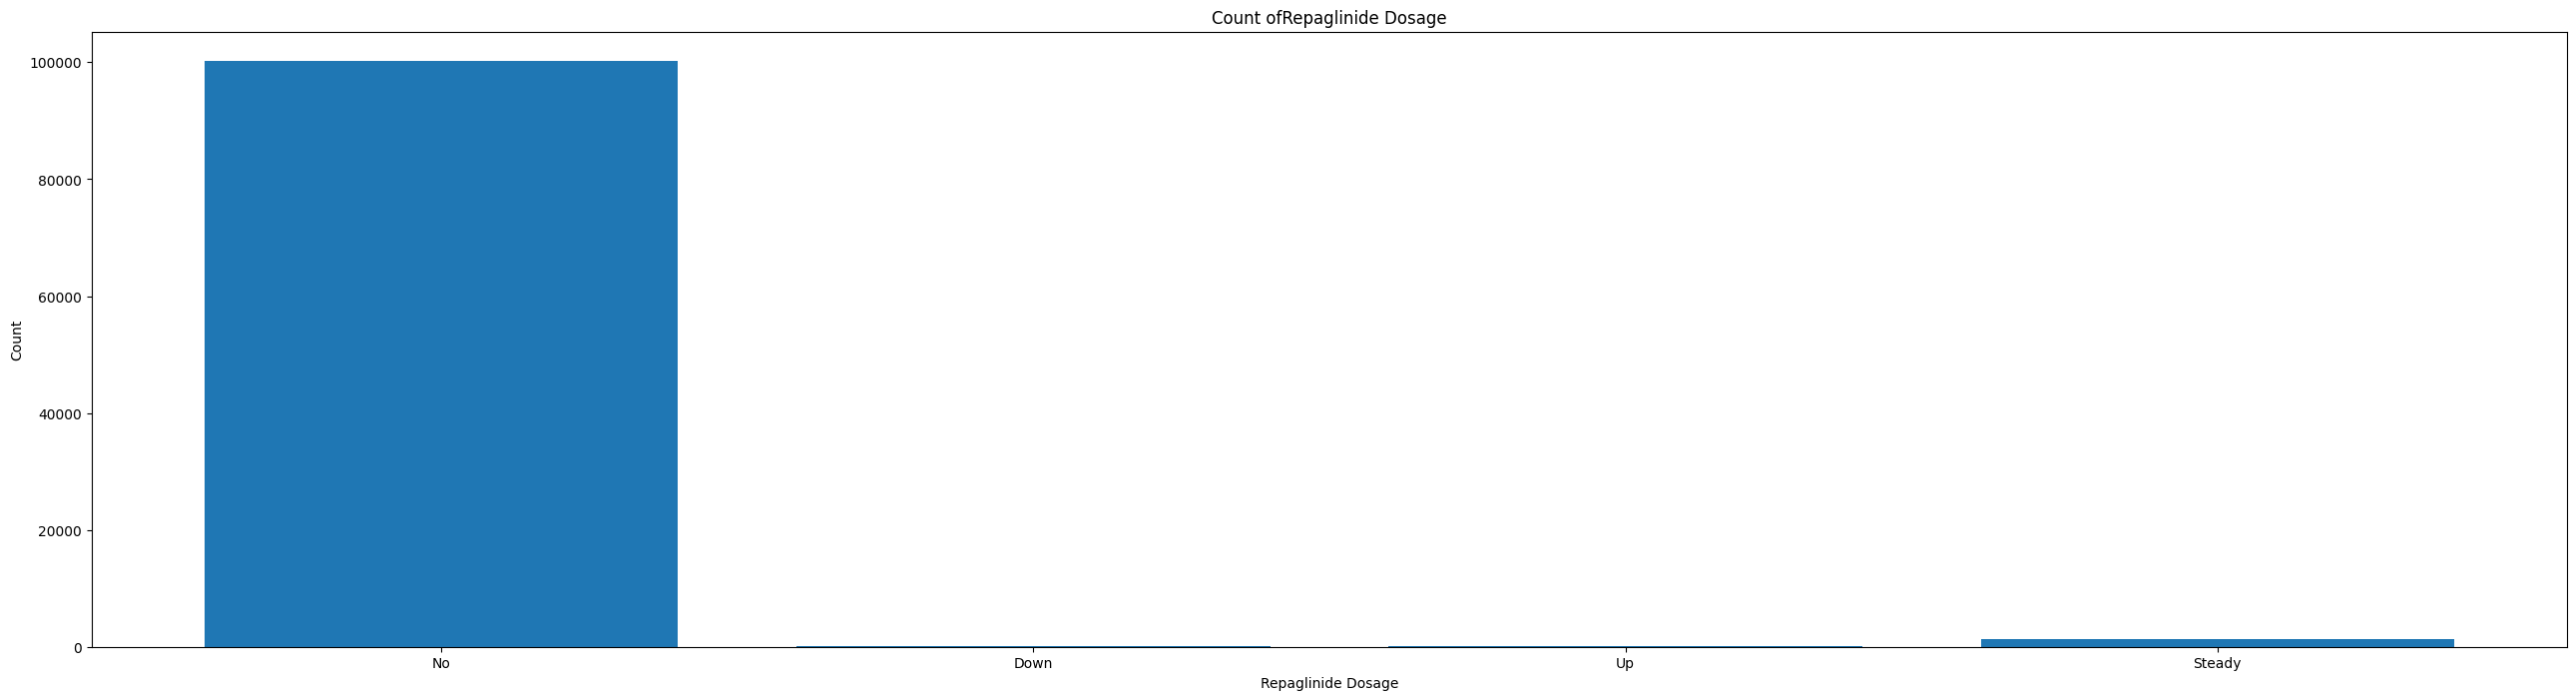

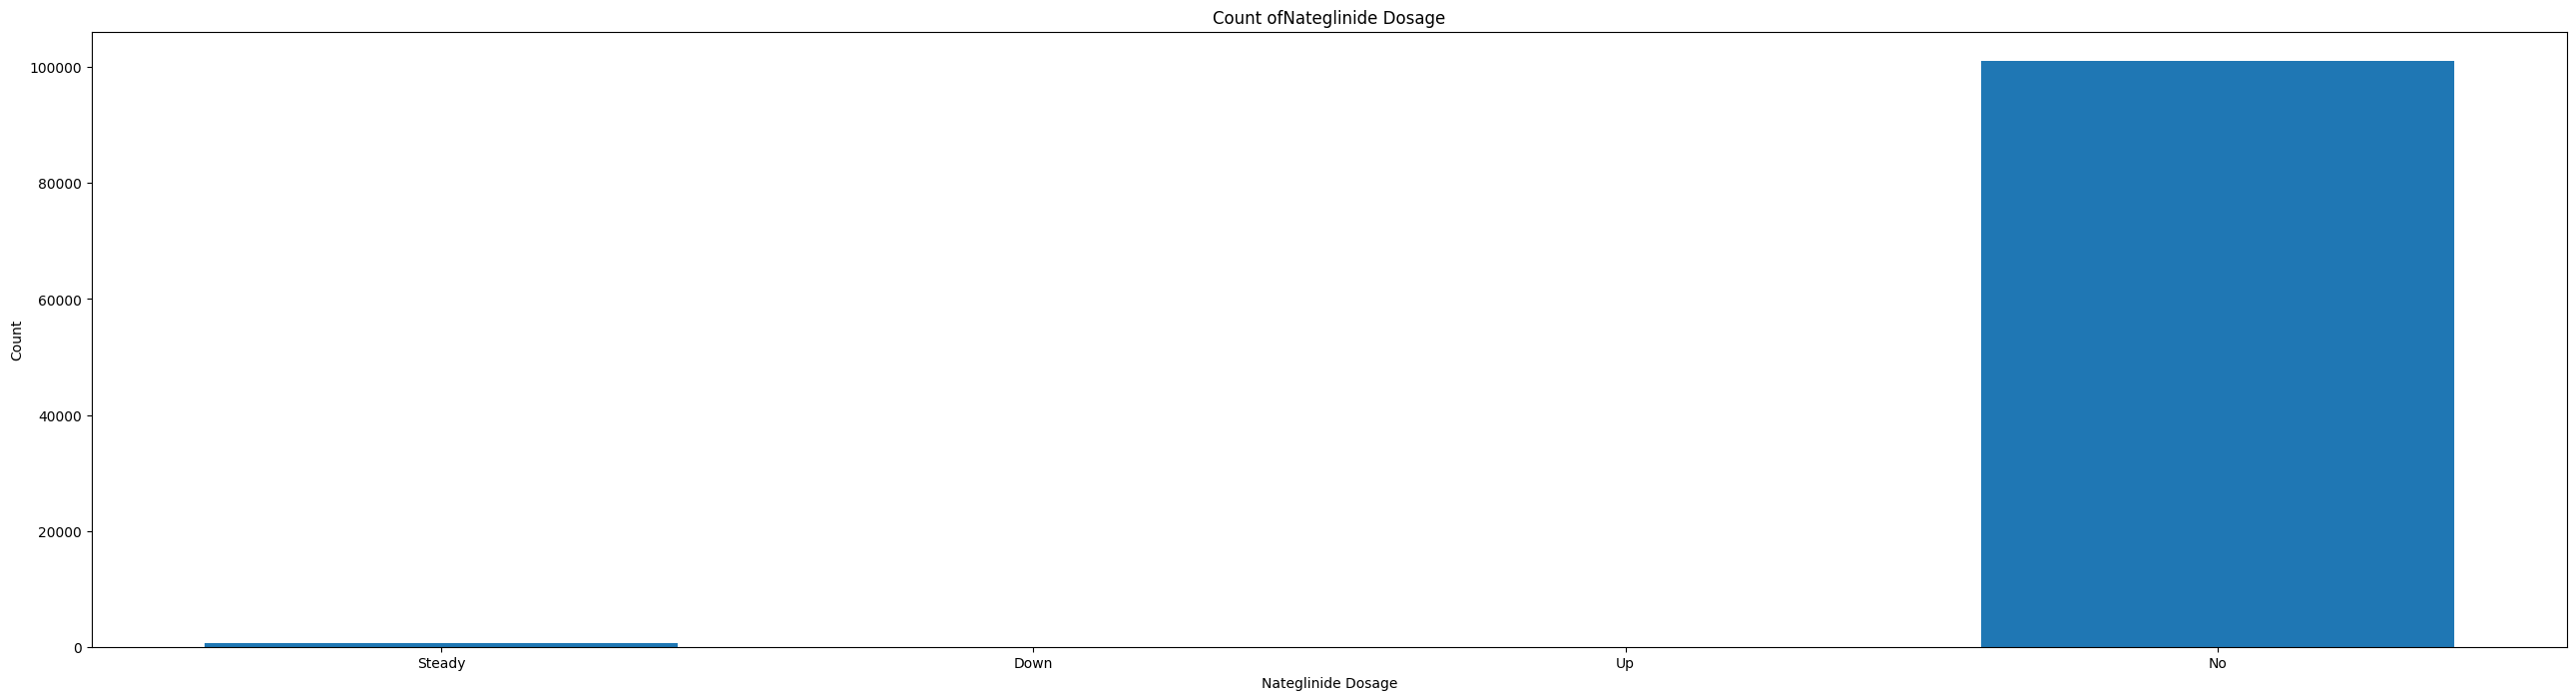

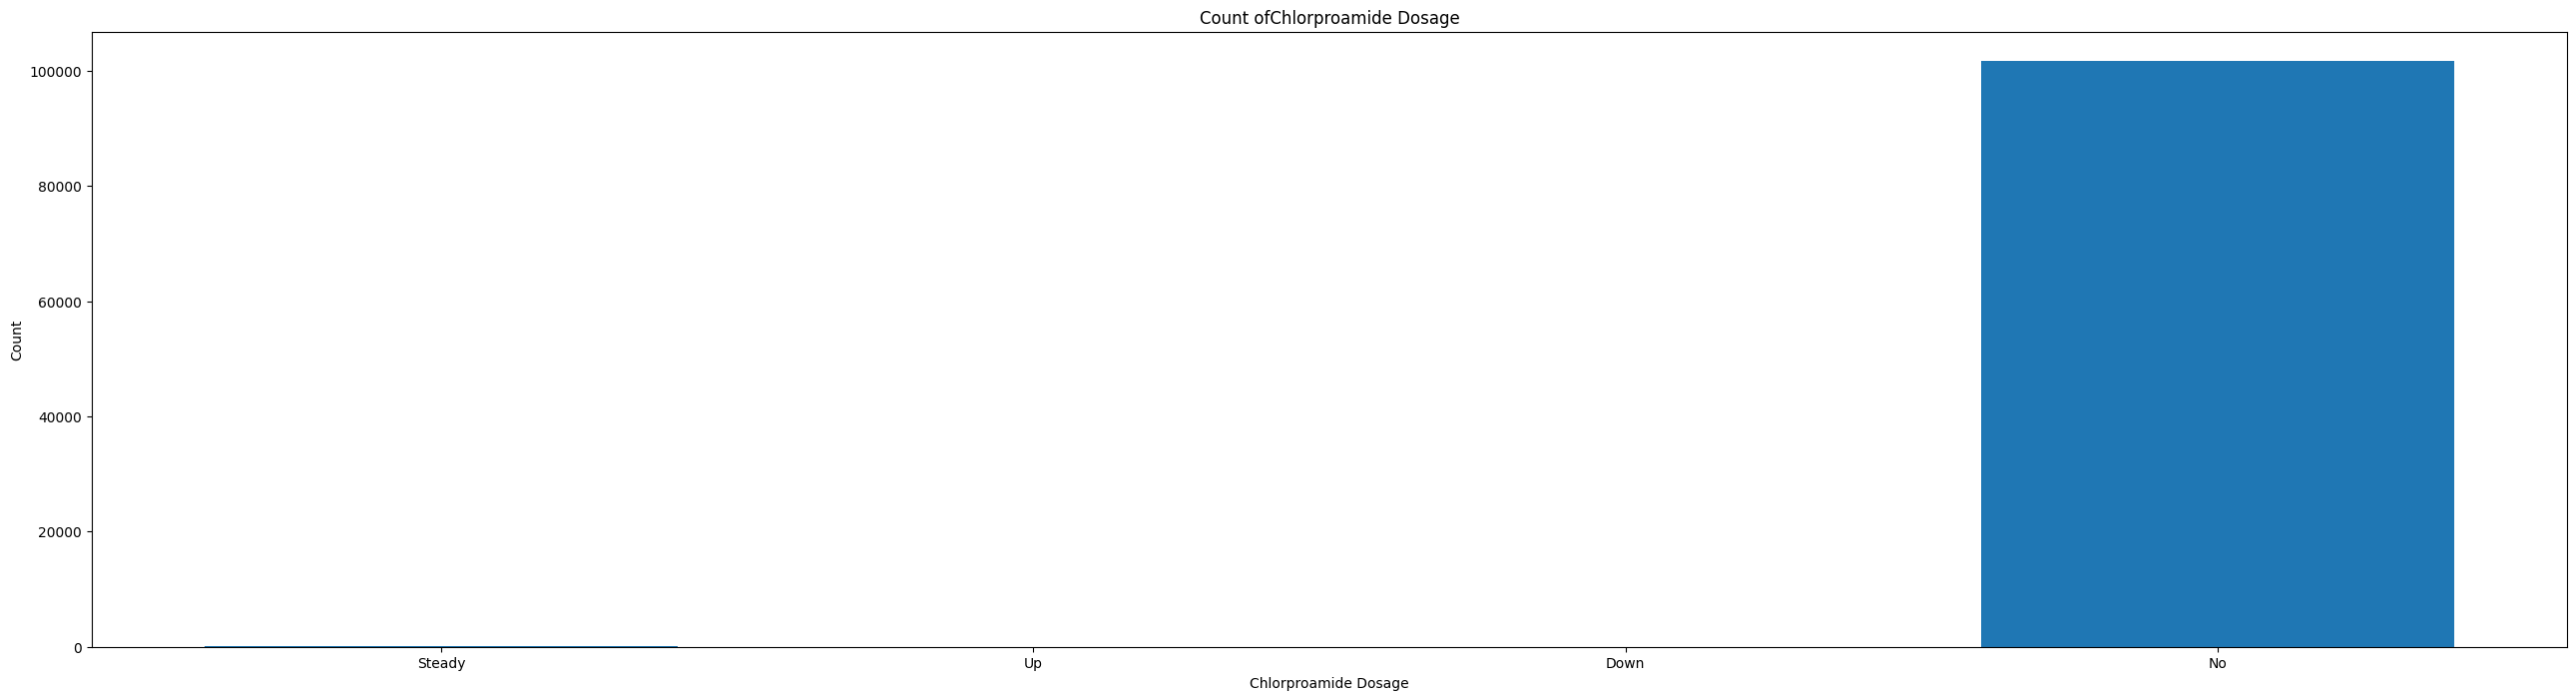

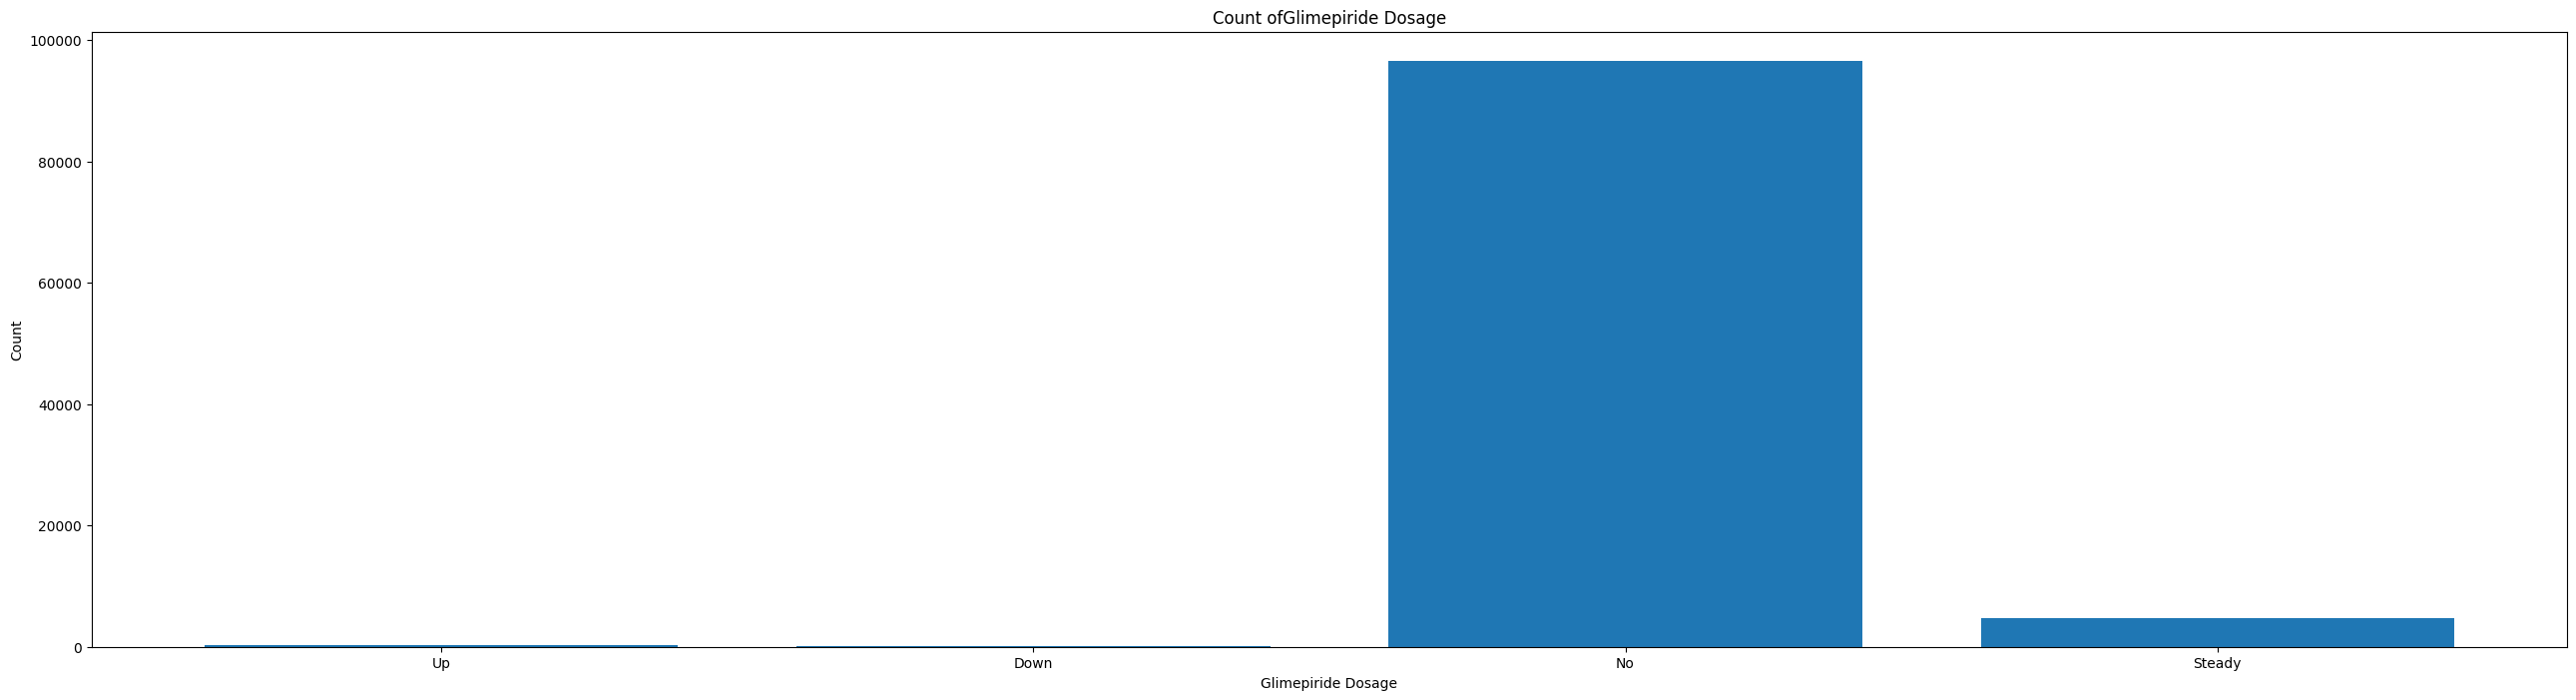

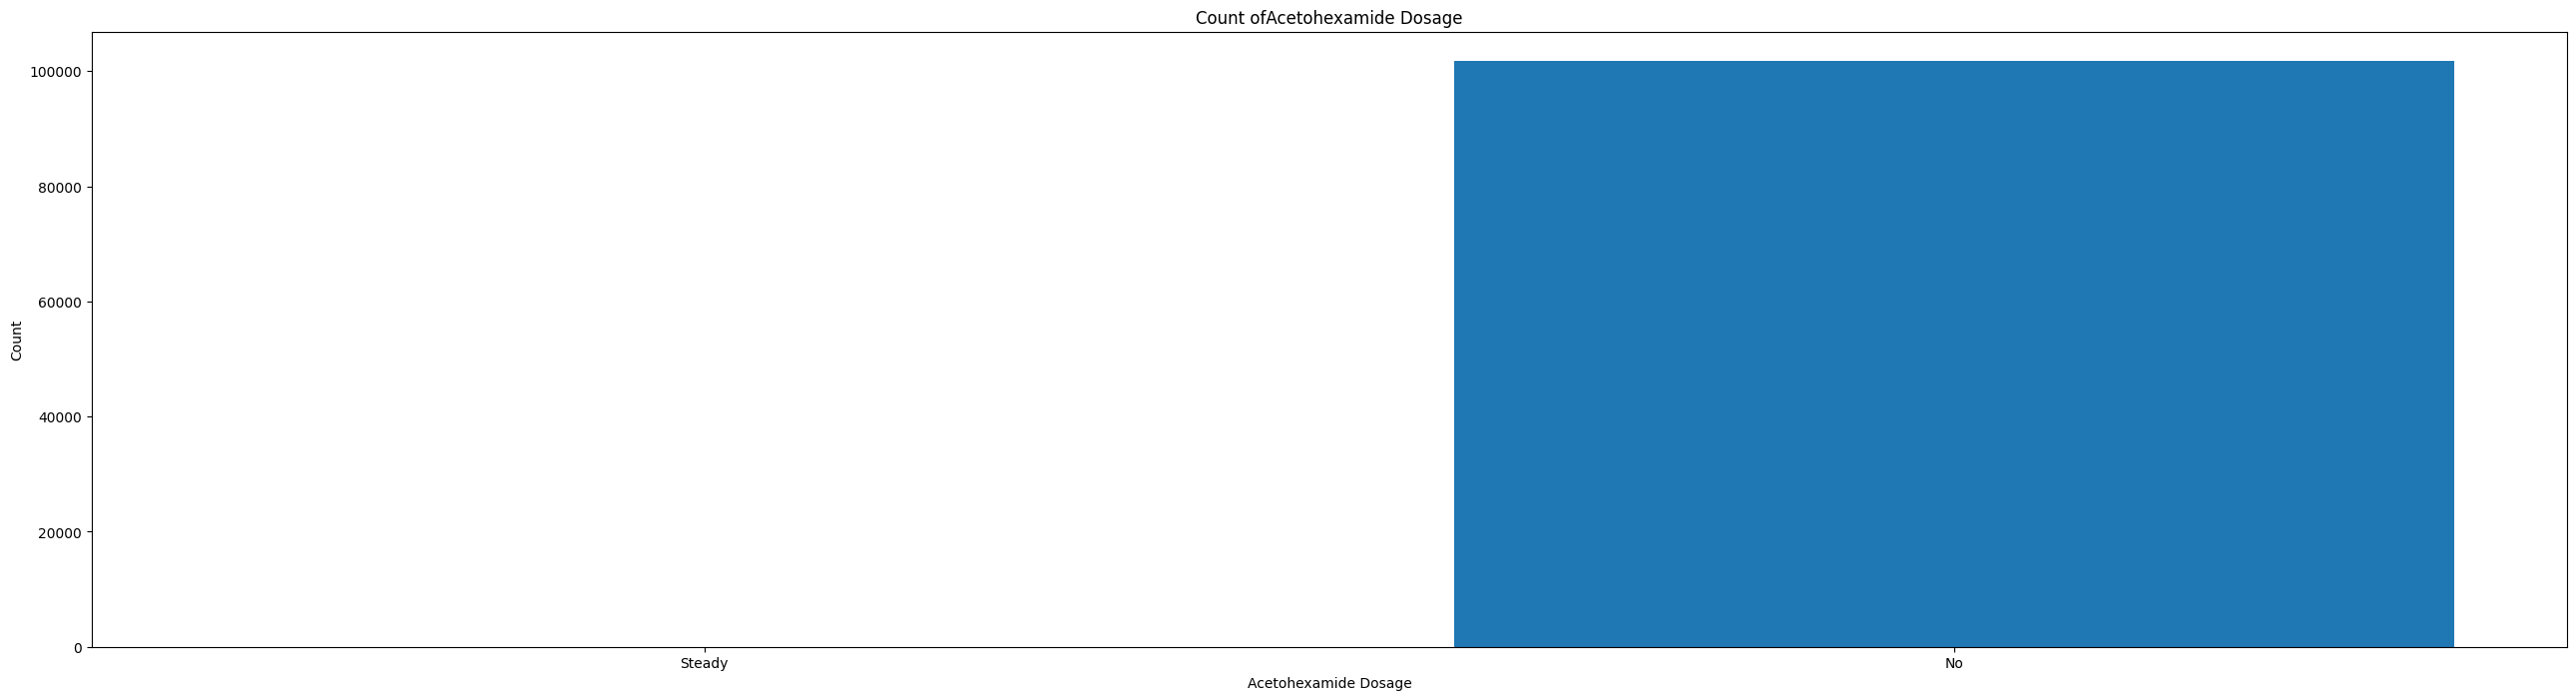

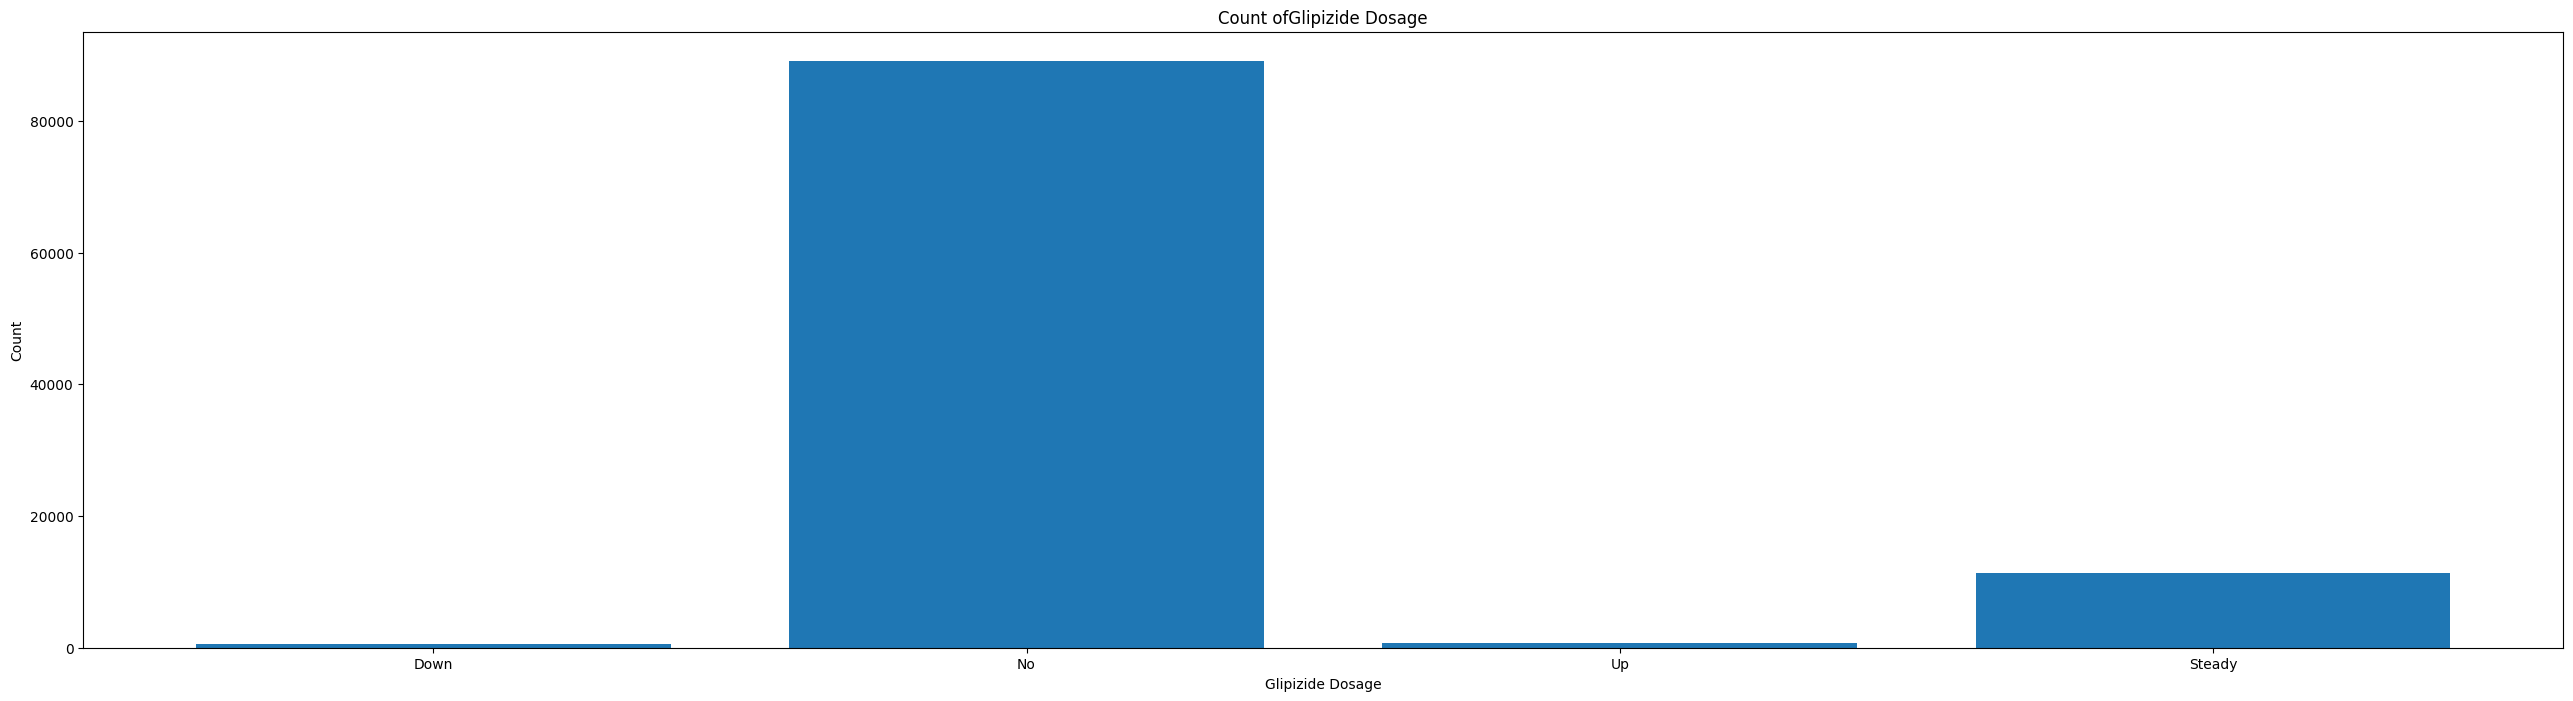

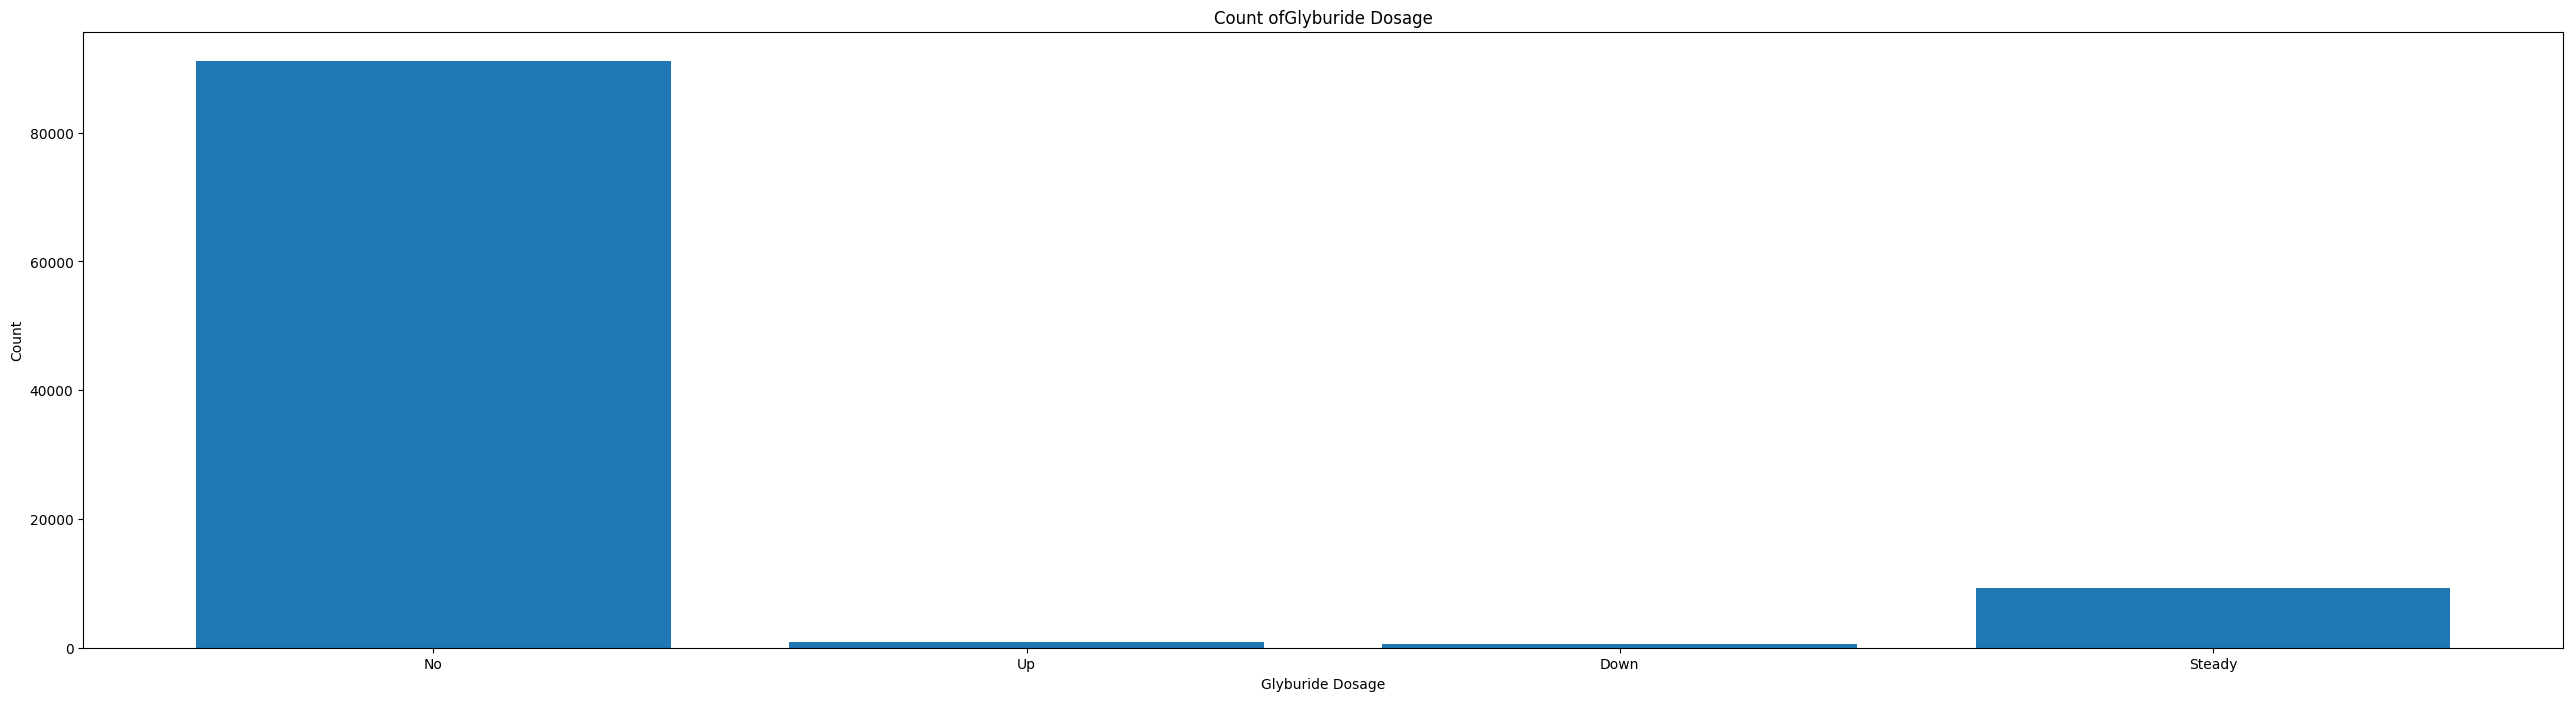

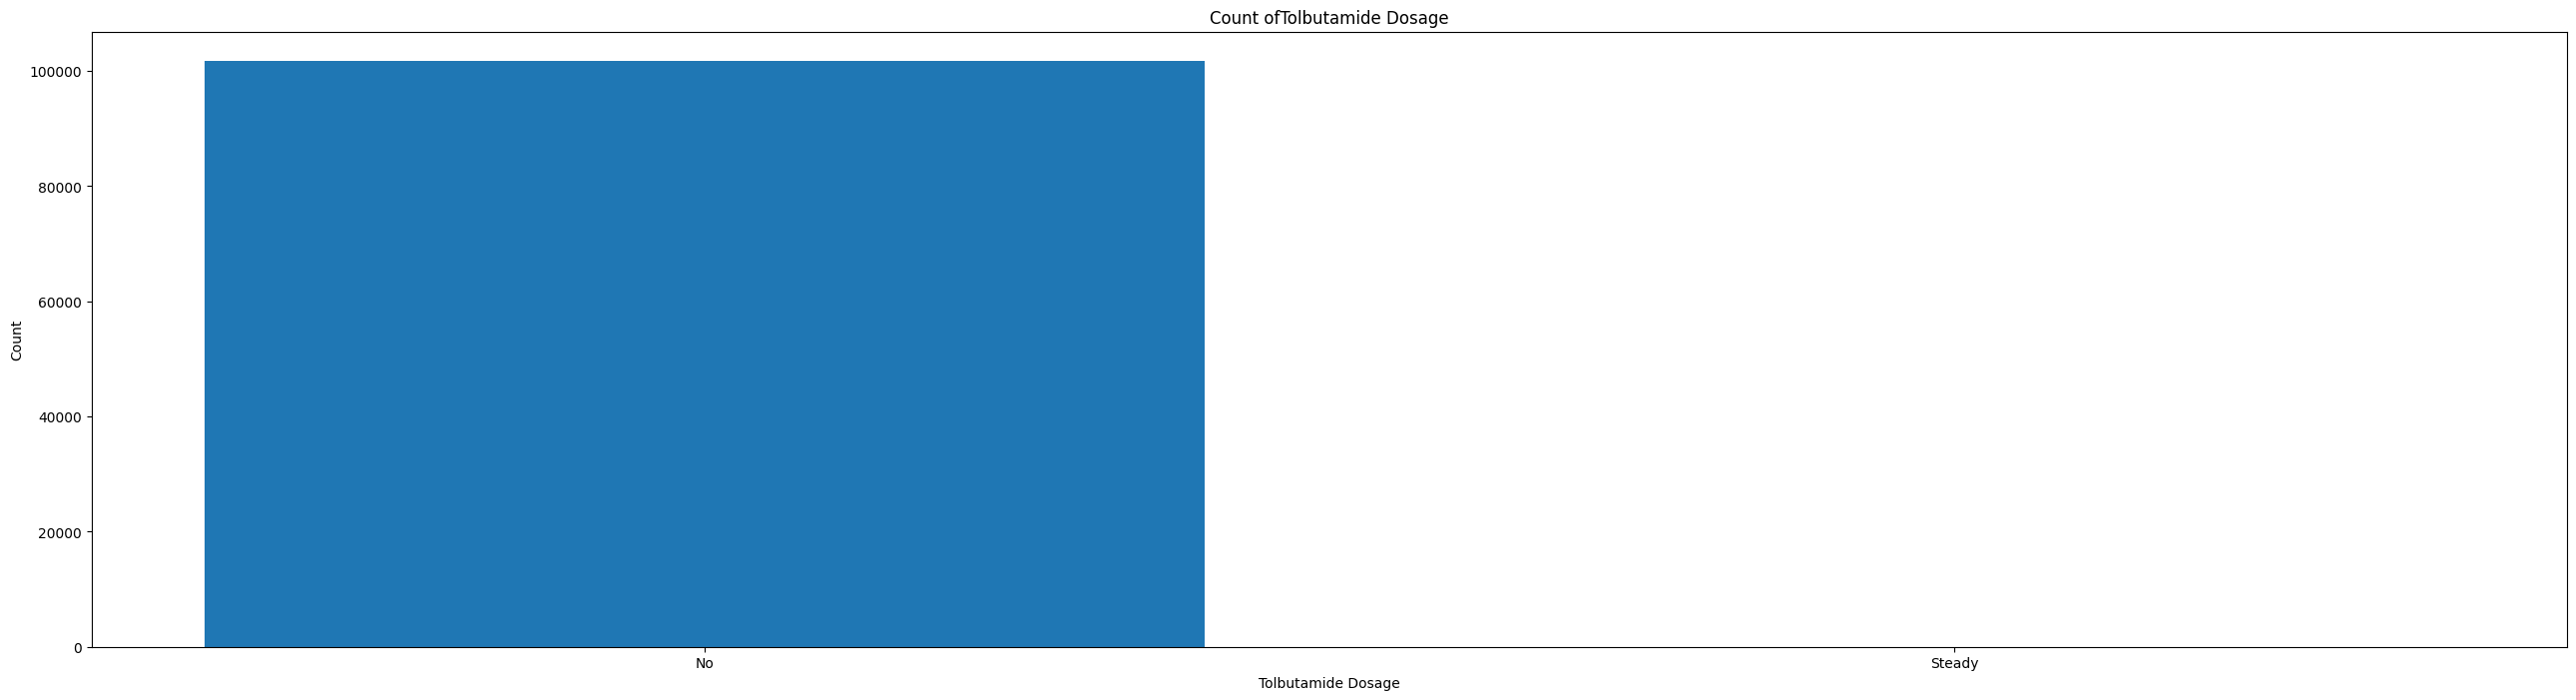

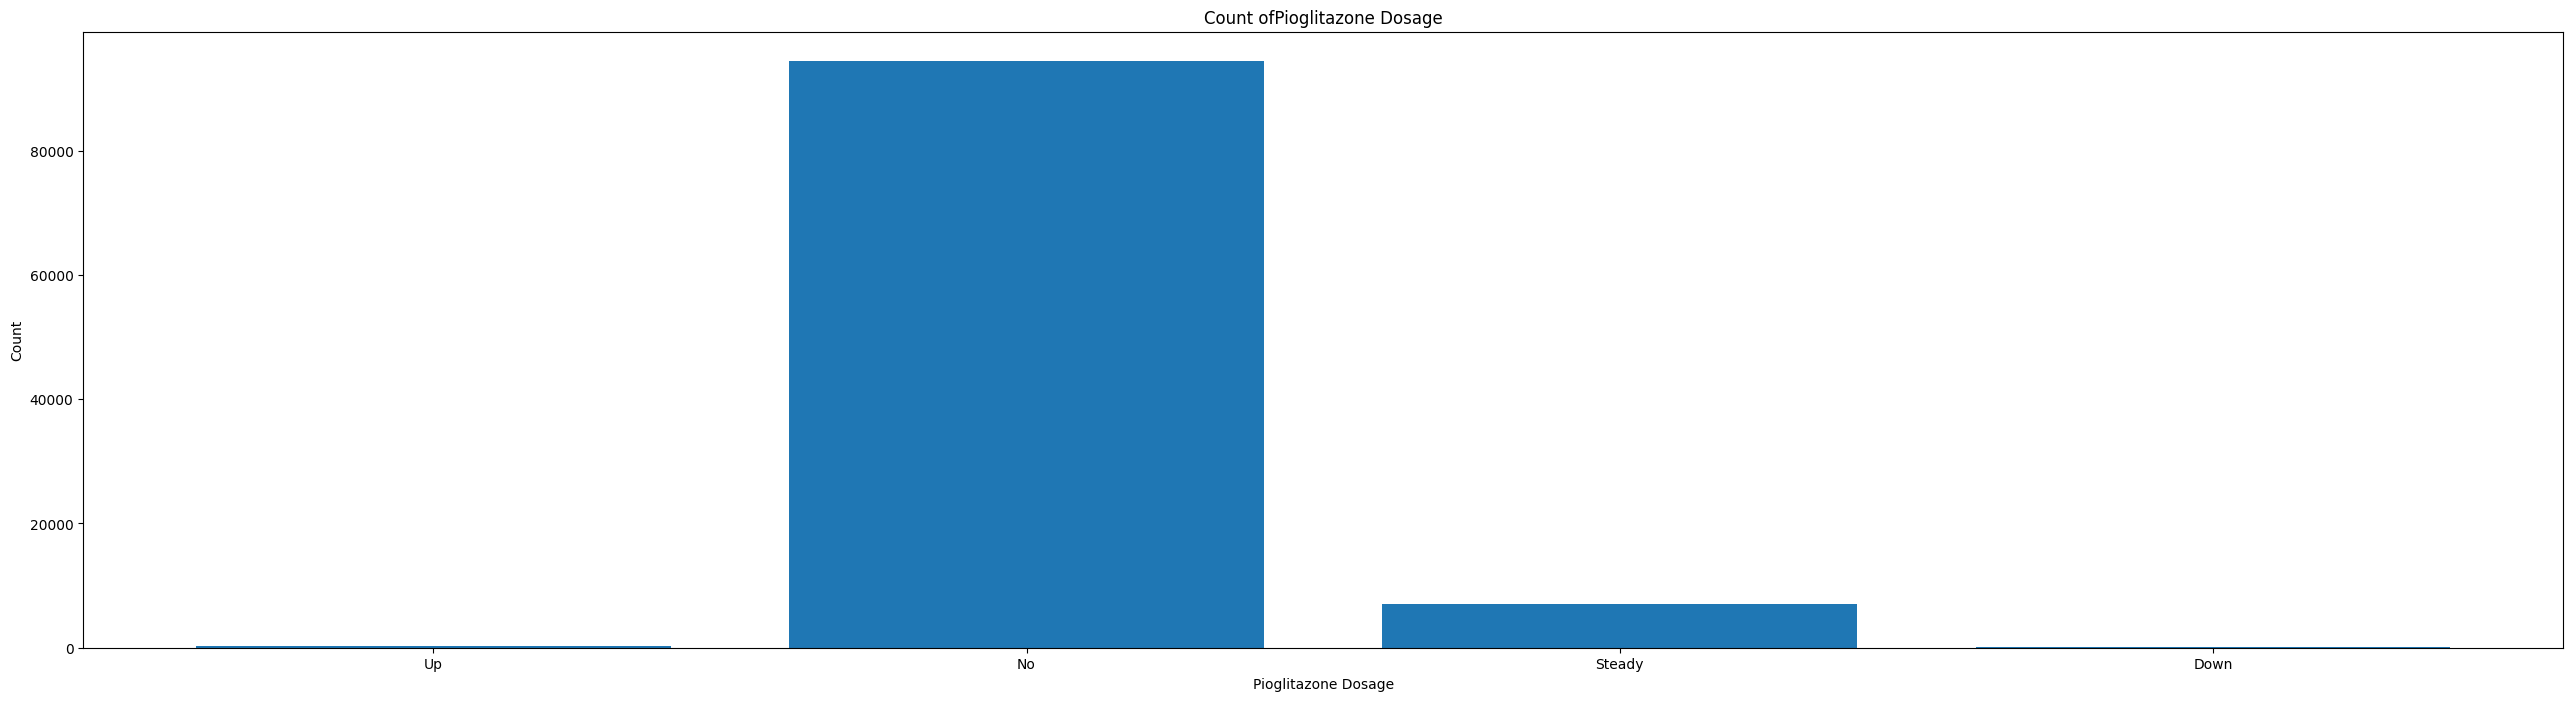

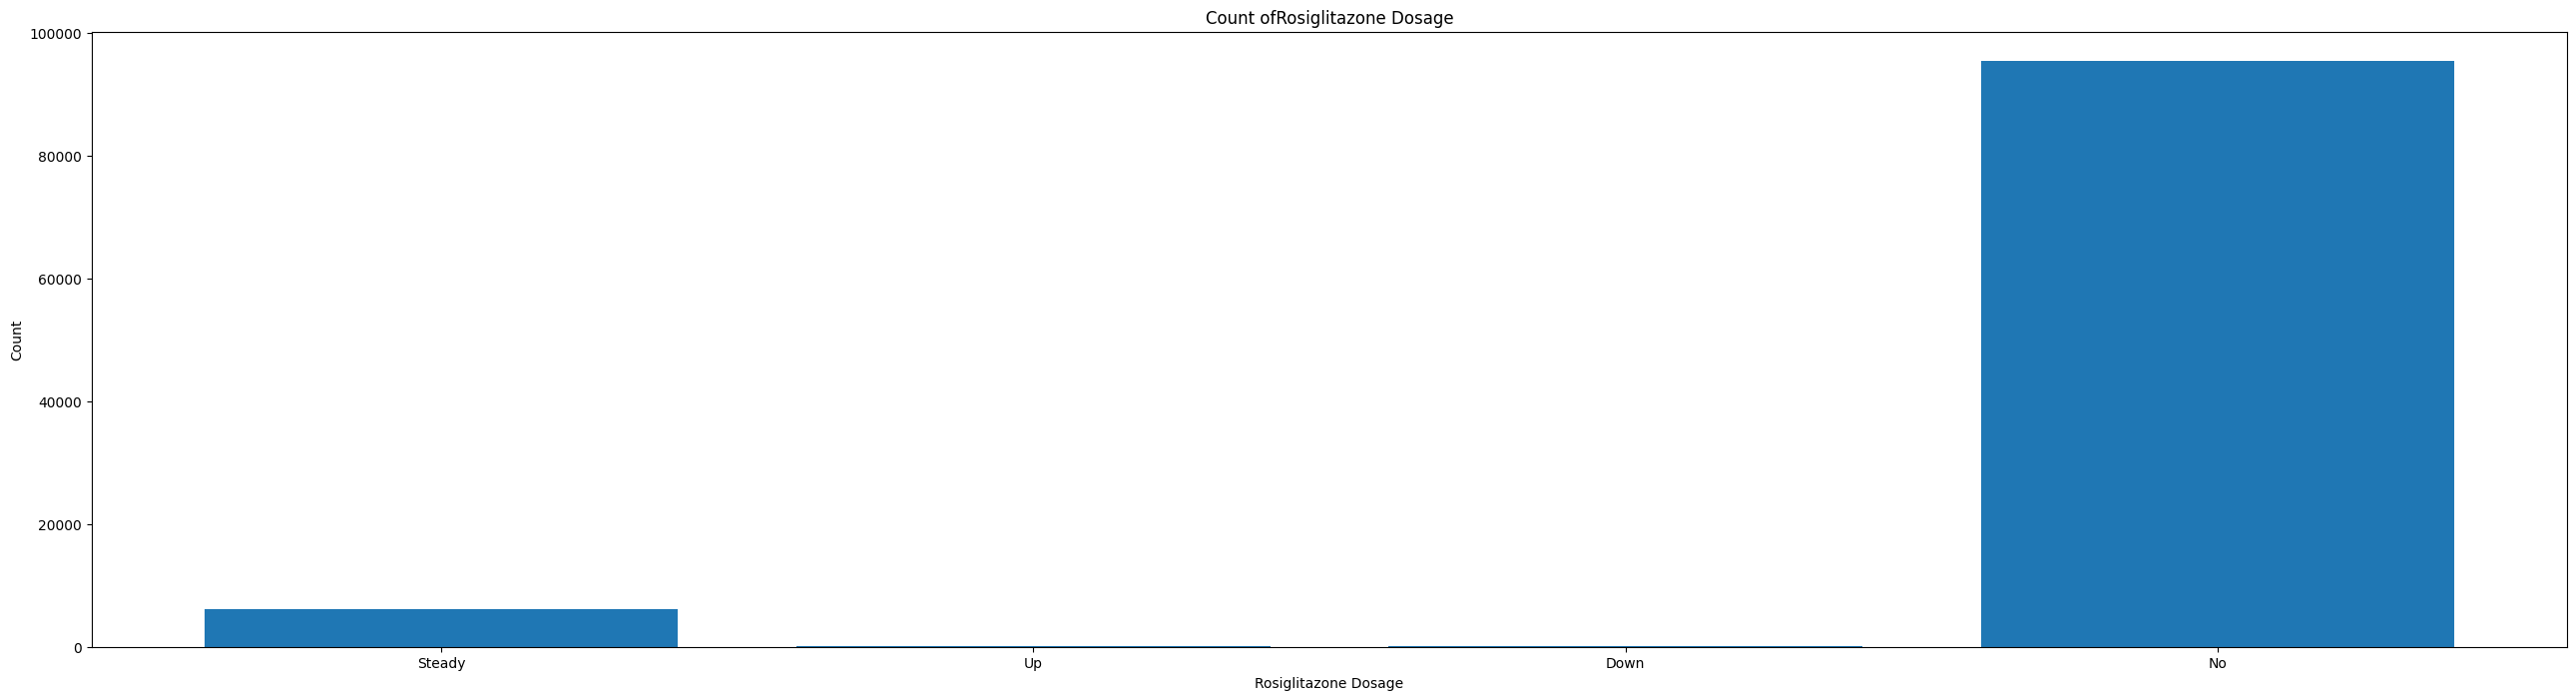

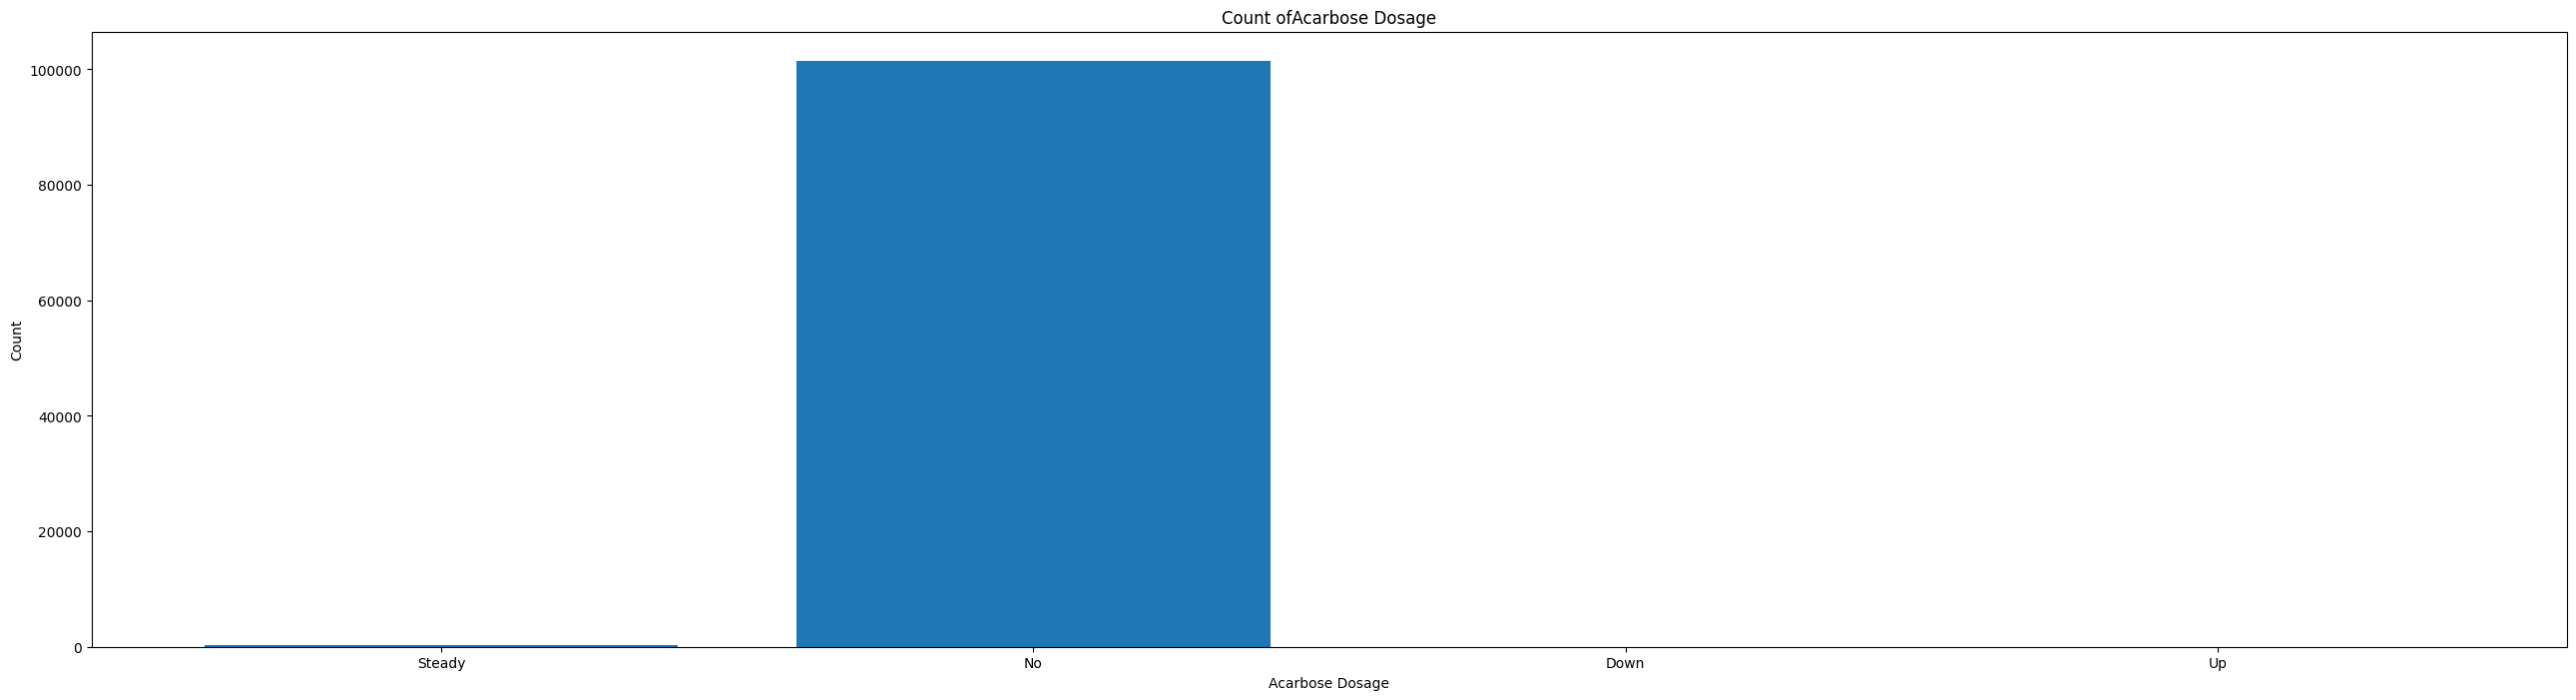

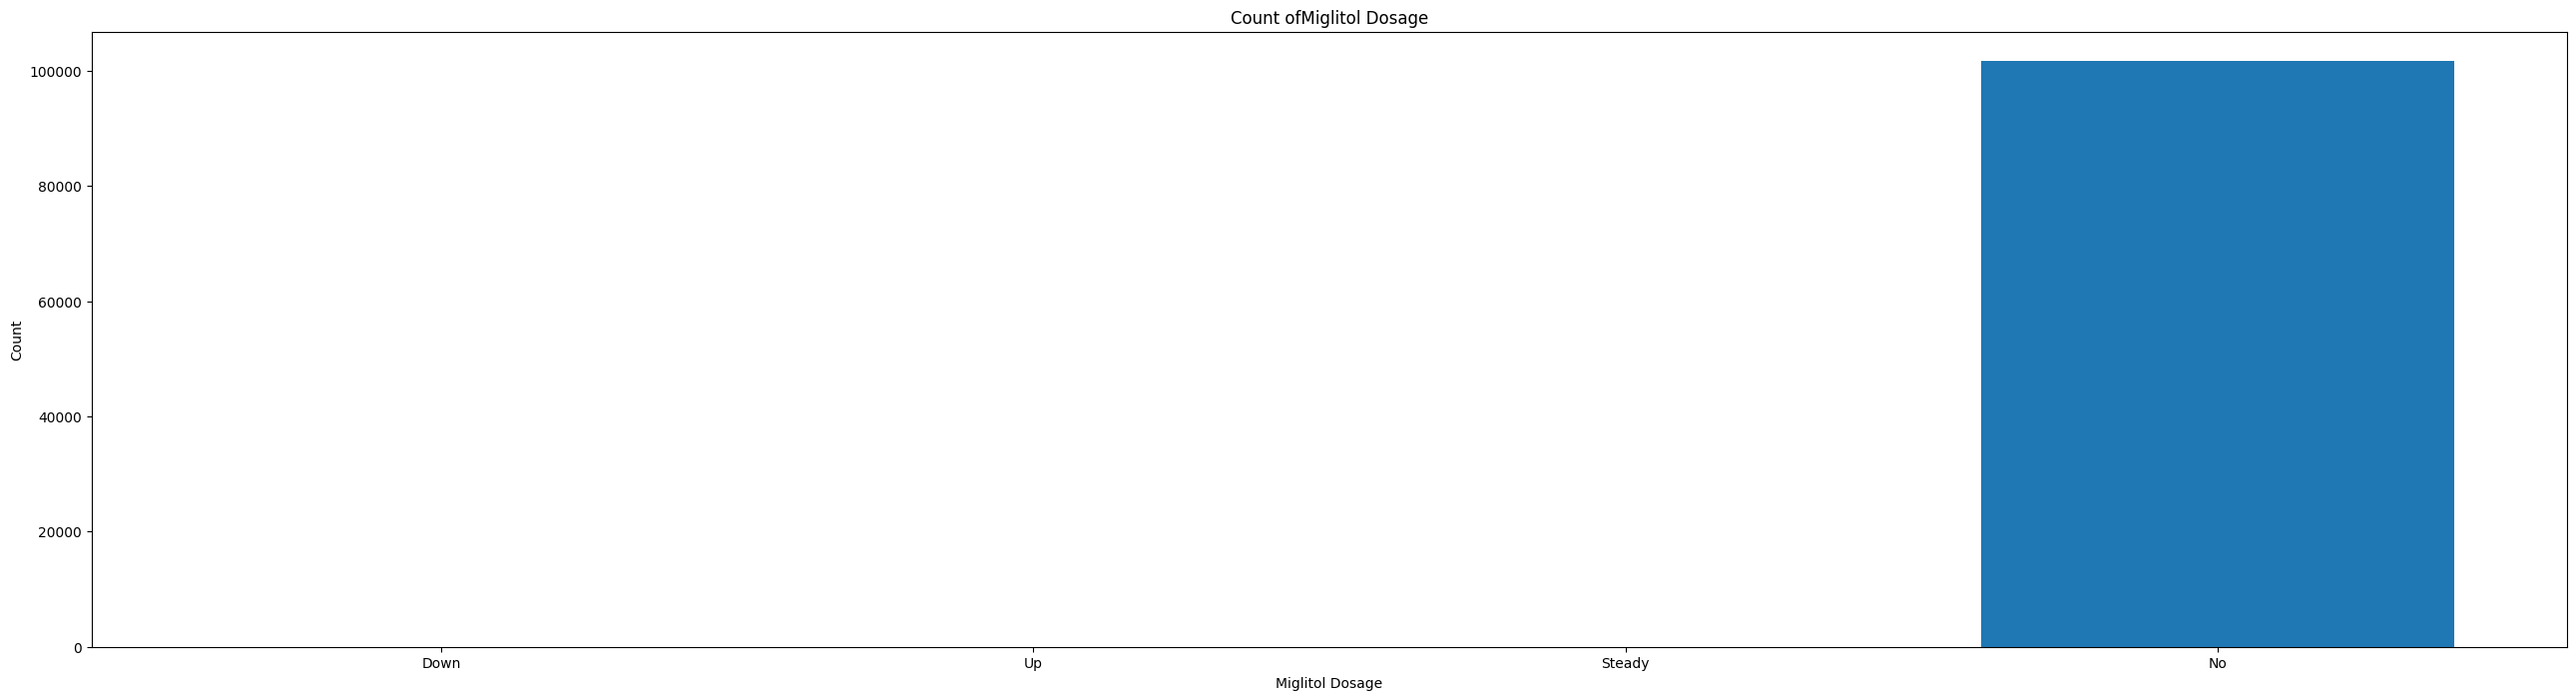

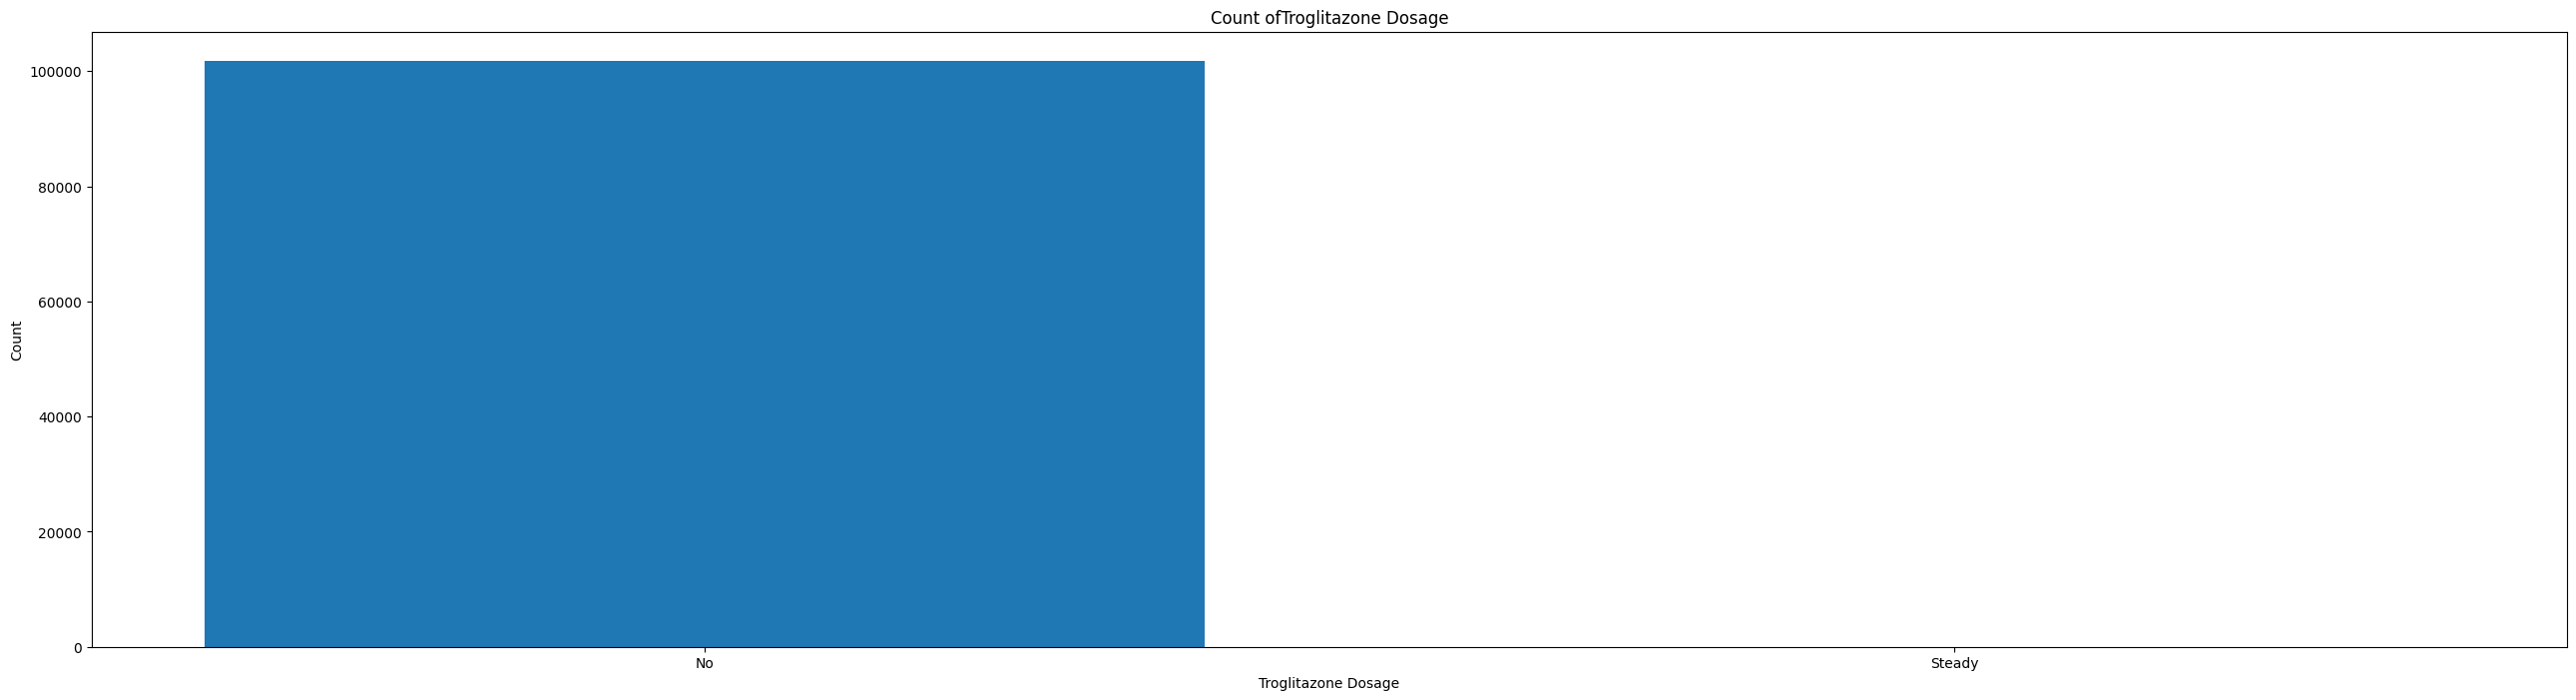

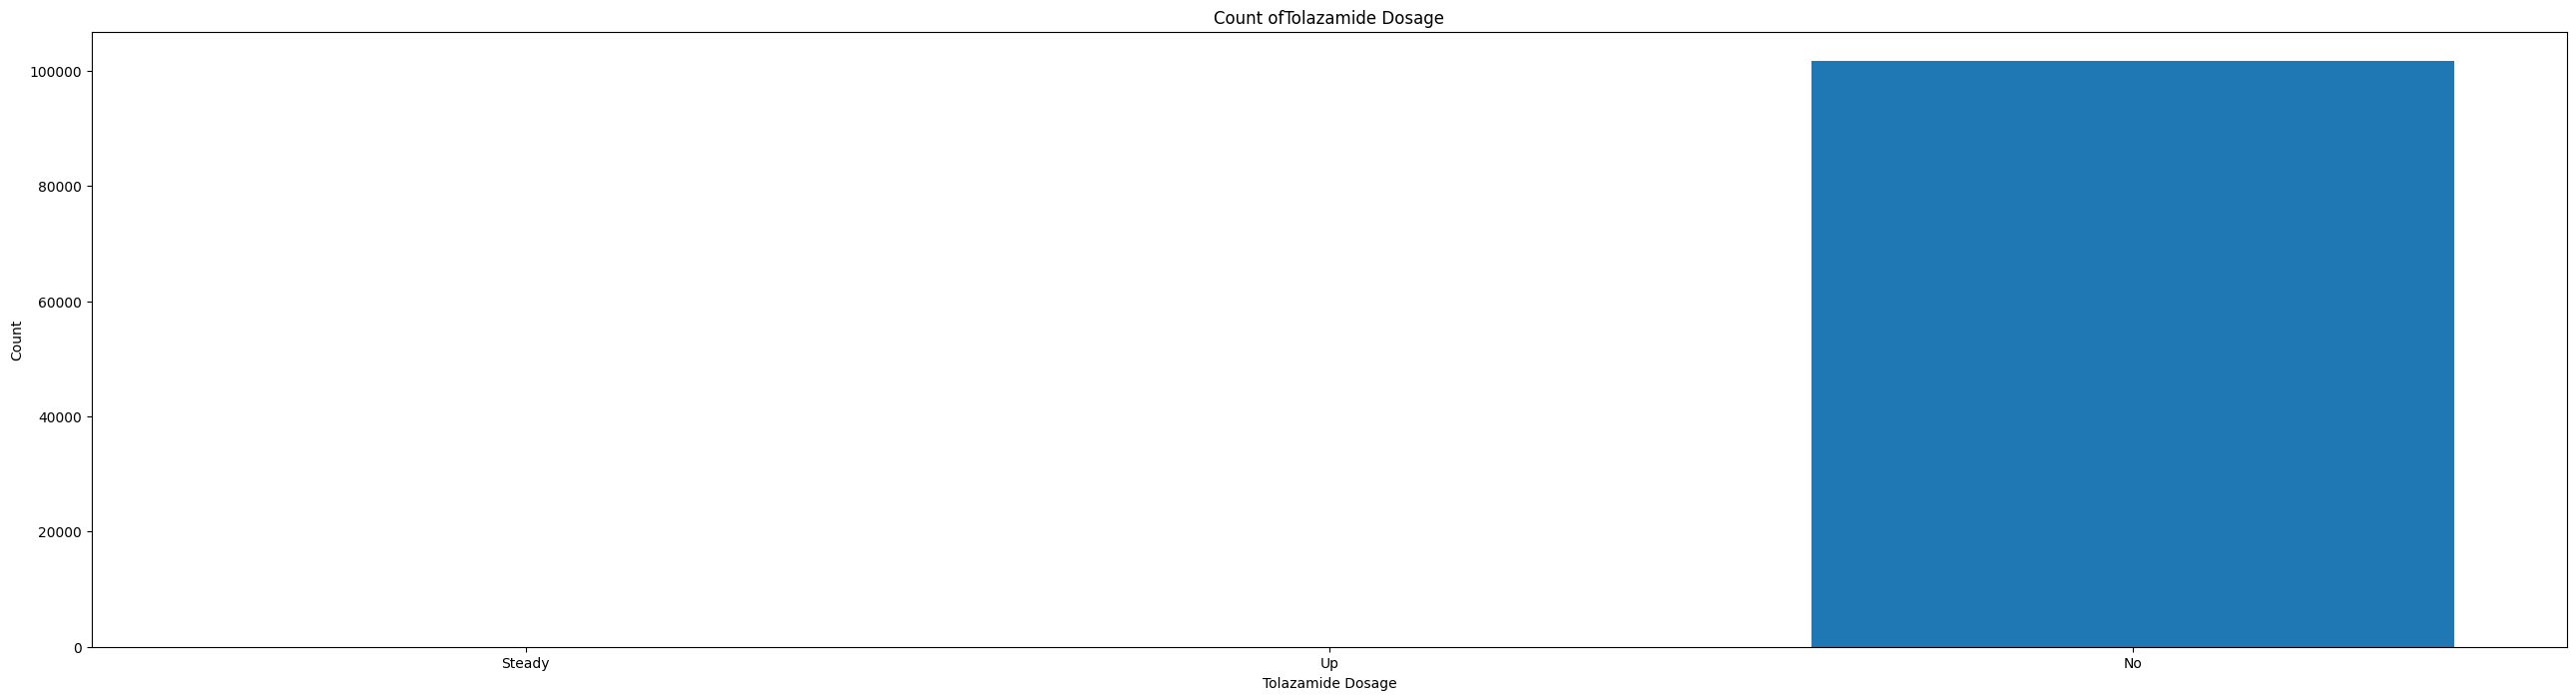

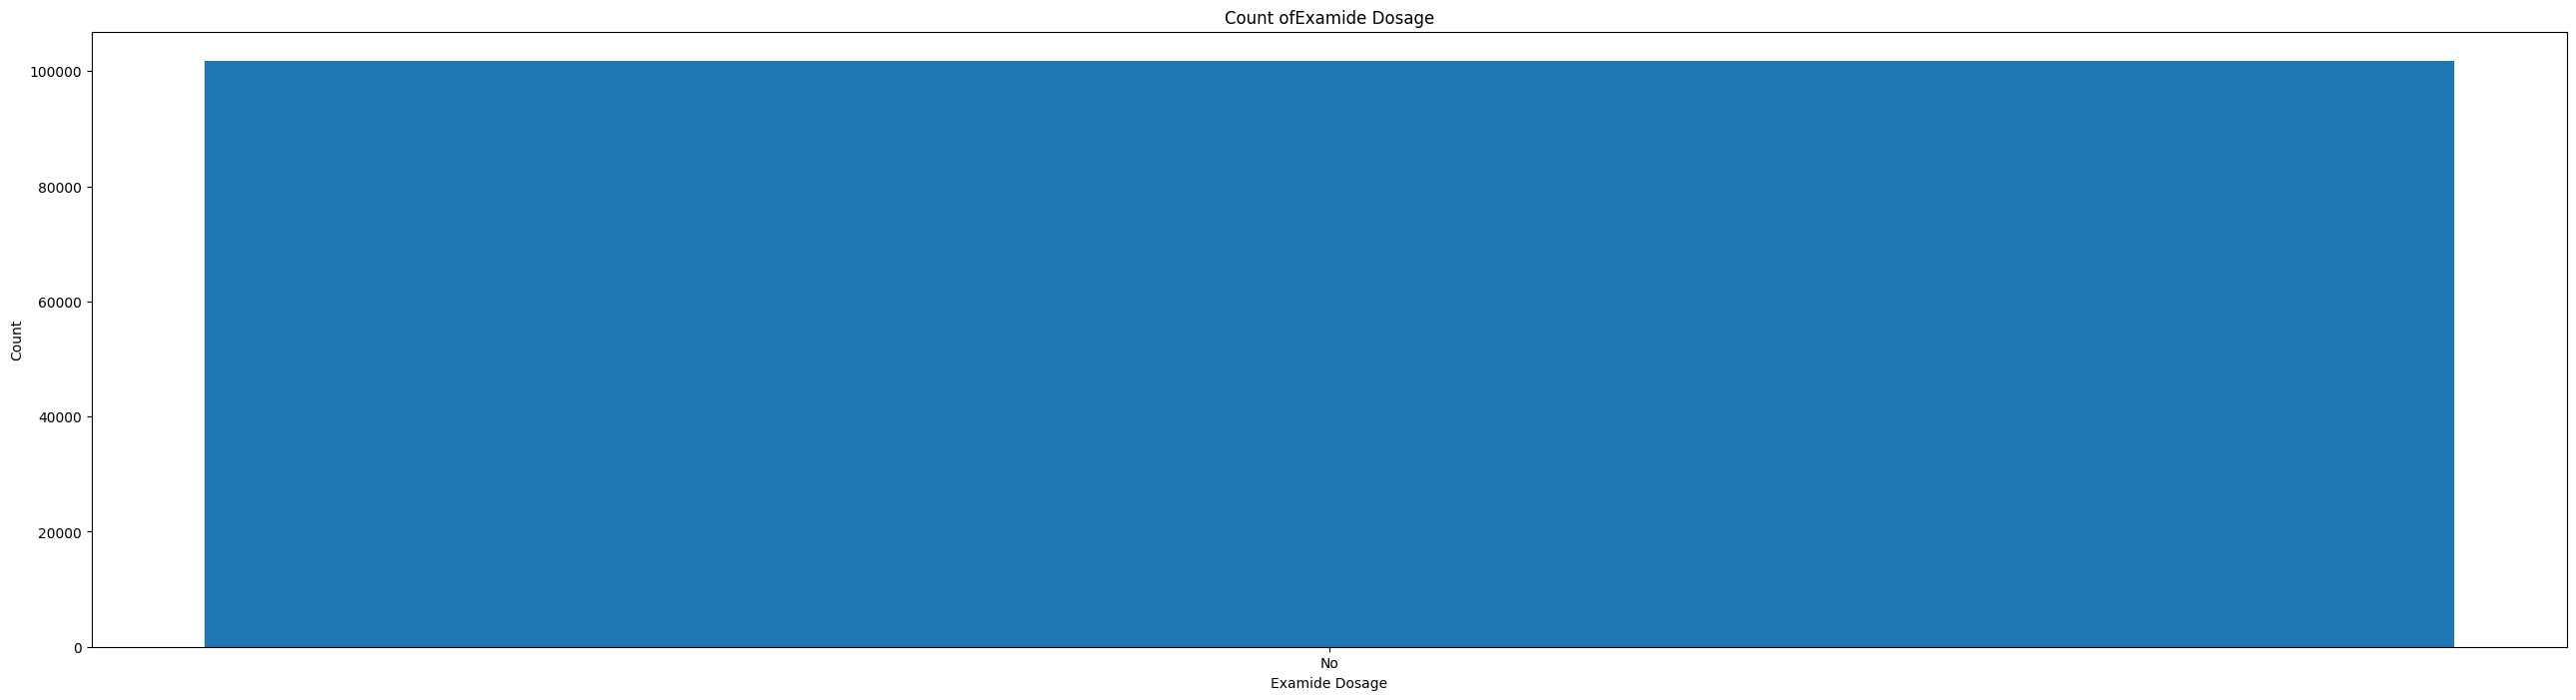

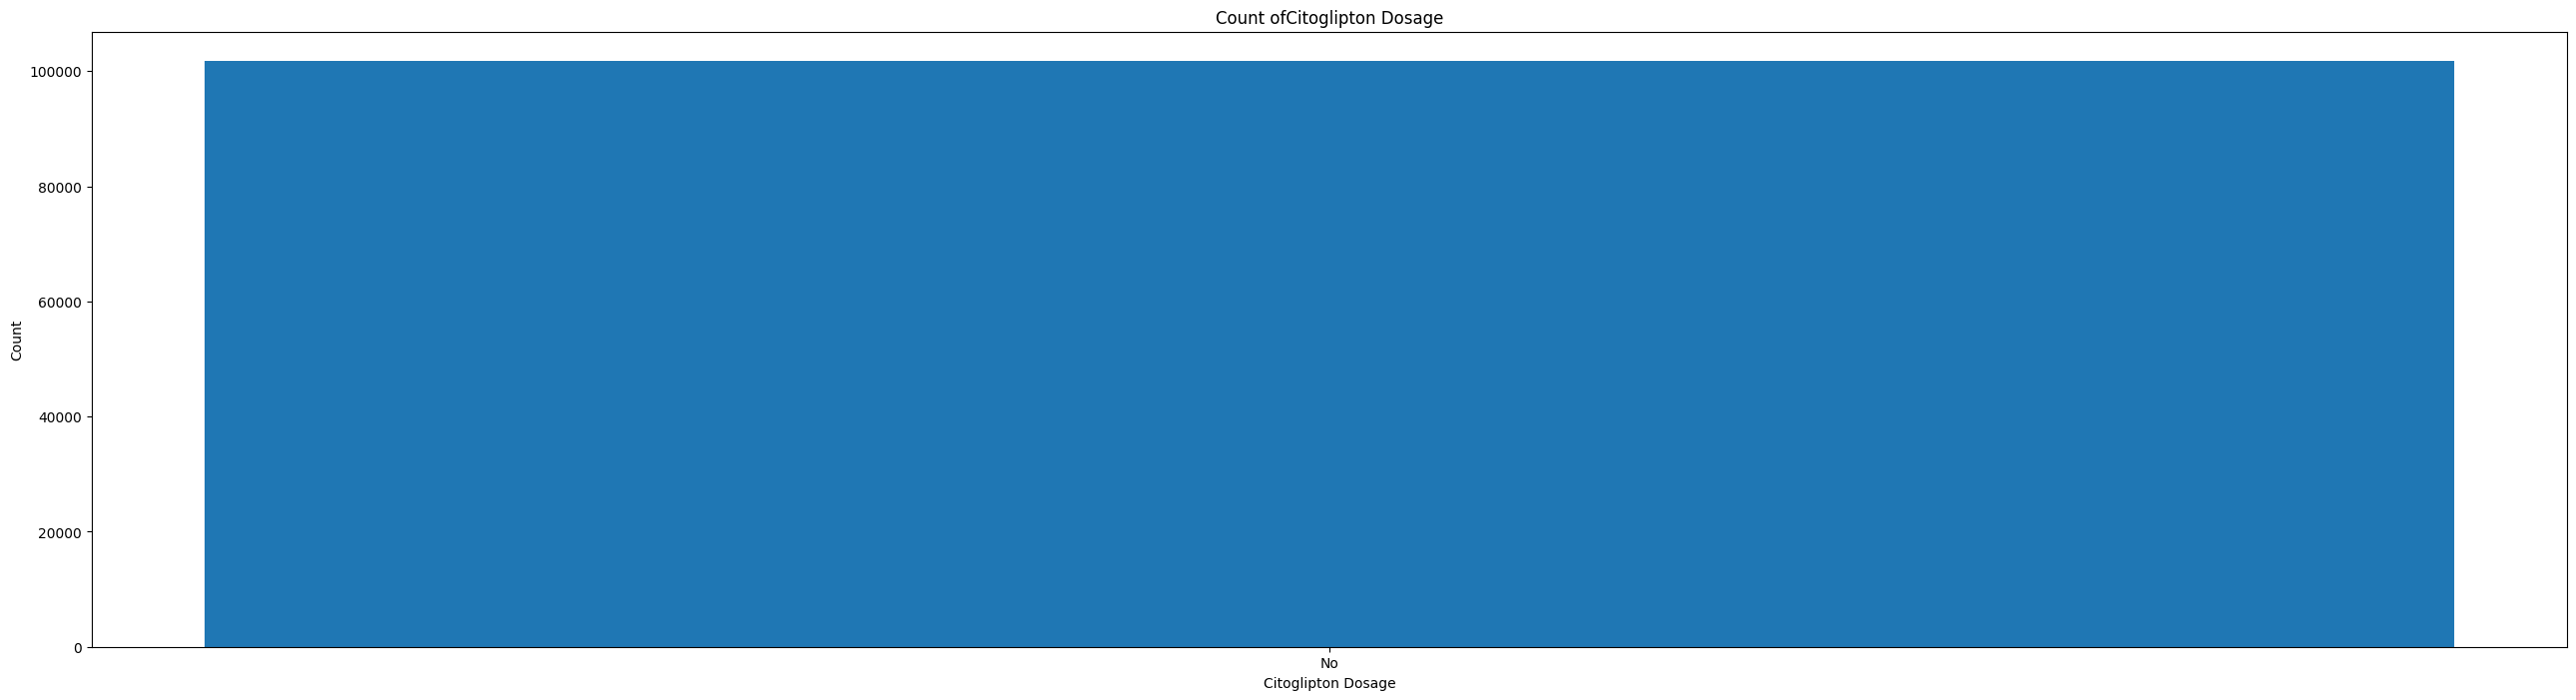

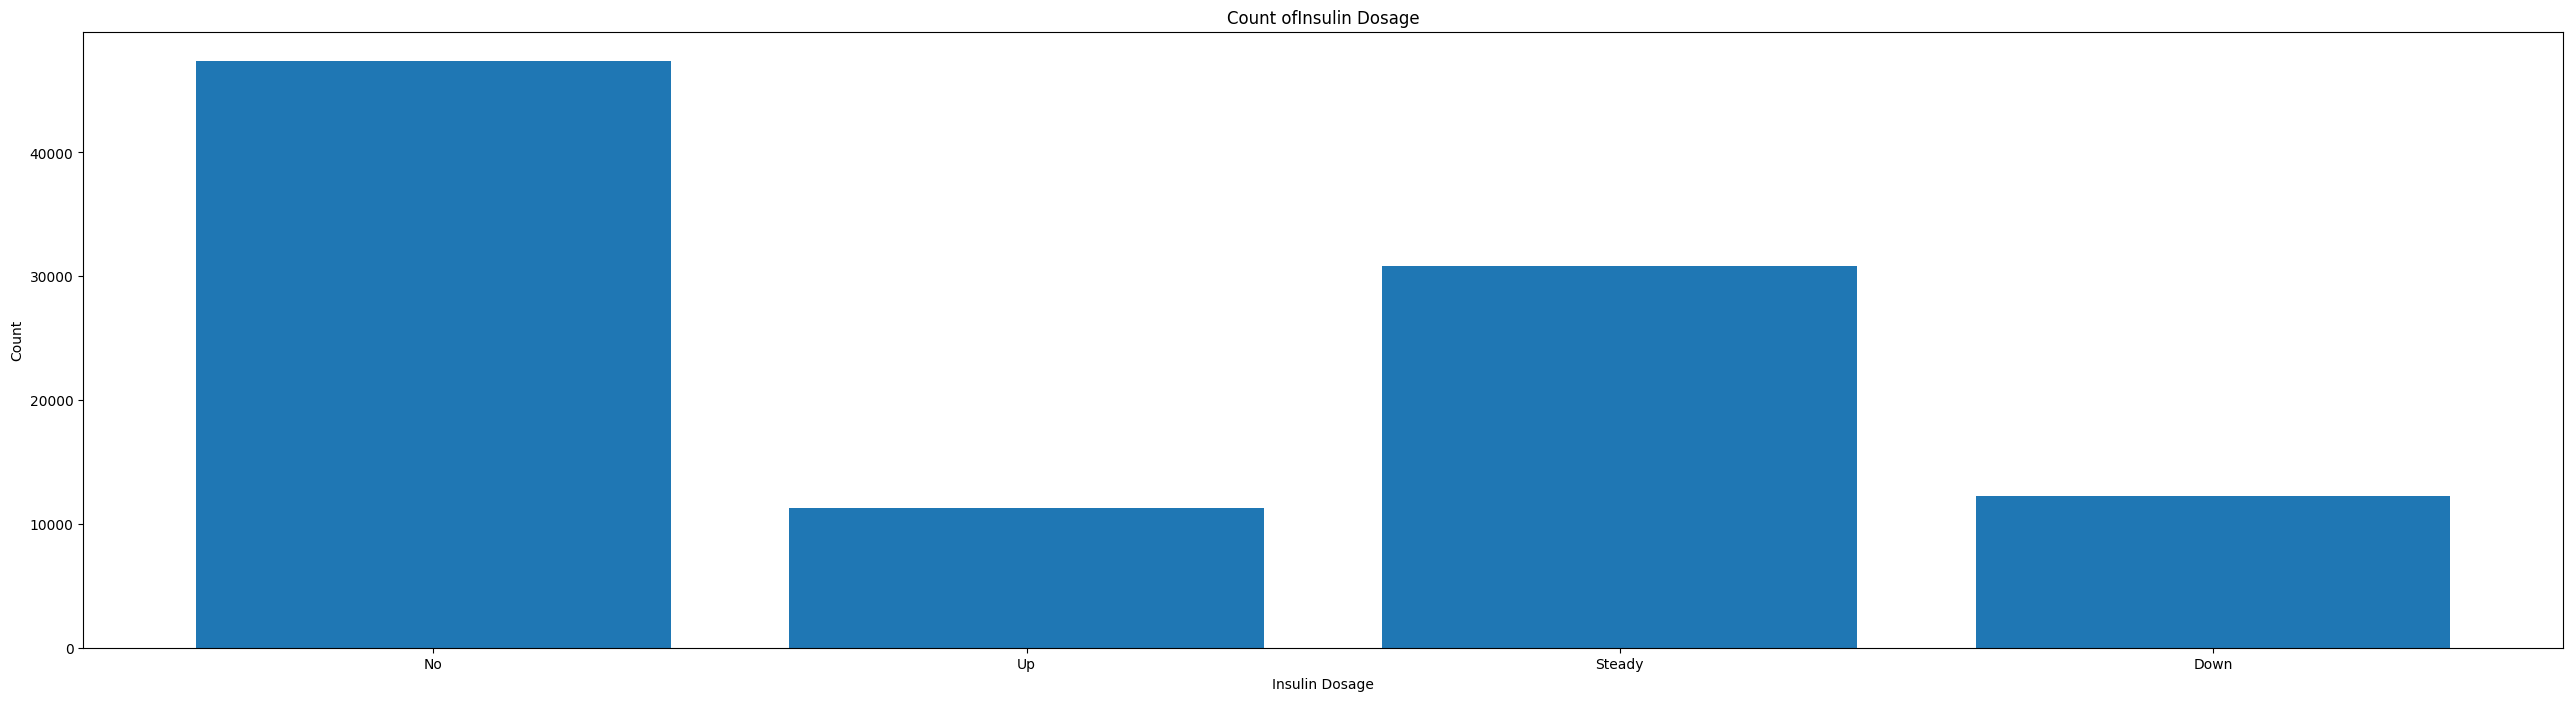

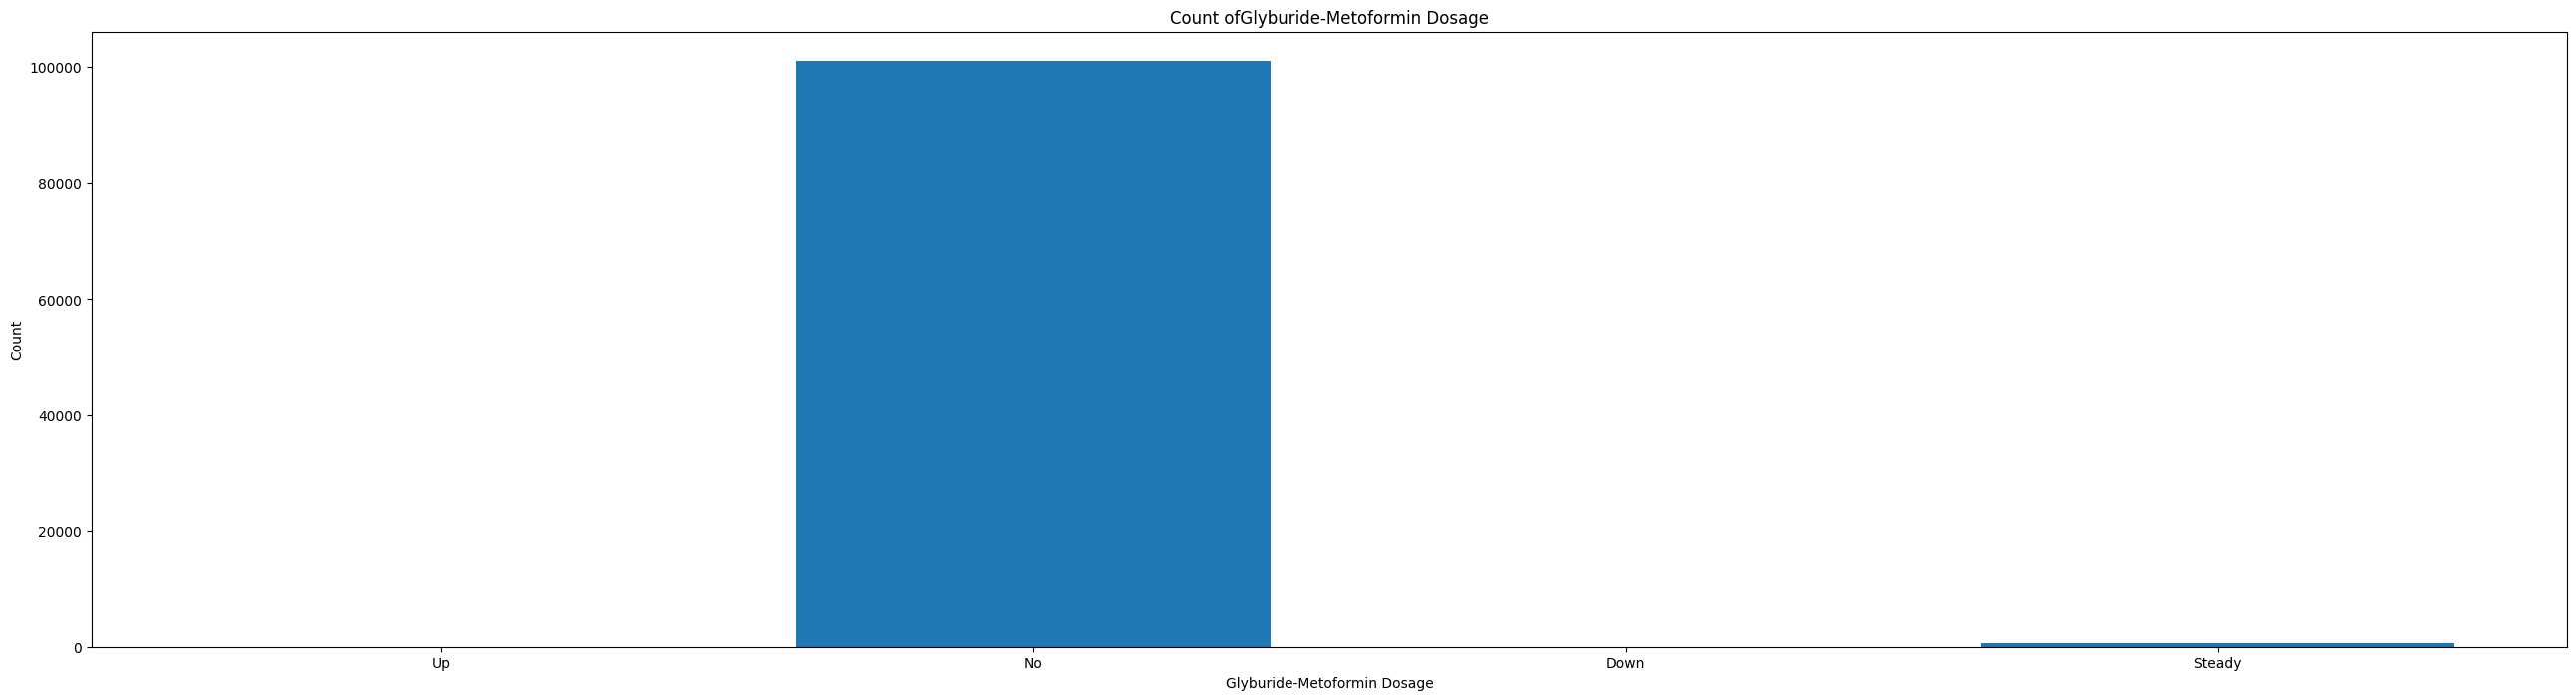

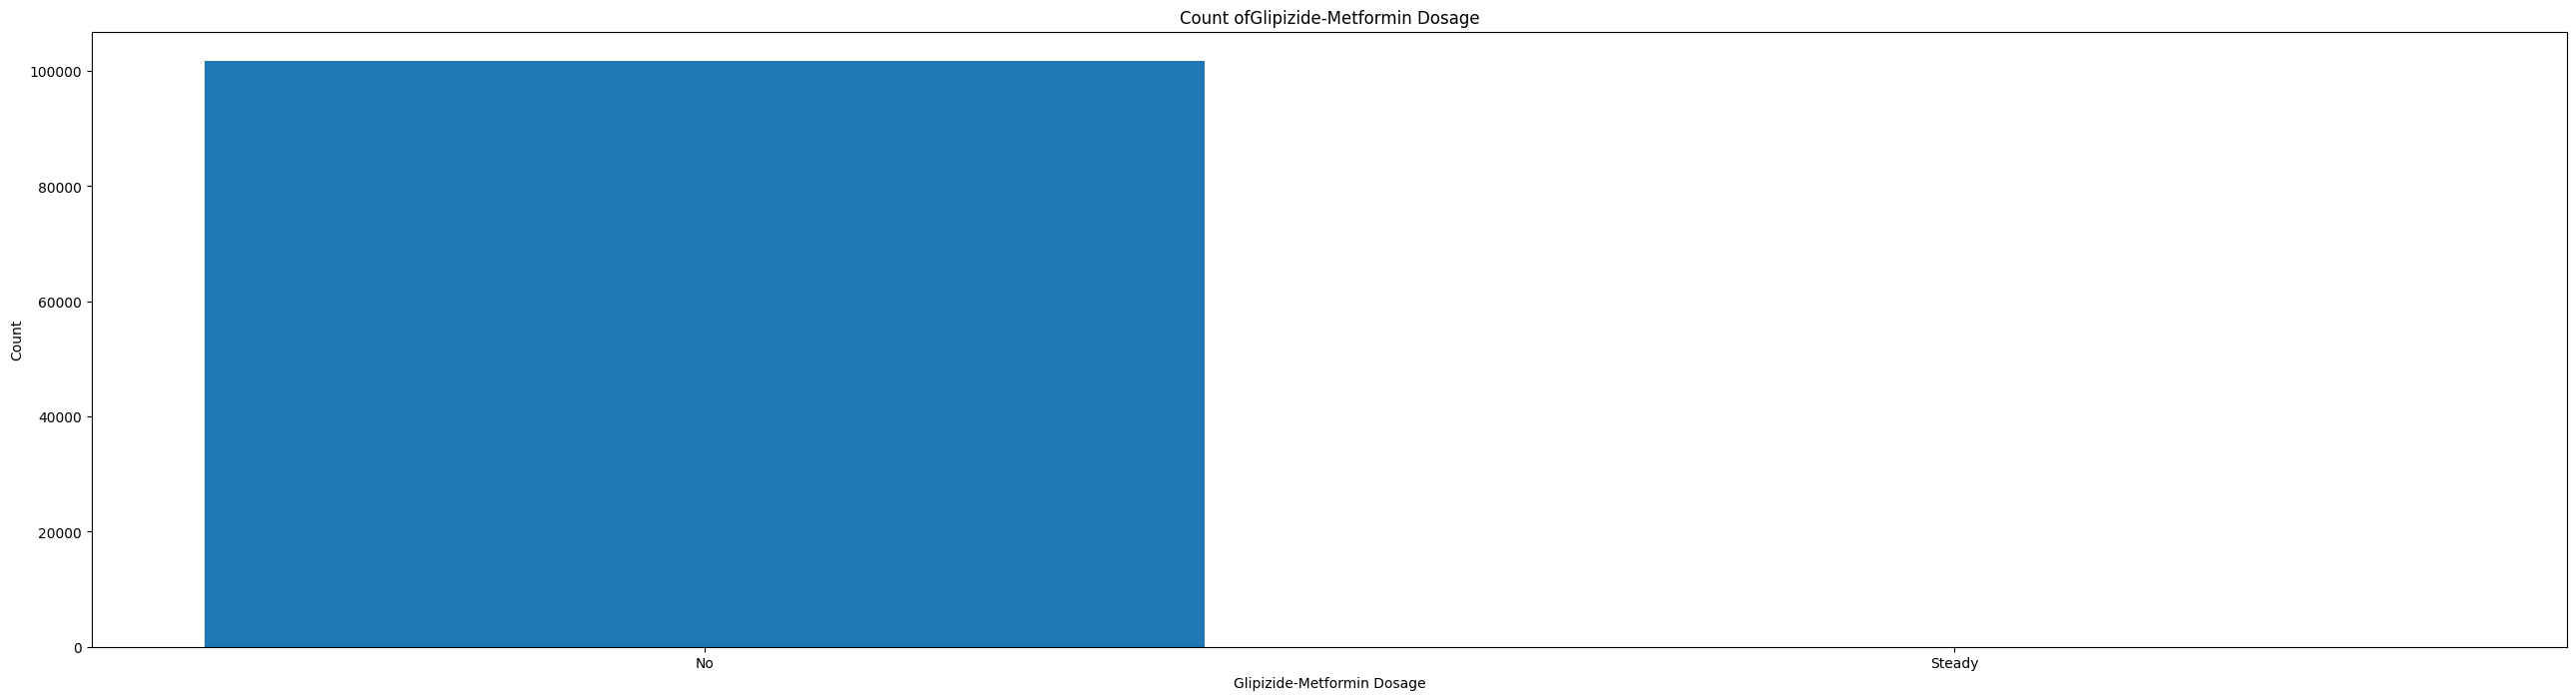

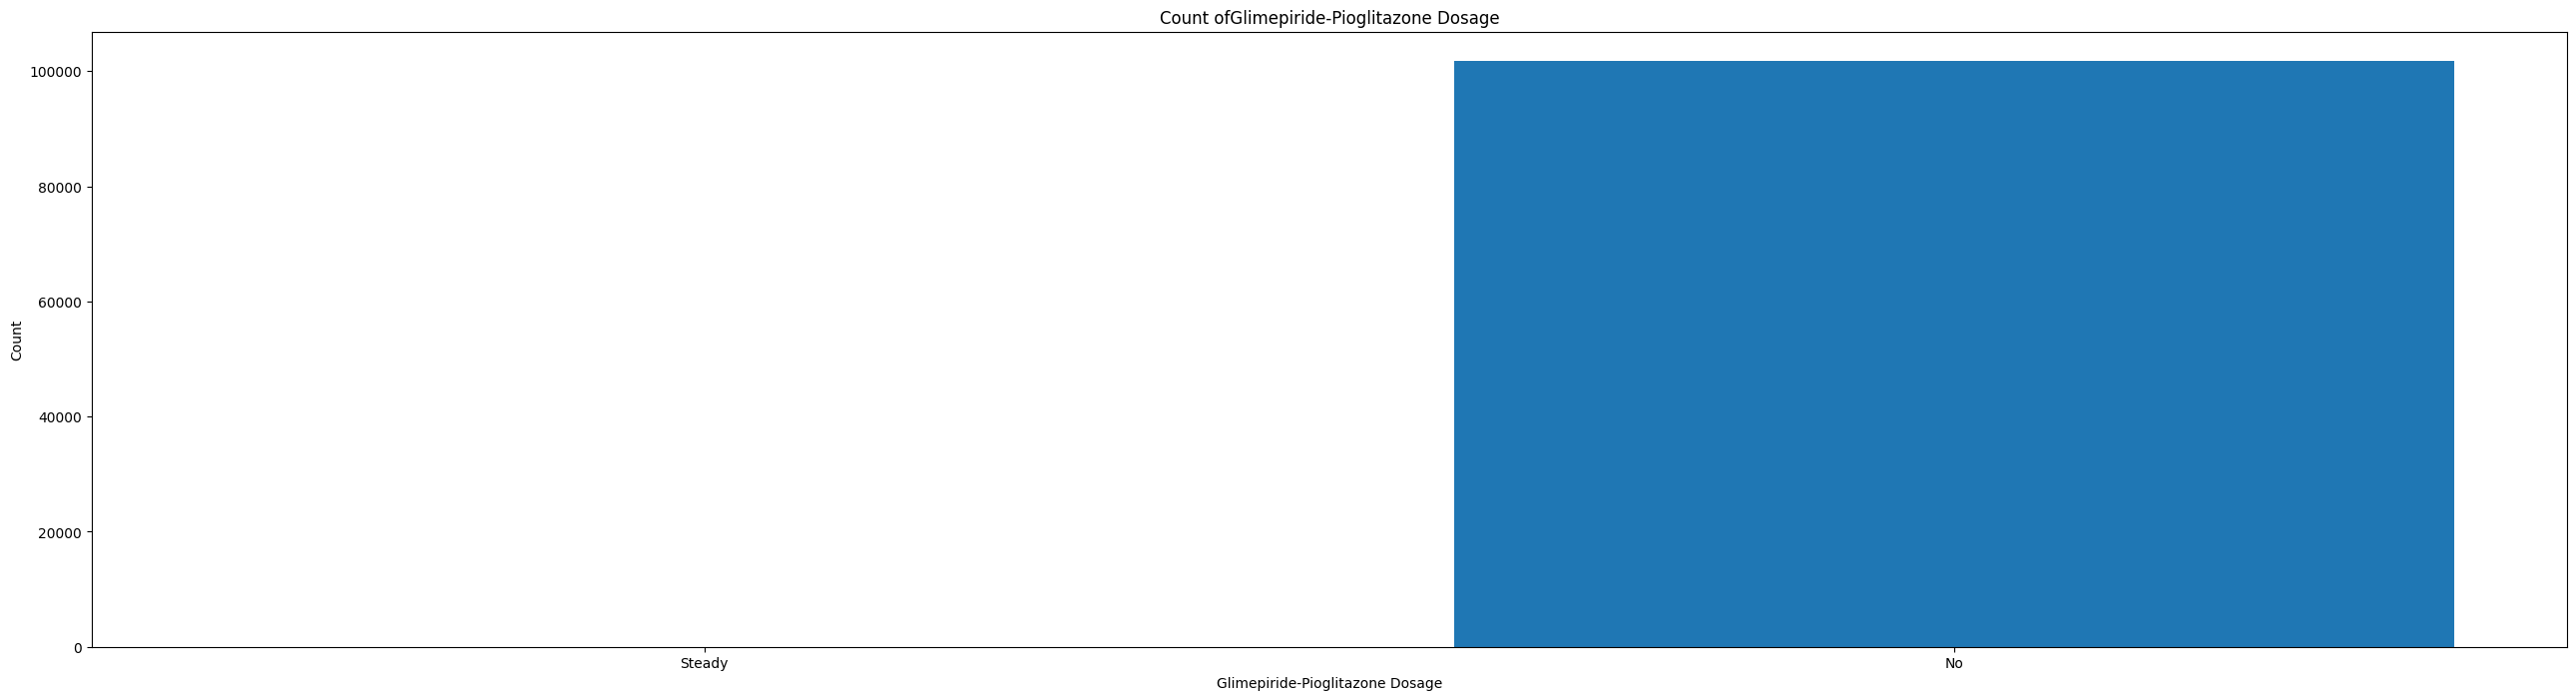

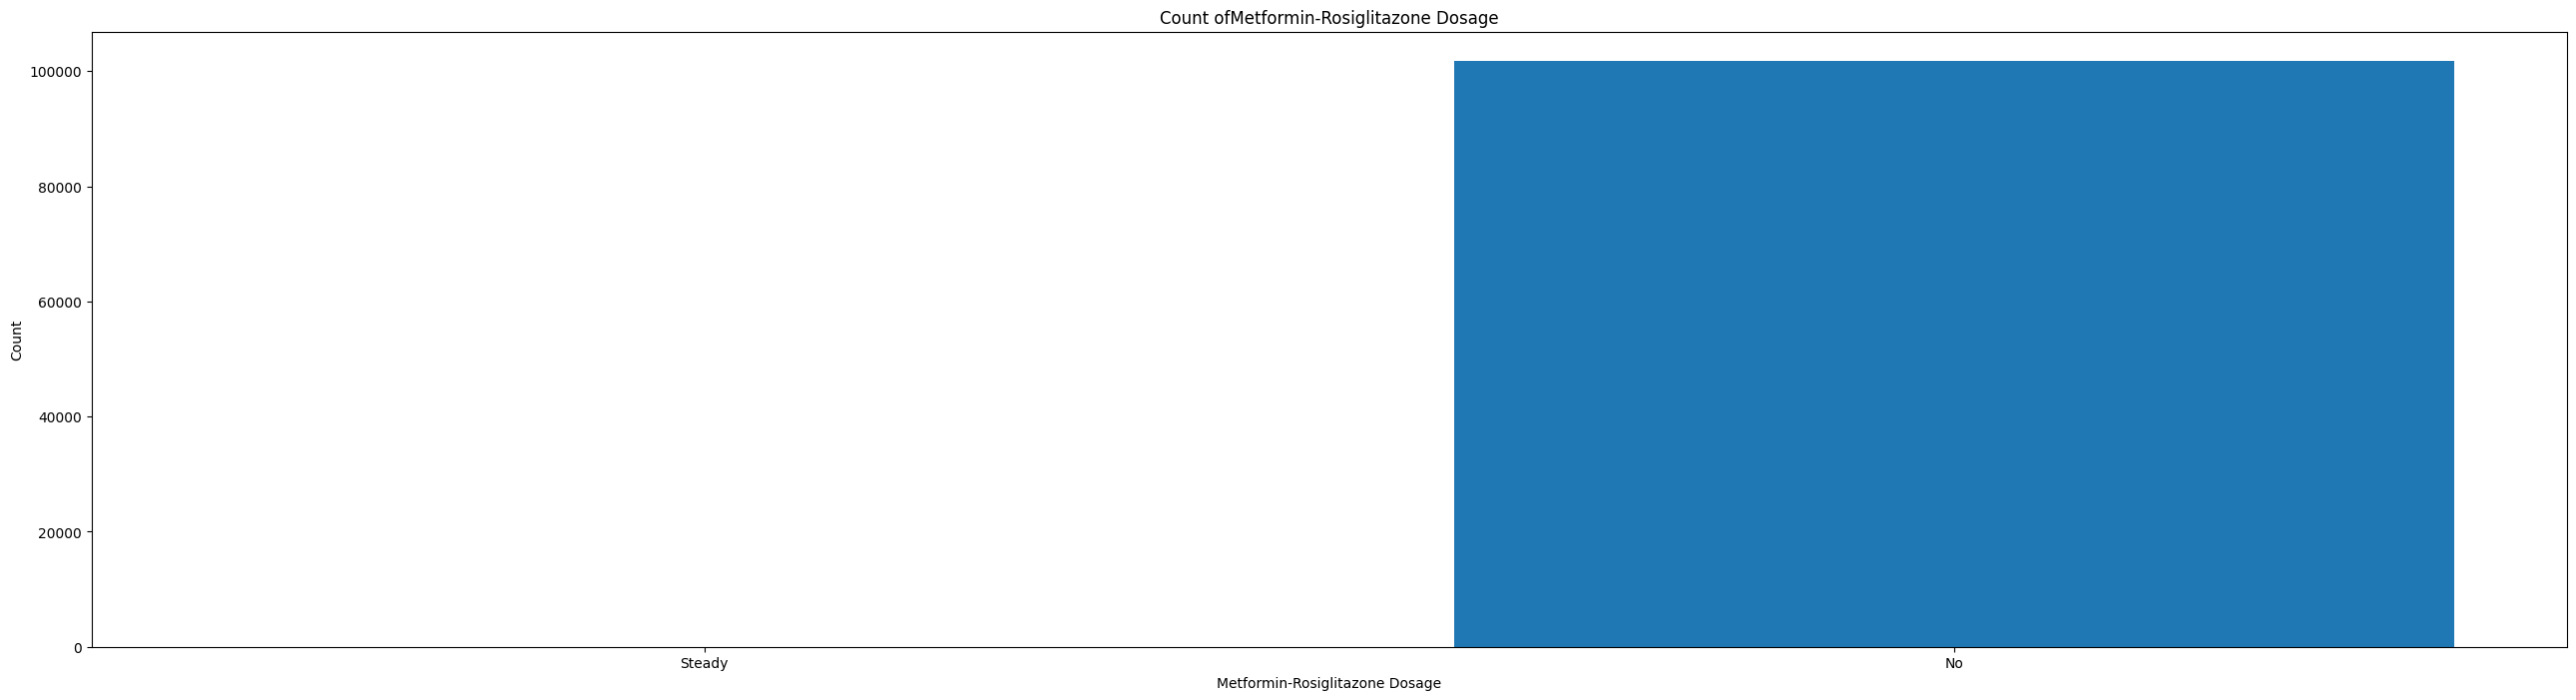

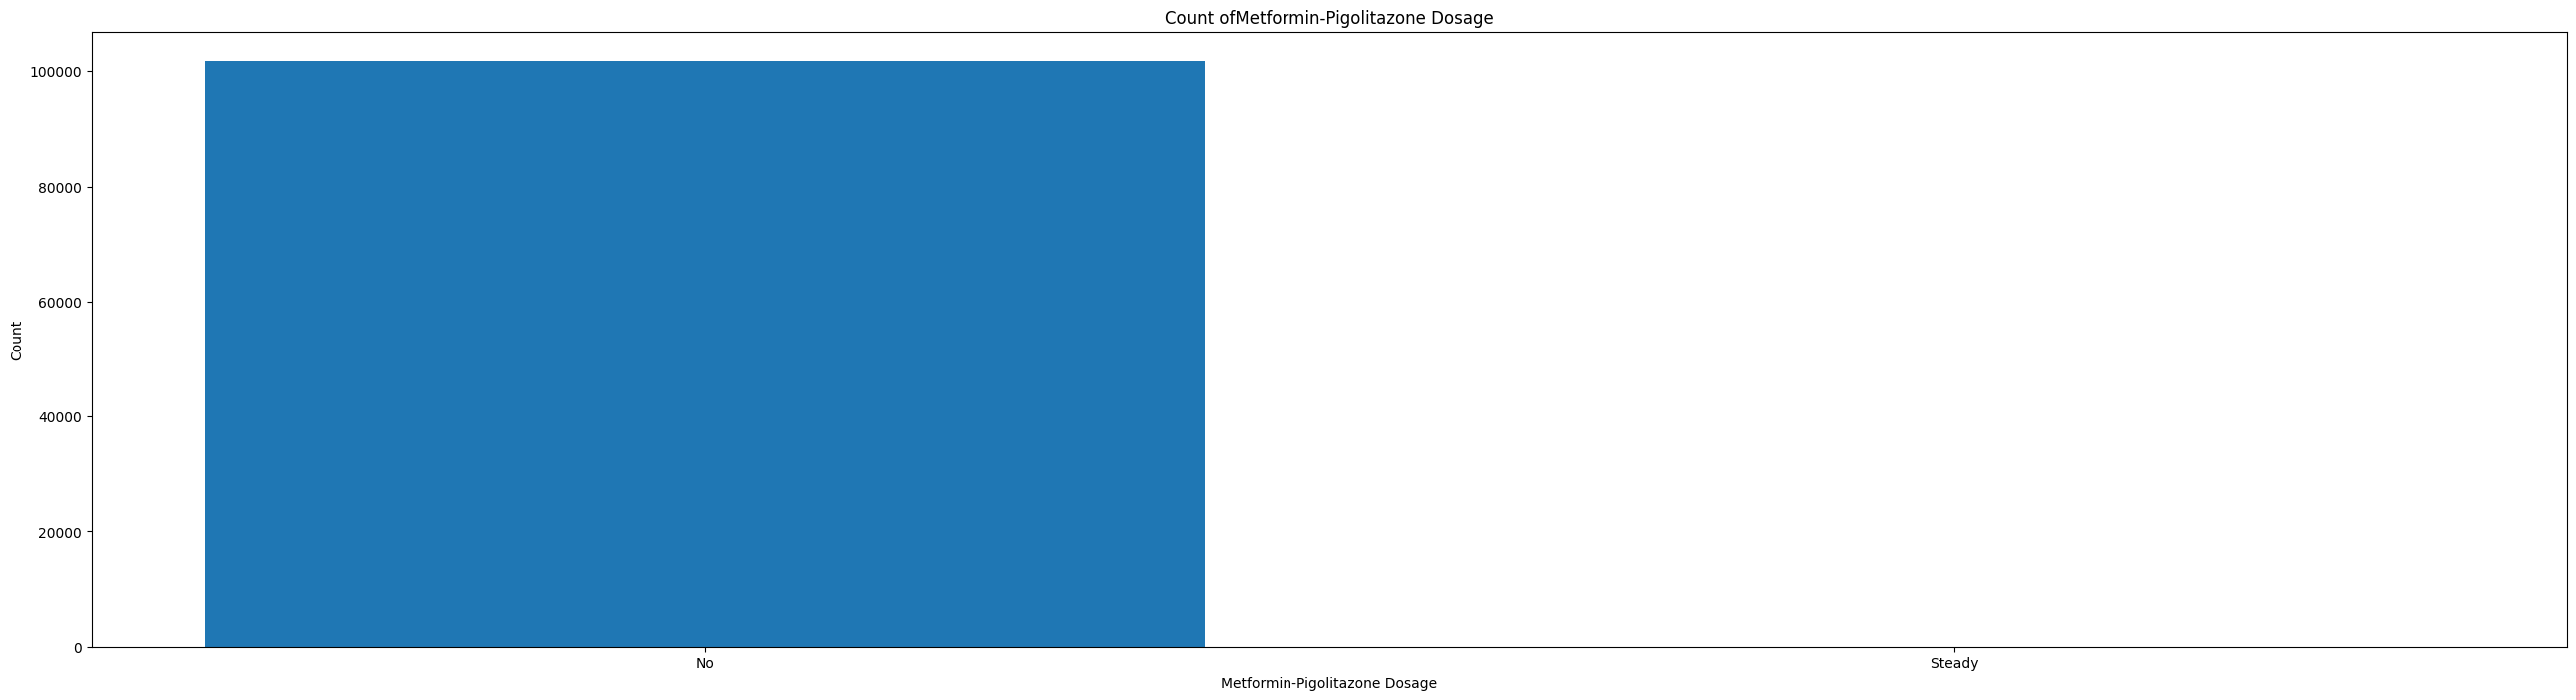

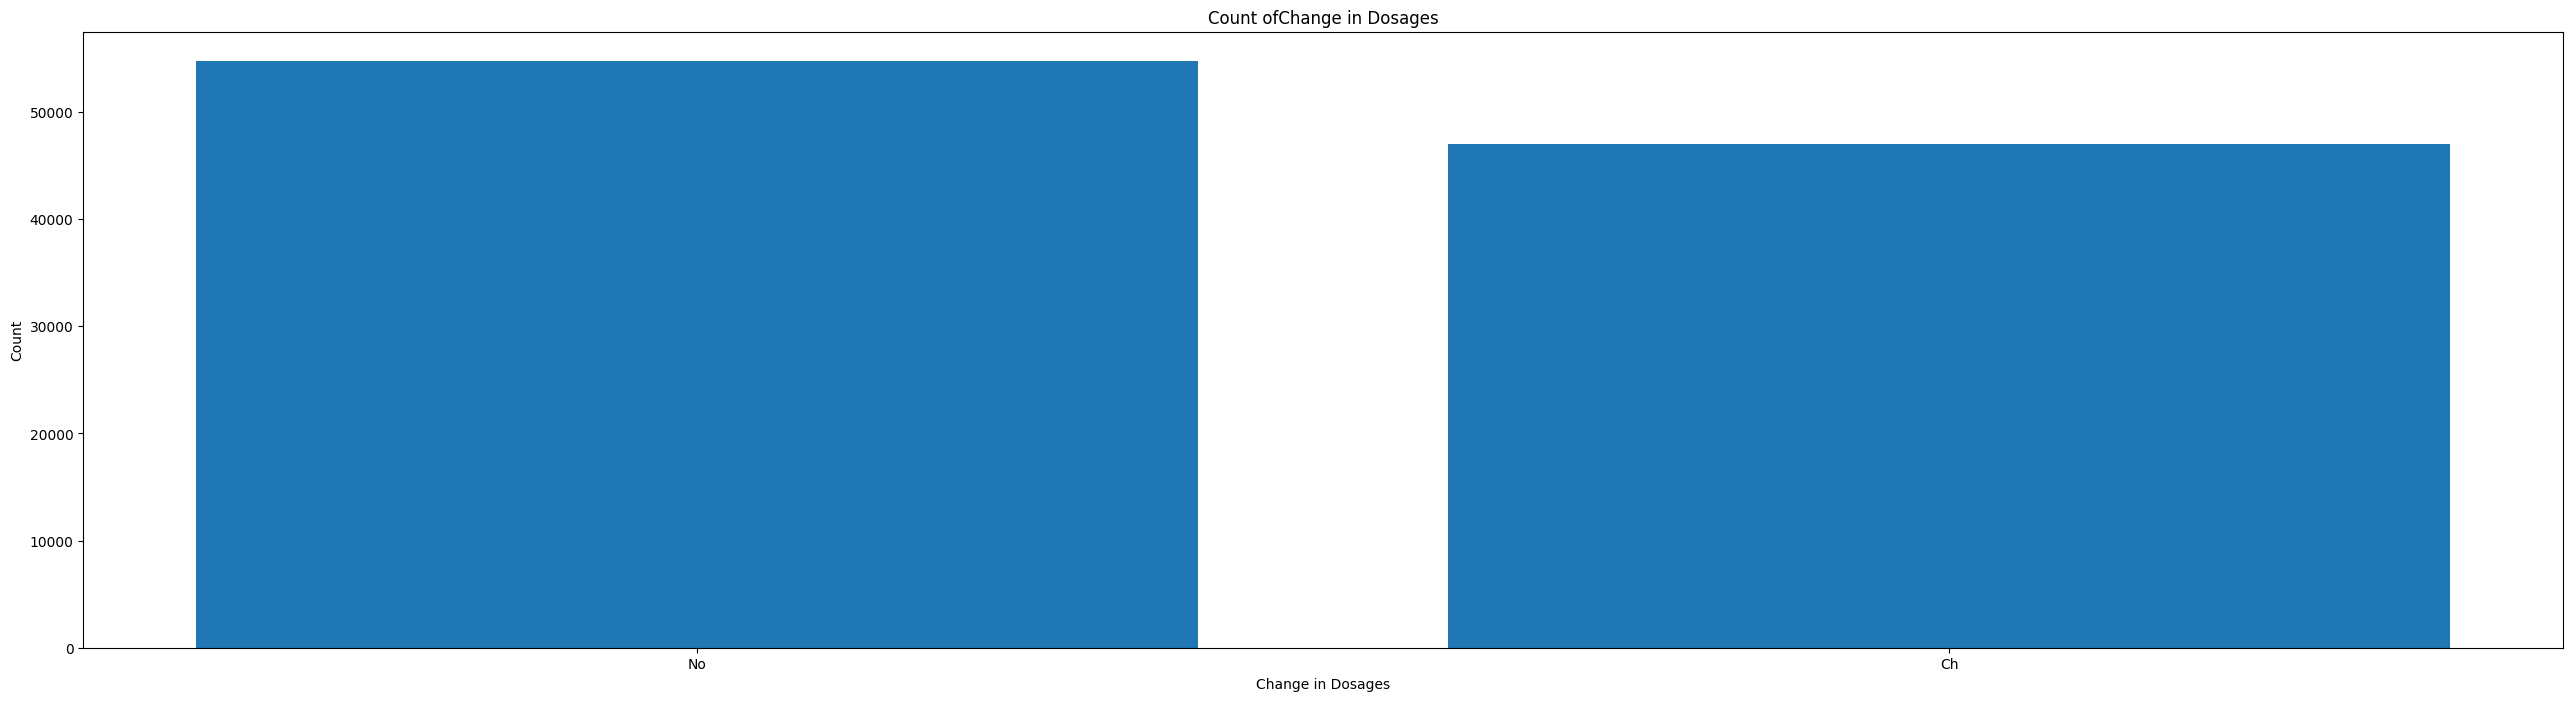

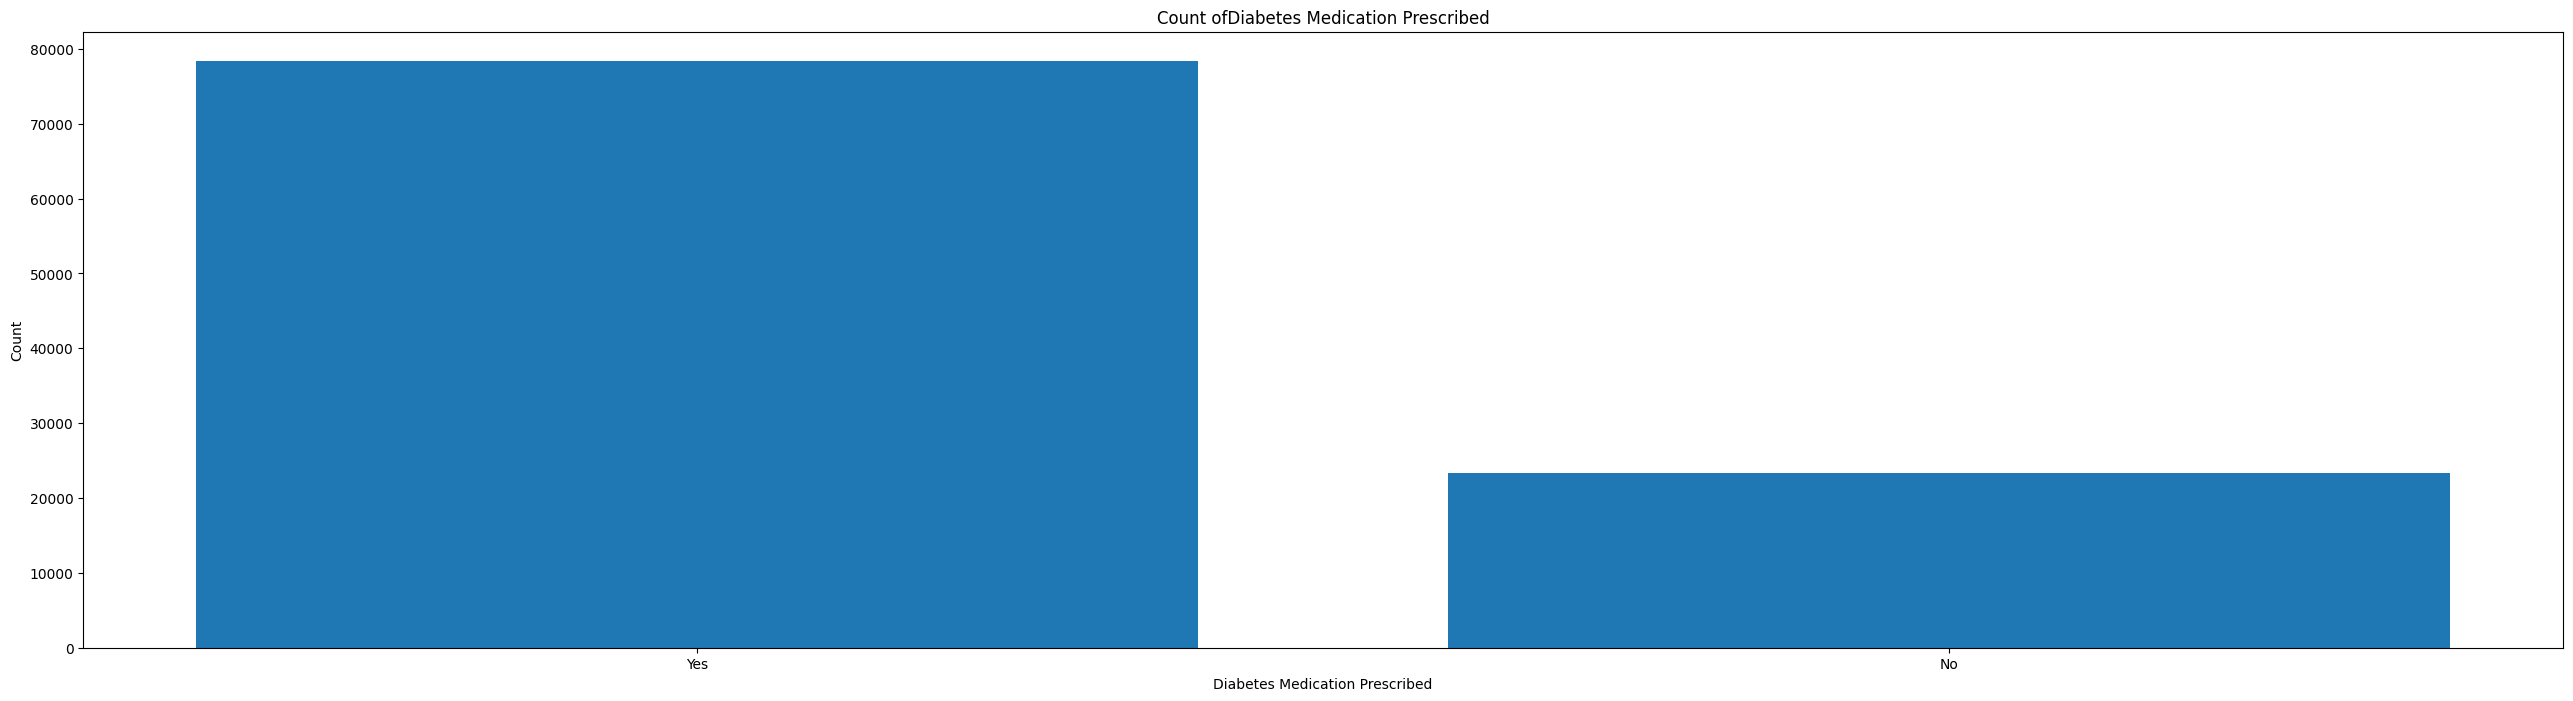

In [8]:
cat_feats = [
    "Race",
    "Gender",
    "Age",
    "Weight",
    "Payer",
    "Doctor Specialization",
    "Primary Diagnosis",
    "Secondary Diagnosis",
    "Additional Secondary Diagnosis",
    "Max Glucose Serum Result",
    "A1C Test Result",
    "Metformin Dosage",
    "Repaglinide Dosage",
    "Nateglinide Dosage",
    "Chlorproamide Dosage",
    "Glimepiride Dosage",
    "Acetohexamide Dosage",
    "Glipizide Dosage",
    "Glyburide Dosage",
    "Tolbutamide Dosage",
    "Pioglitazone Dosage",
    "Rosiglitazone Dosage",
    "Acarbose Dosage",
    "Miglitol Dosage",
    "Troglitazone Dosage",
    "Tolazamide Dosage",
    "Examide Dosage",
    "Citoglipton Dosage",
    "Insulin Dosage",
    "Glyburide-Metoformin Dosage",
    "Glipizide-Metformin Dosage",
    "Glimepiride-Pioglitazone Dosage",
    "Metformin-Rosiglitazone Dosage",
    "Metformin-Pigolitazone Dosage",
    "Change in Dosages",
    "Diabetes Medication Prescribed"
]

for feat in cat_feats:
    plt.figure(figsize=(32,8))
    feat_count = df[feat].value_counts()
    plt.bar(x=feat_count[feat], height=feat_count["count"])
    plt.xlabel(feat)
    plt.ylabel("Count")
    plt.title("Count of" + feat)
    plt.show()

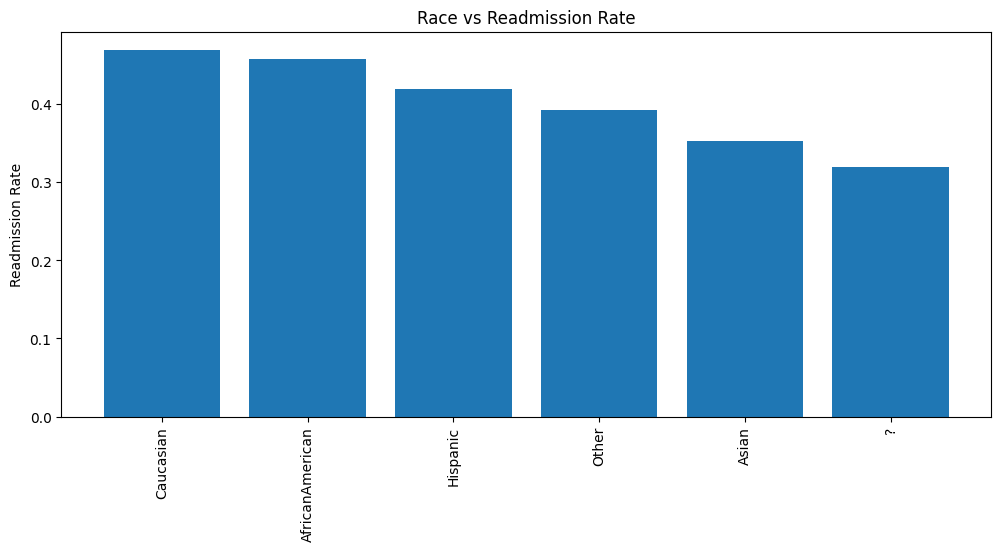

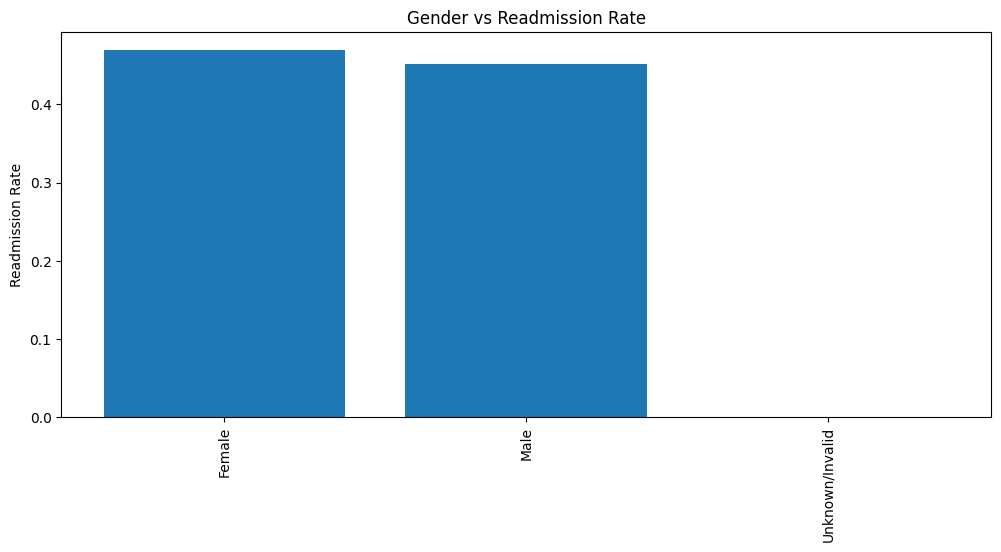

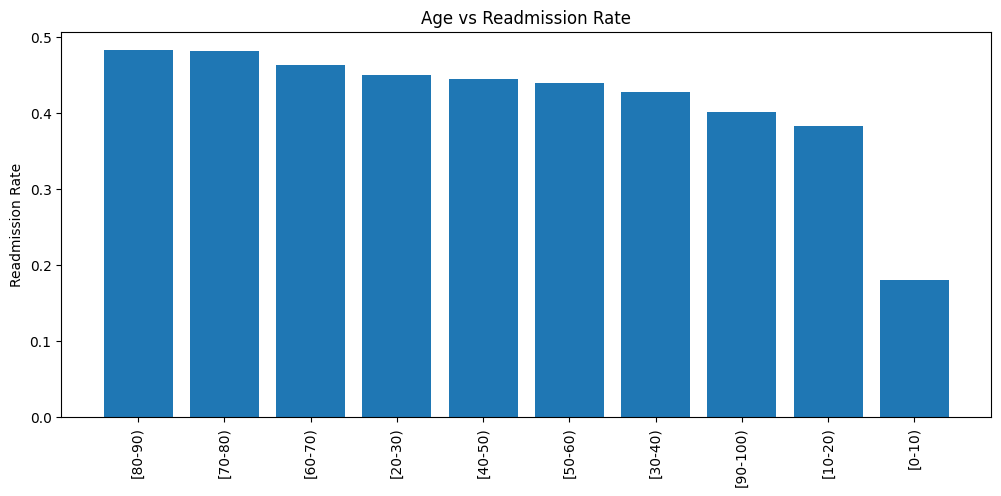

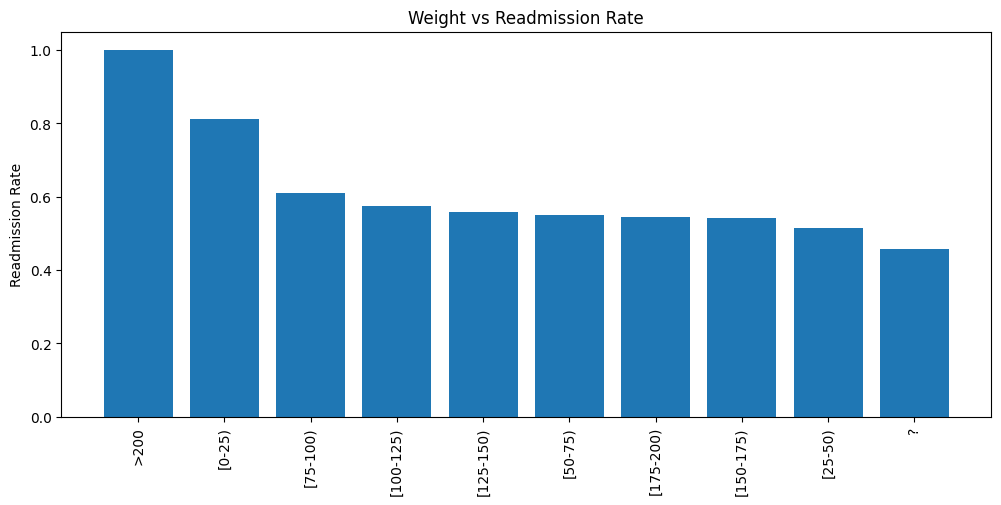

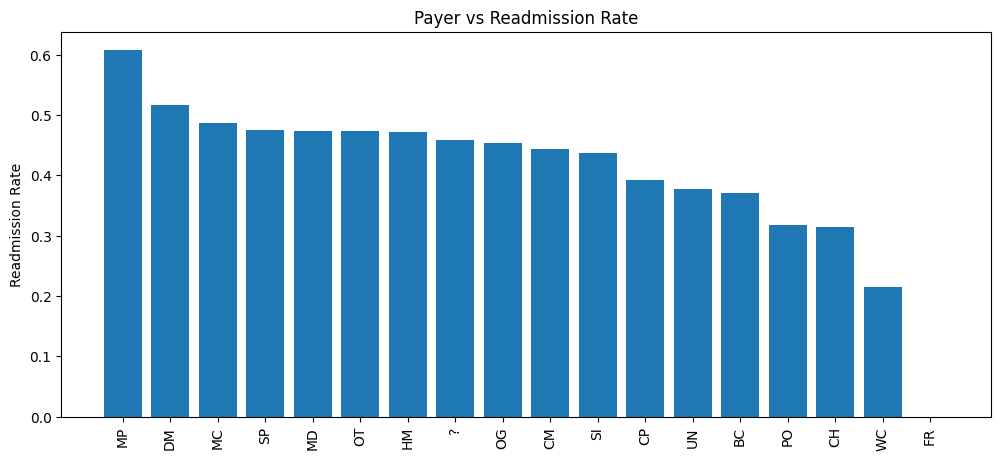

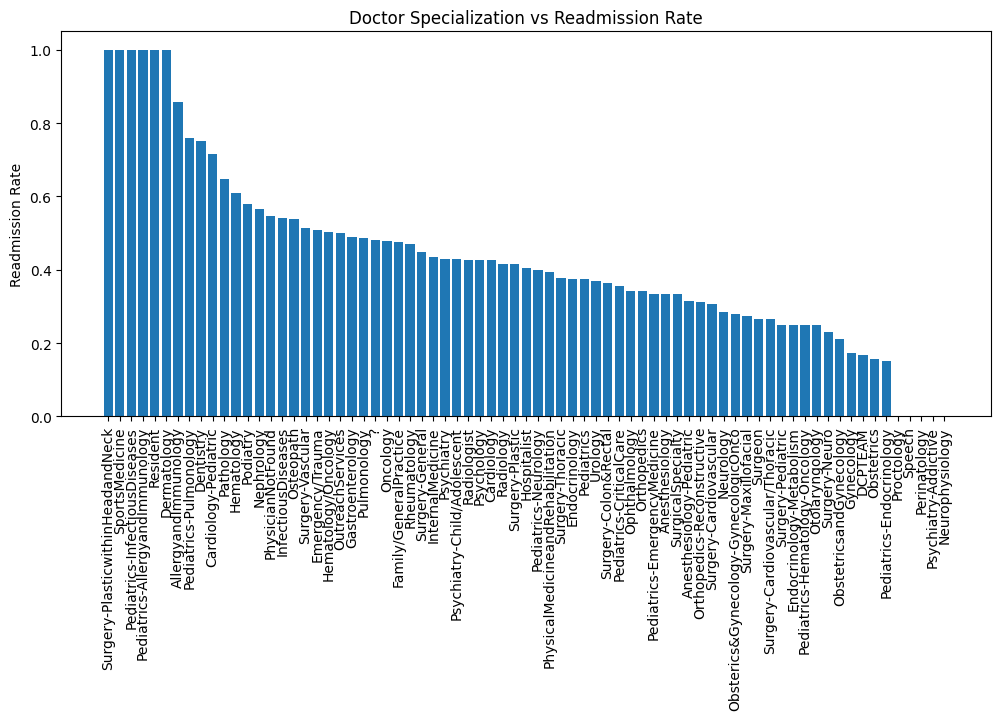

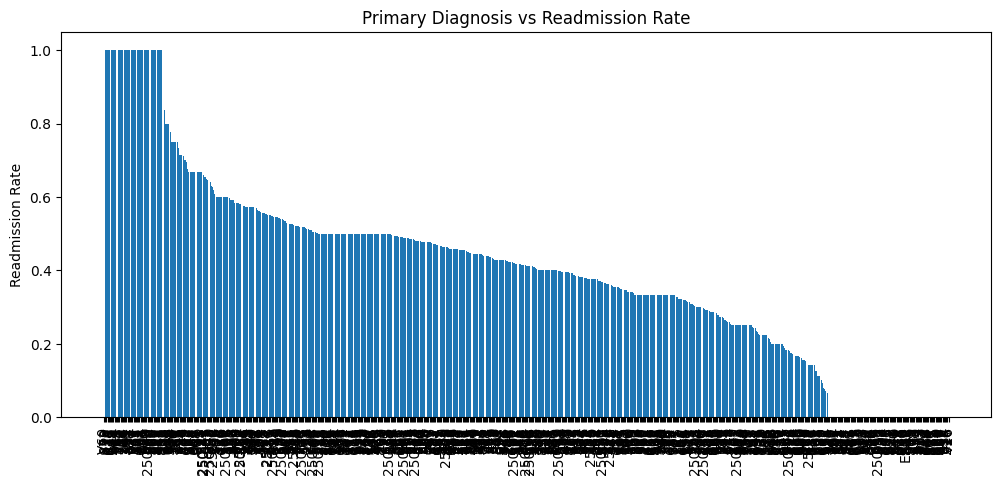

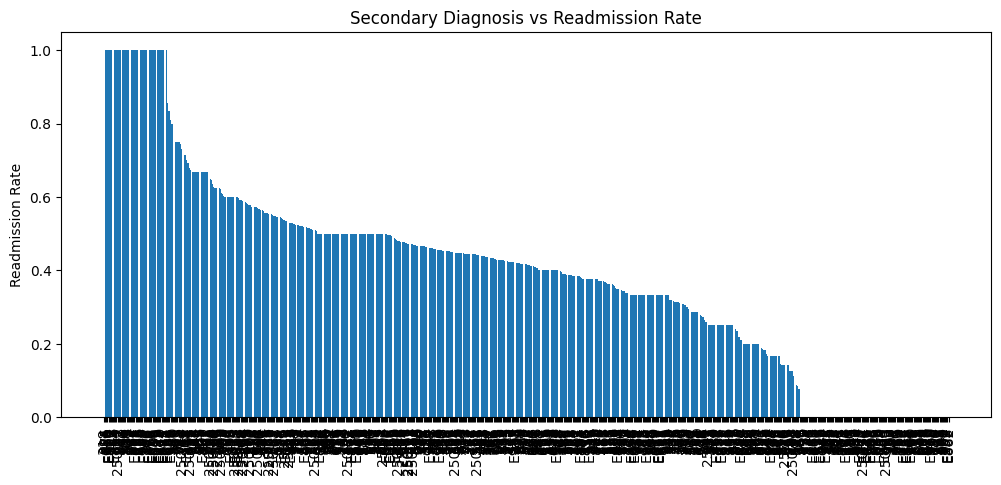

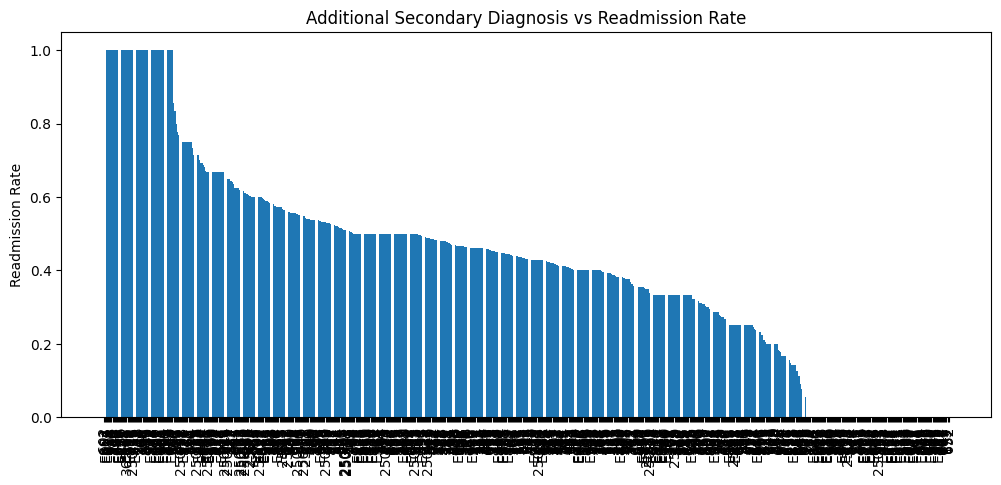

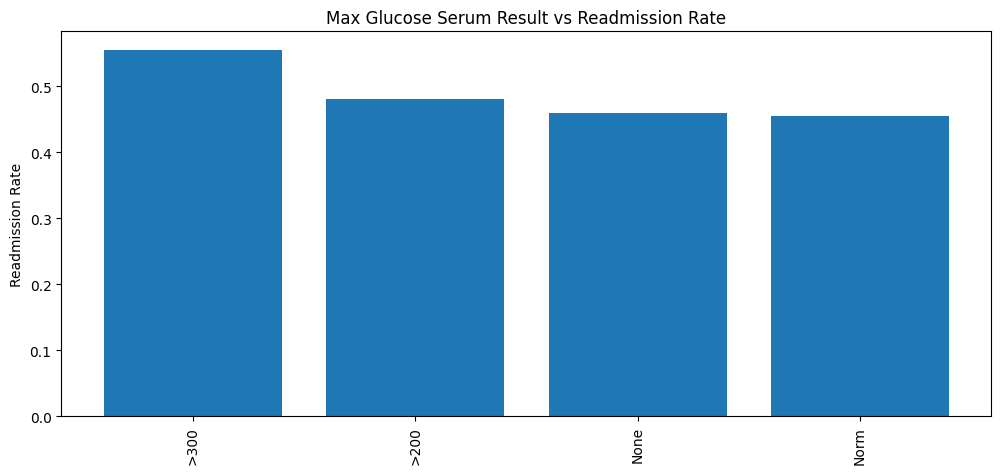

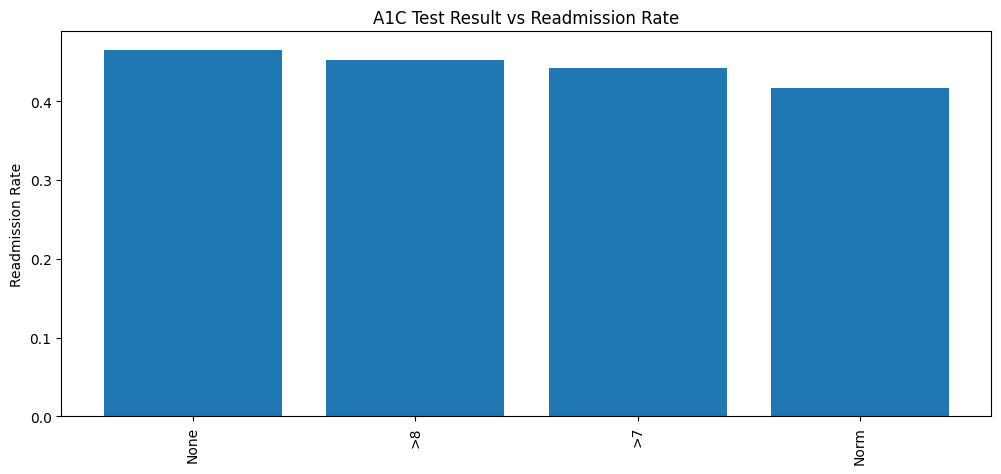

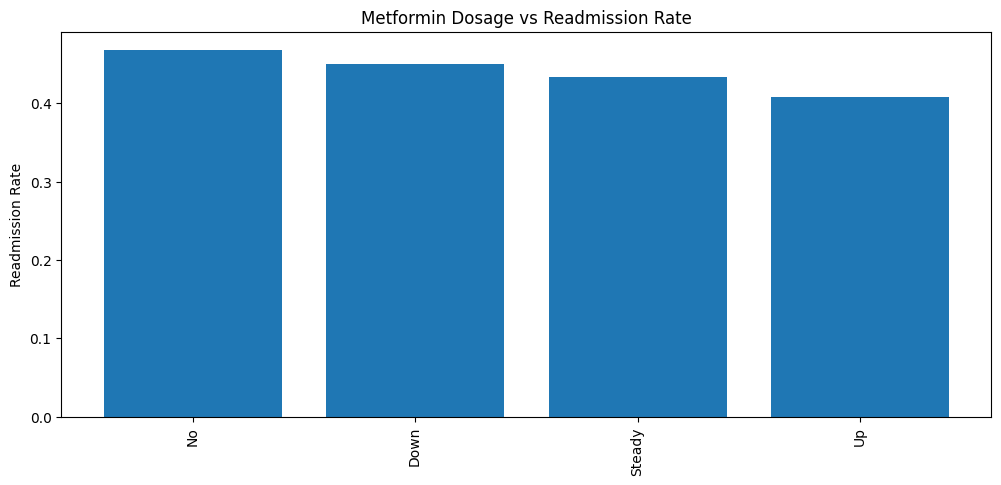

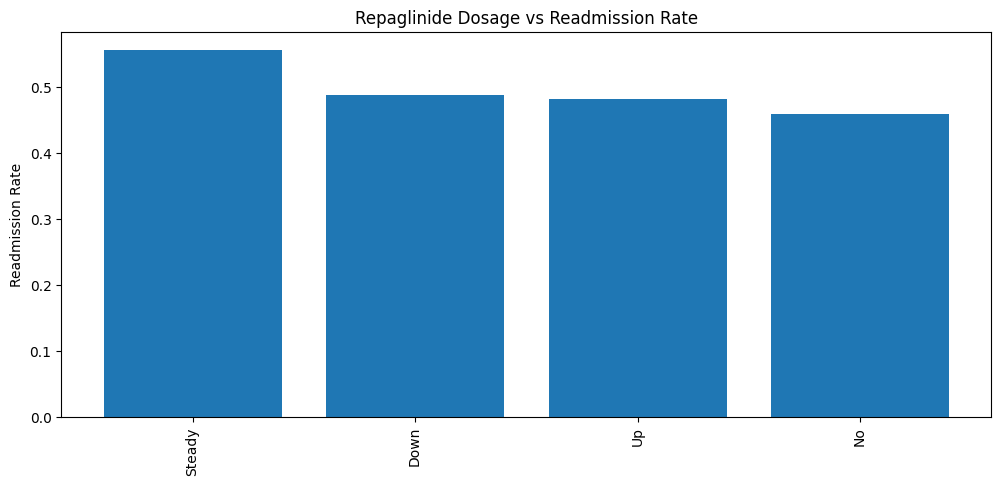

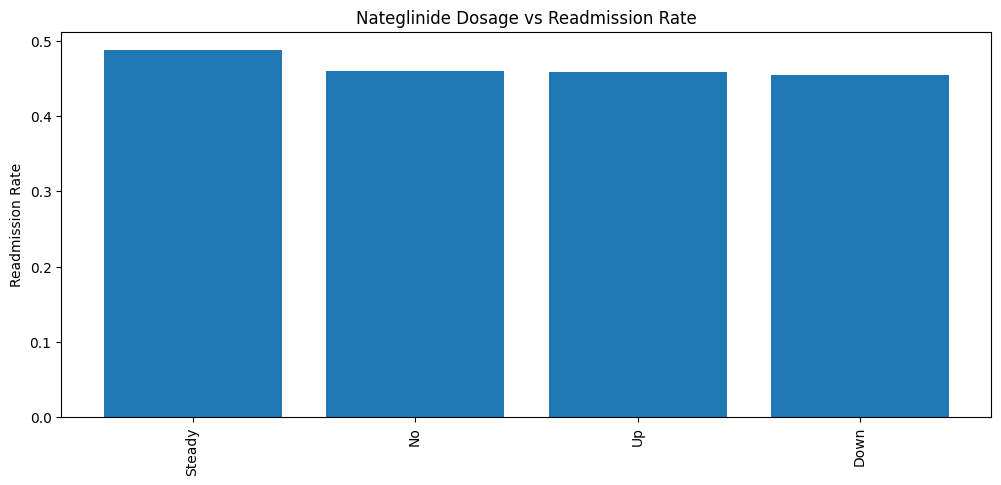

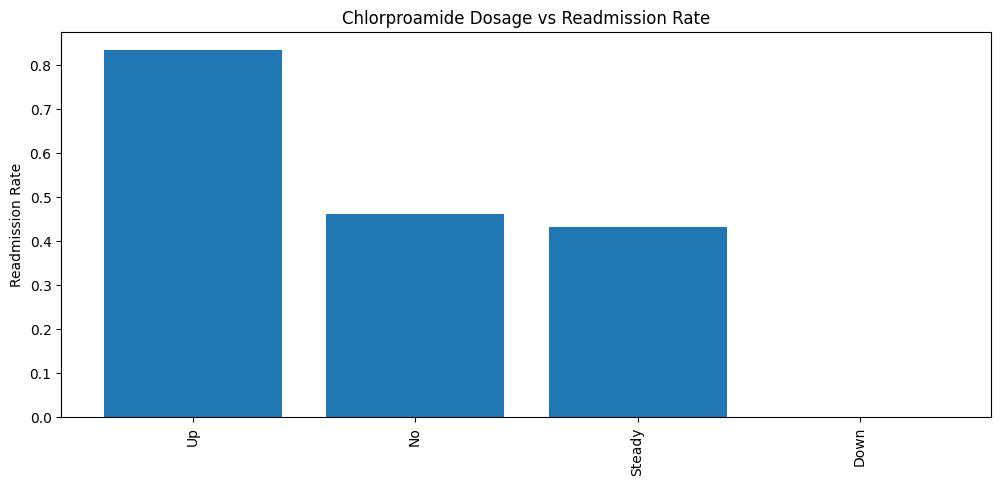

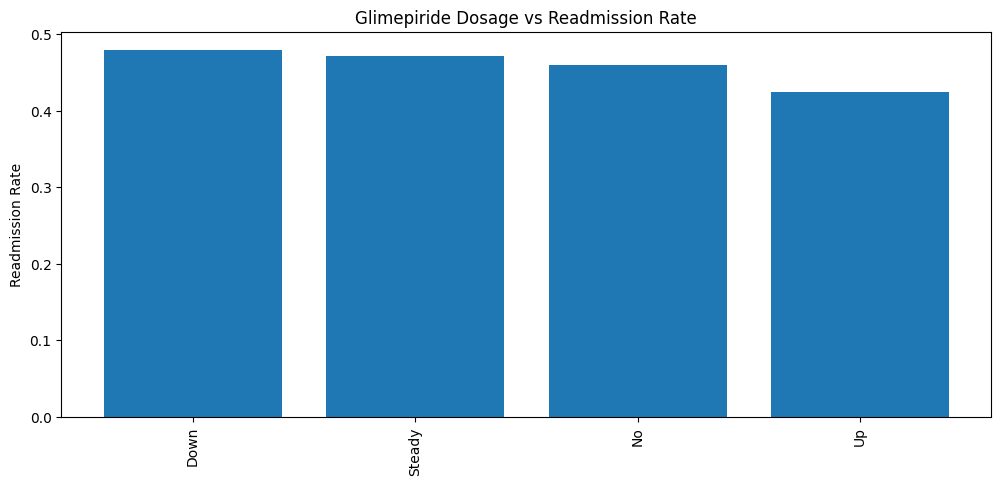

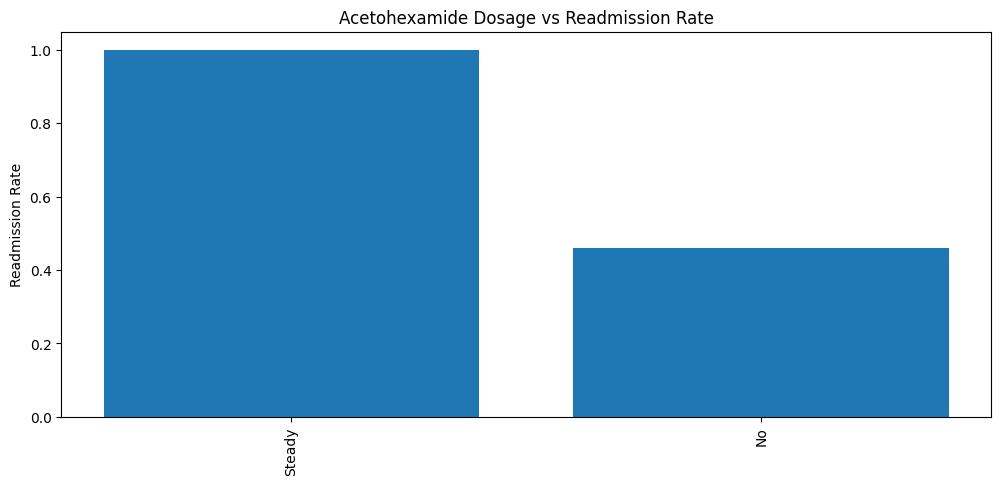

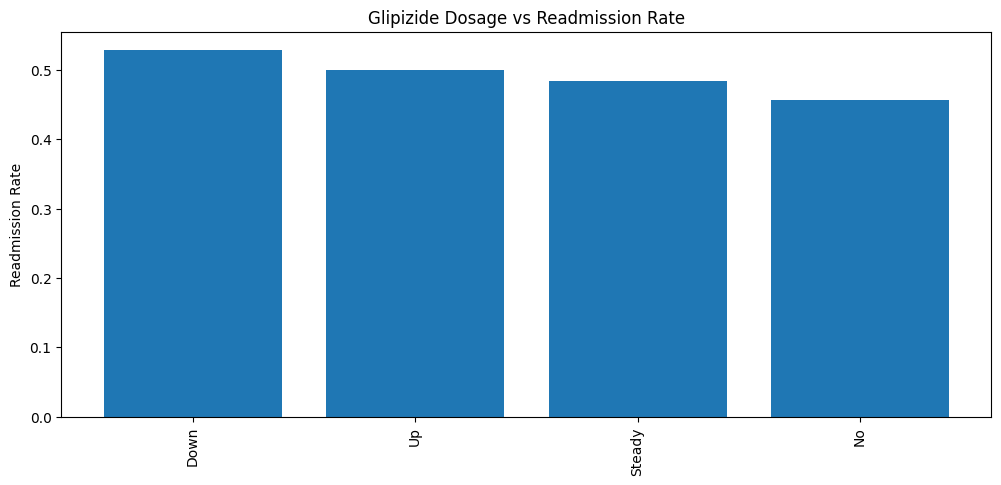

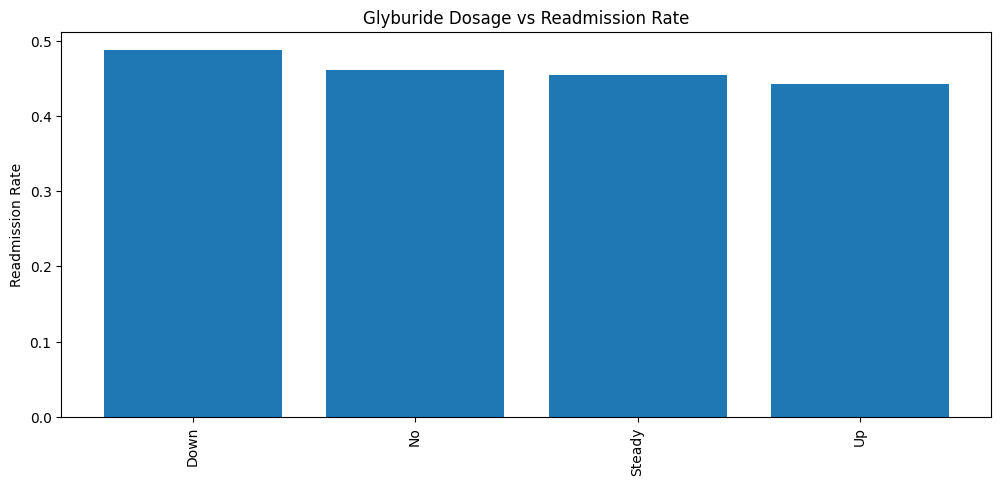

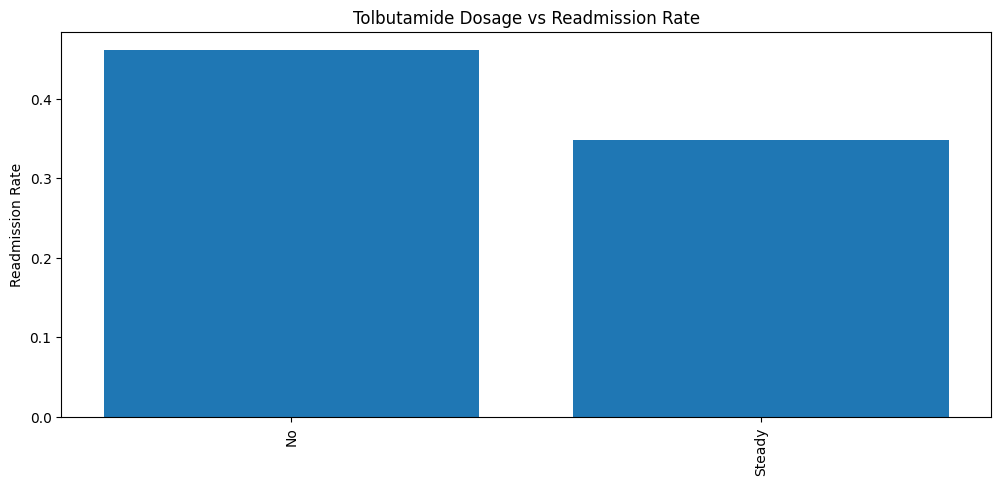

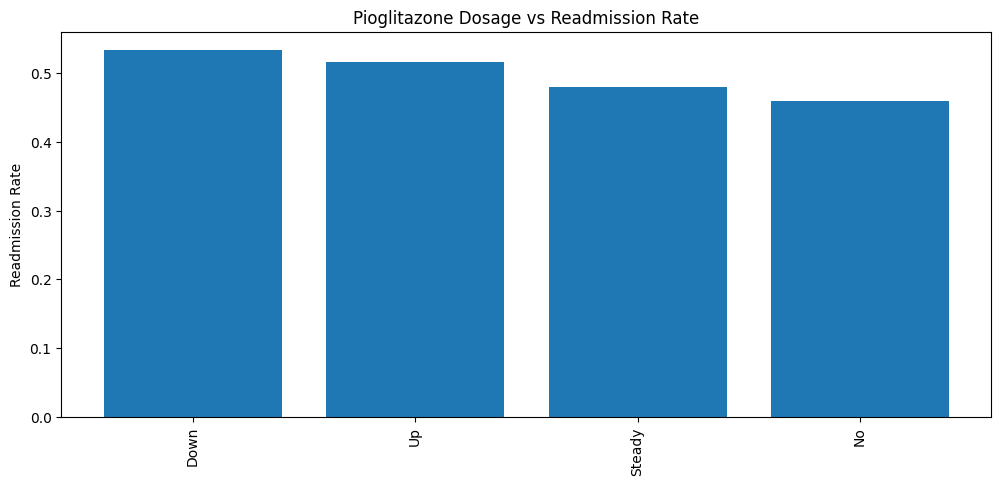

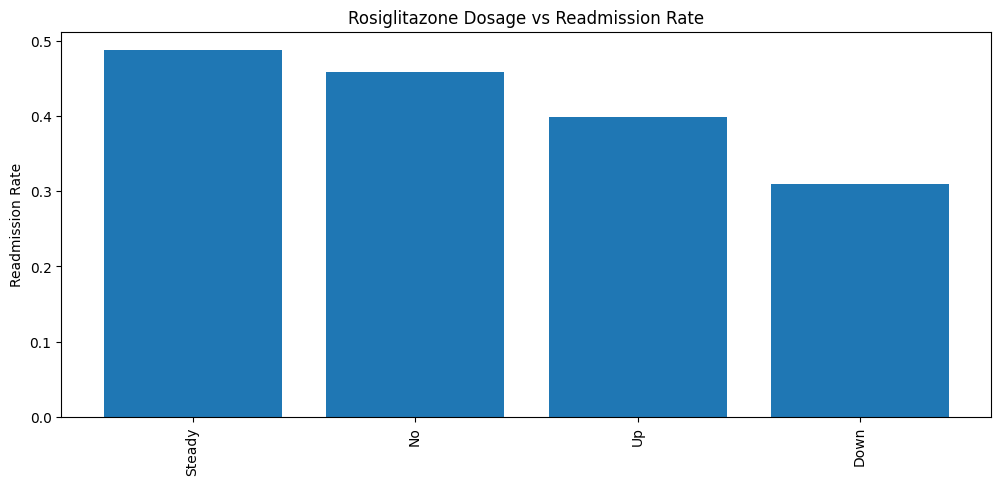

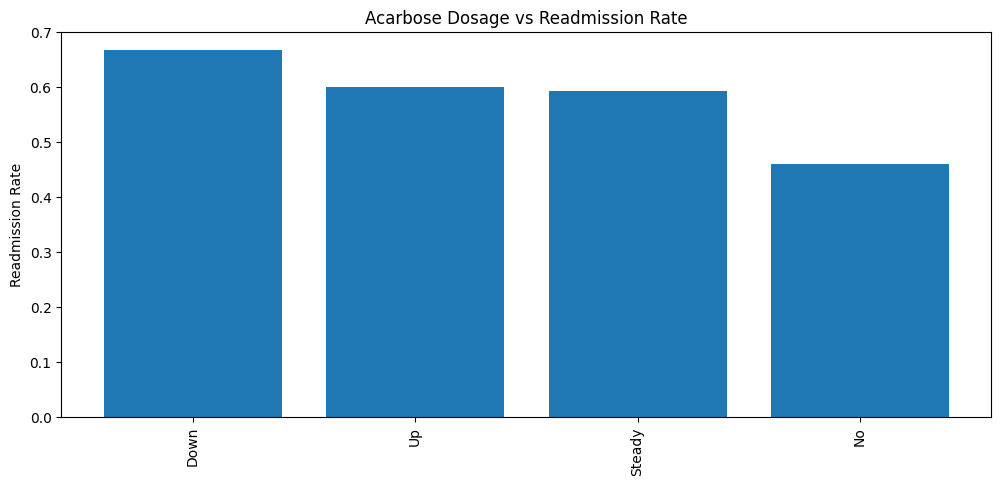

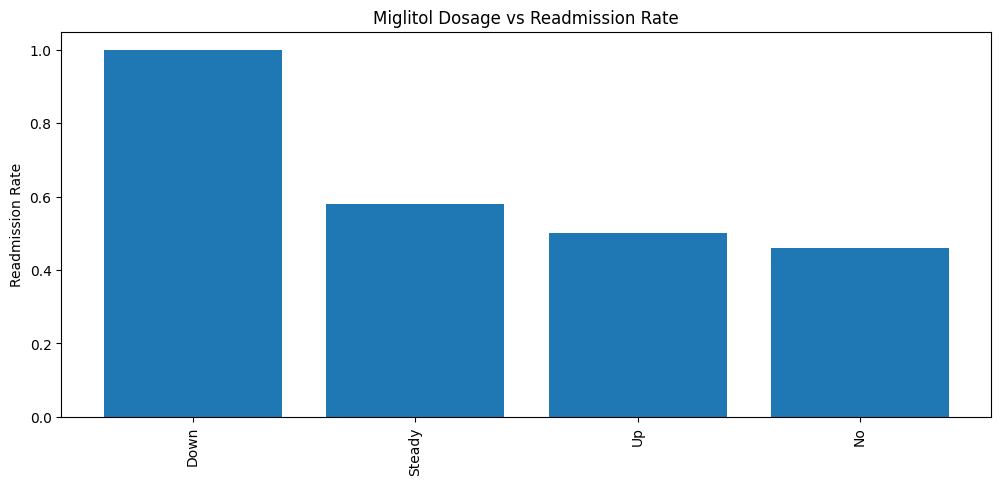

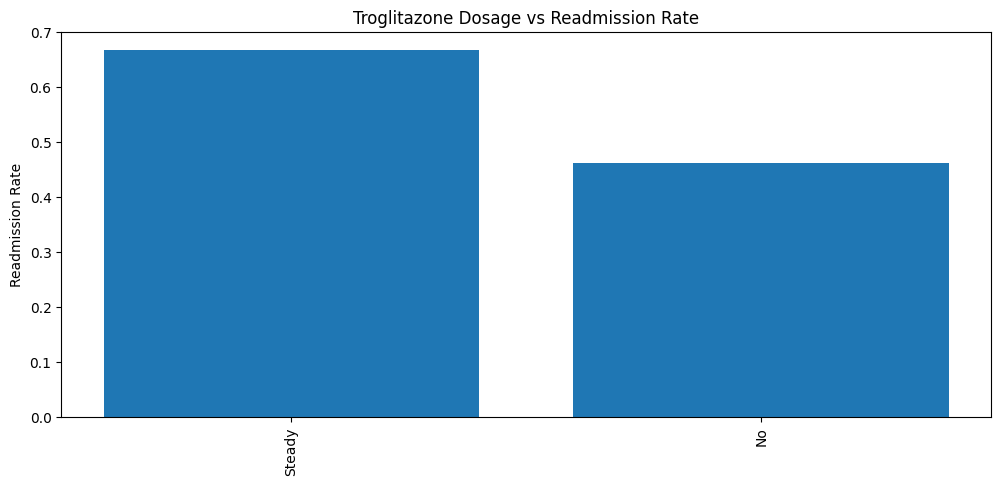

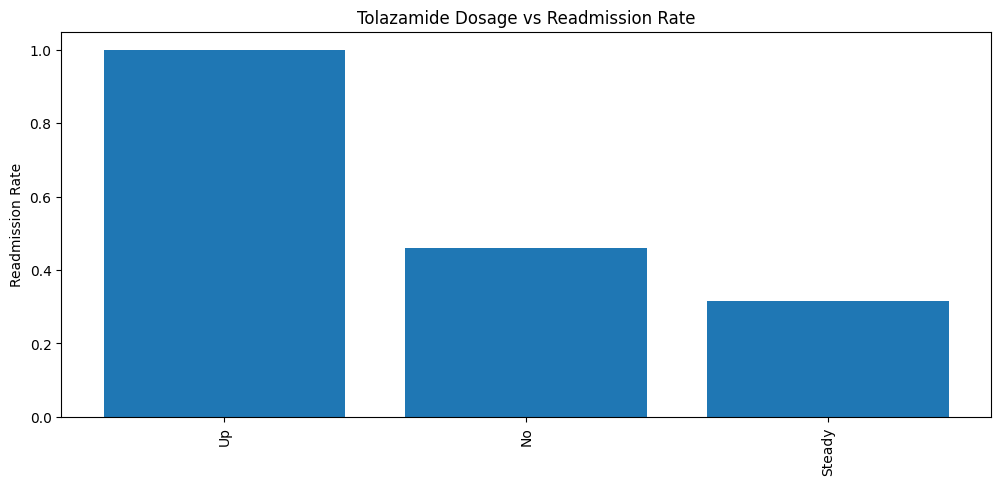

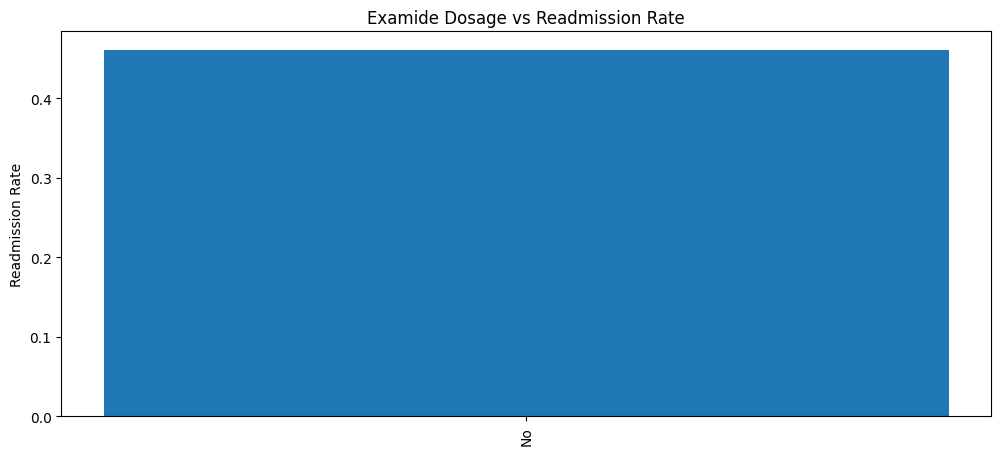

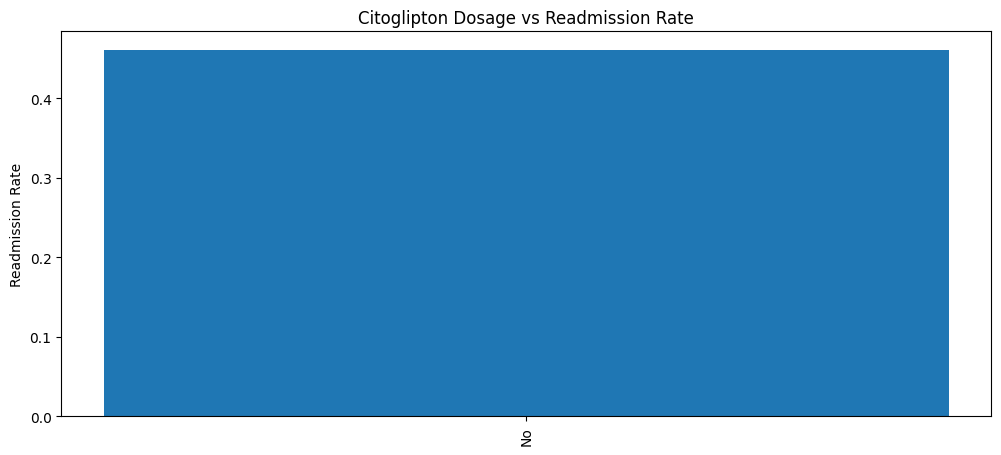

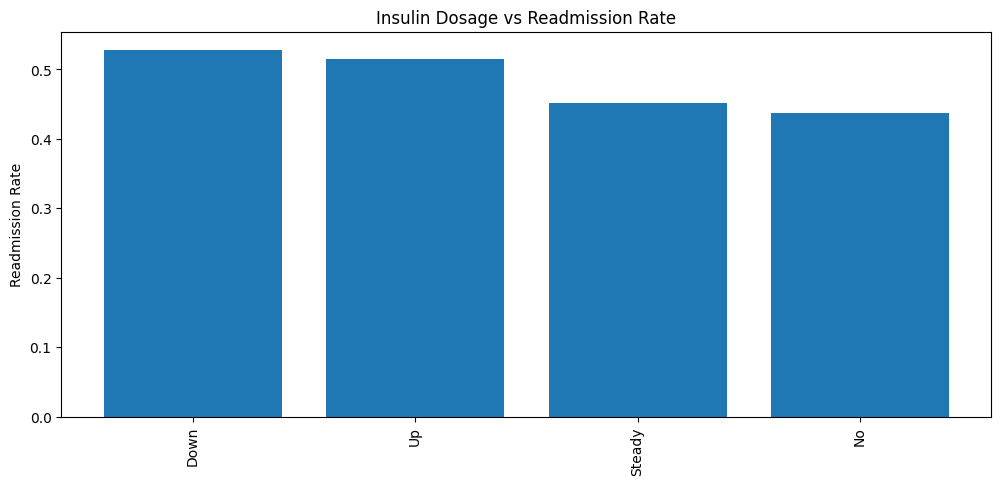

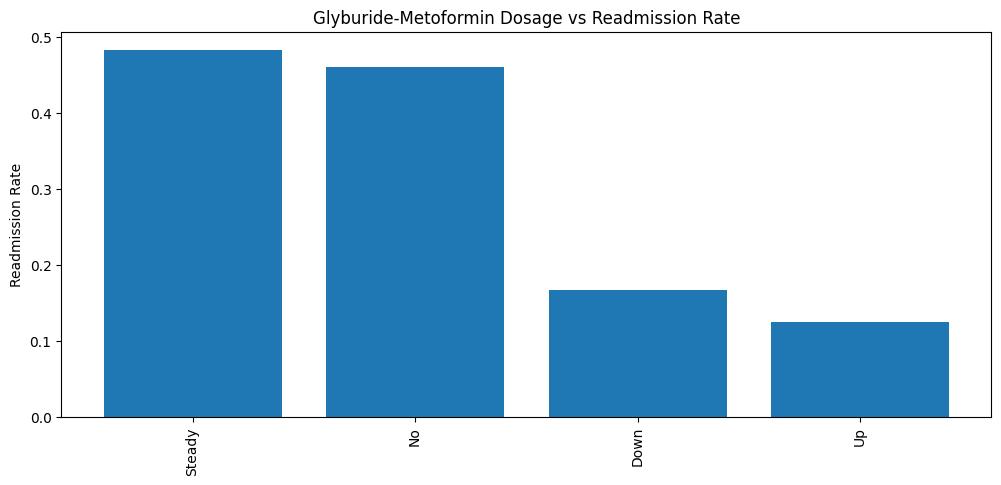

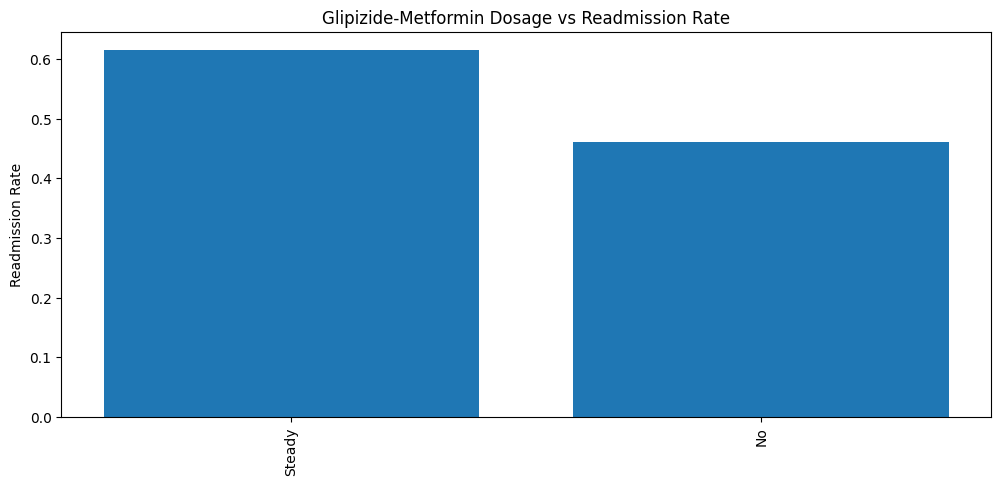

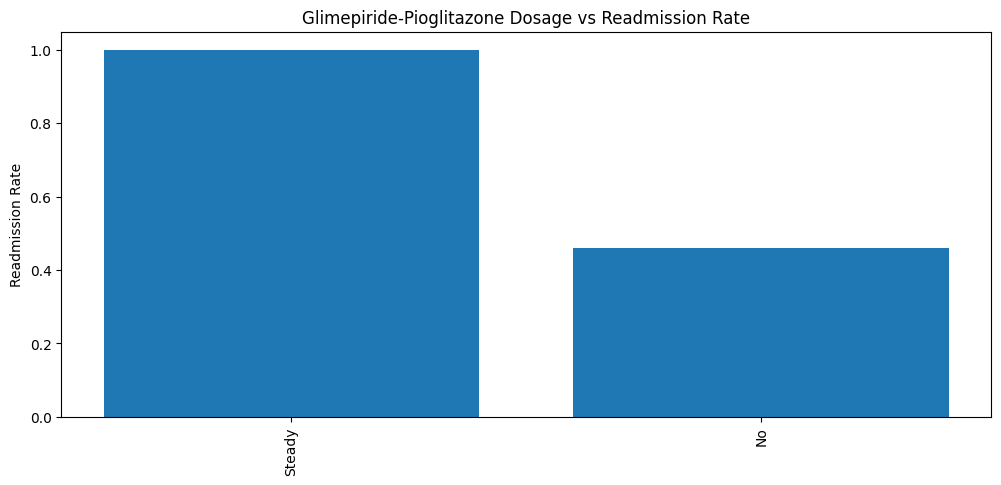

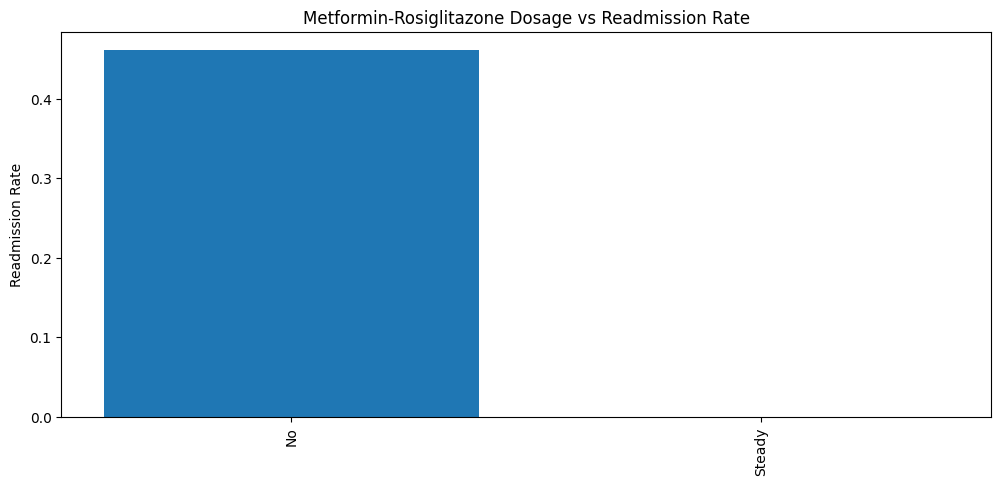

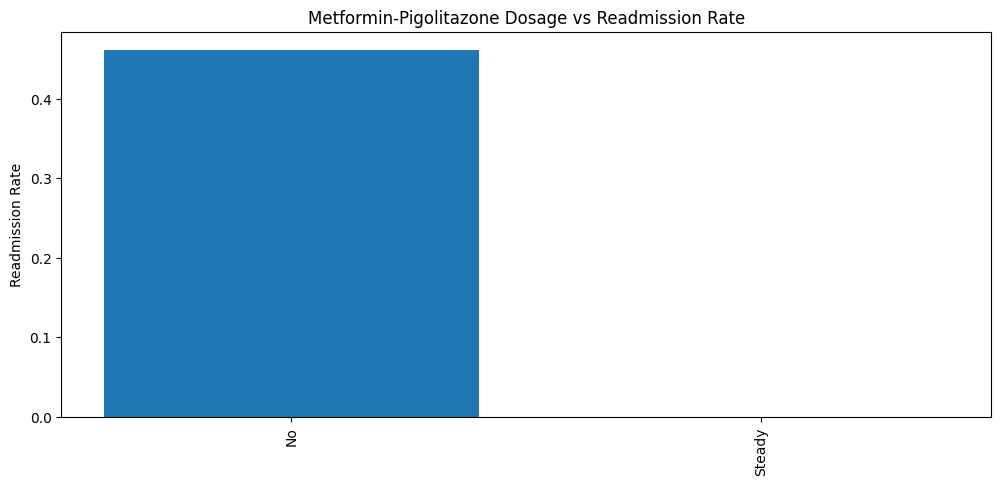

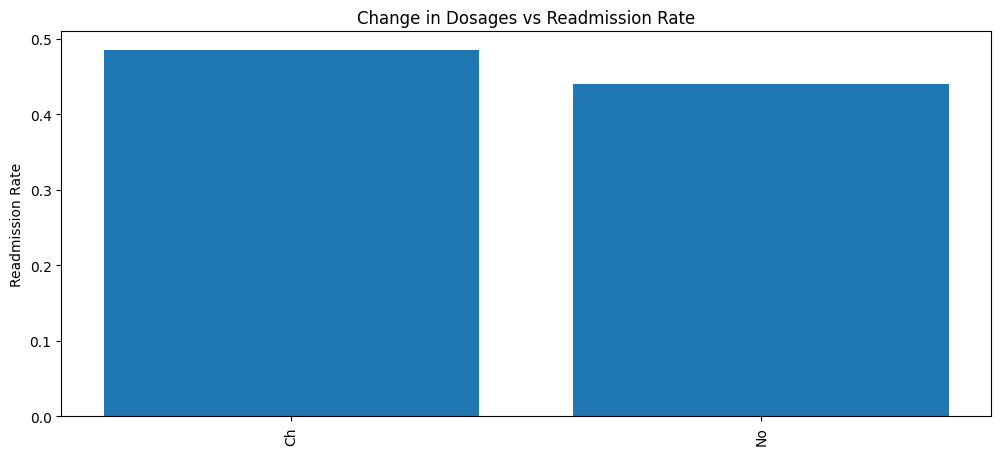

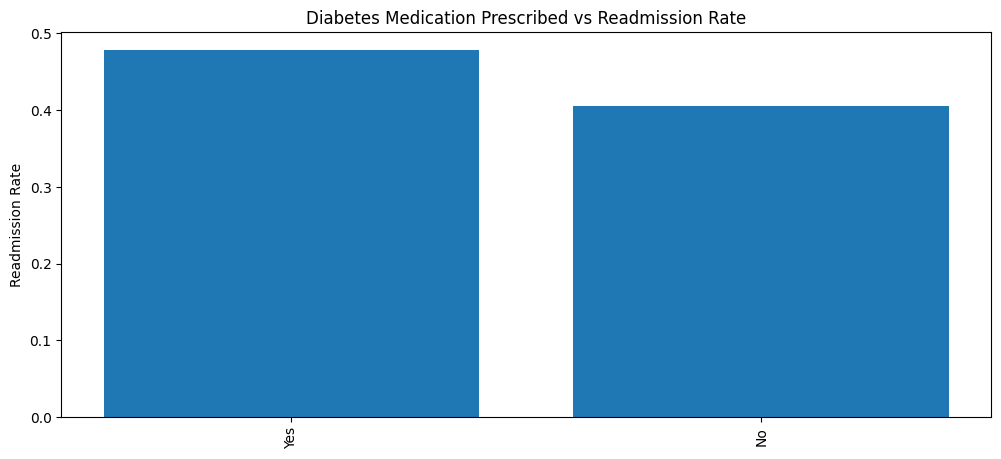

In [9]:
for feat in cat_feats:
    grouped = (
        df.group_by(feat)
        .agg(
            pl.mean("Readmitted").alias("readmit_rate"),
            pl.len().alias("count")
        )
        .sort("readmit_rate", descending=True)
    )

    plt.figure(figsize=(12,5))
    plt.bar(grouped[feat], grouped["readmit_rate"])
    plt.xticks(rotation=90)
    plt.ylabel("Readmission Rate")
    plt.title(f"{feat} vs Readmission Rate")
    plt.show()

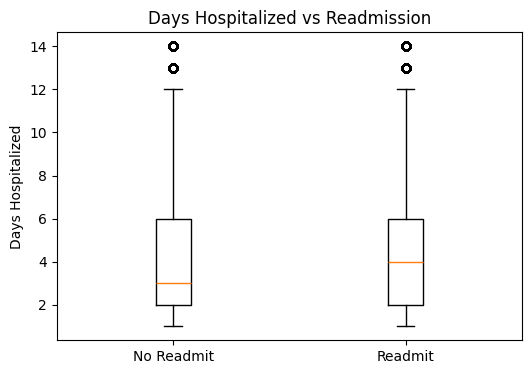

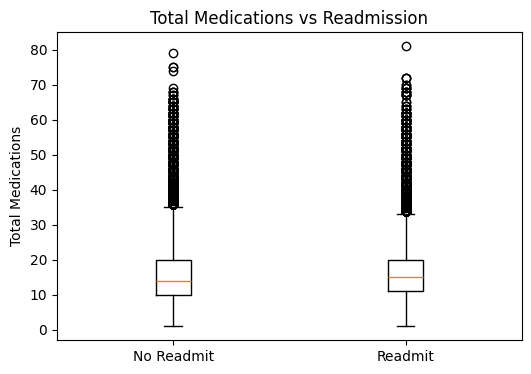

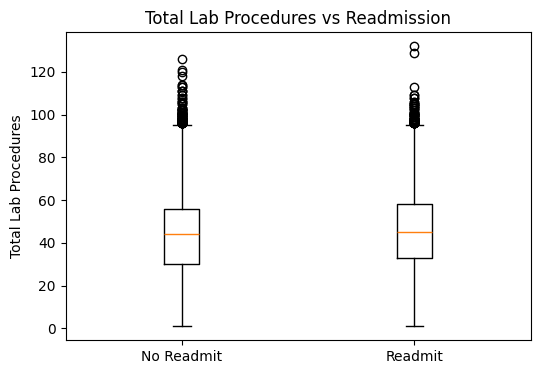

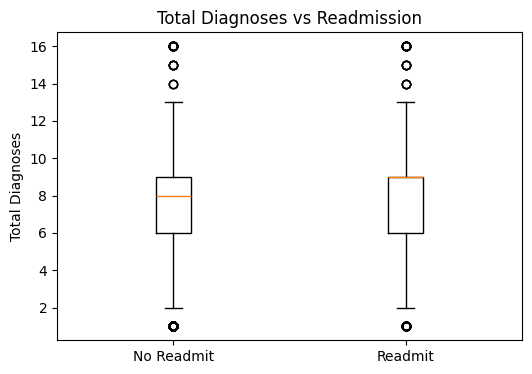

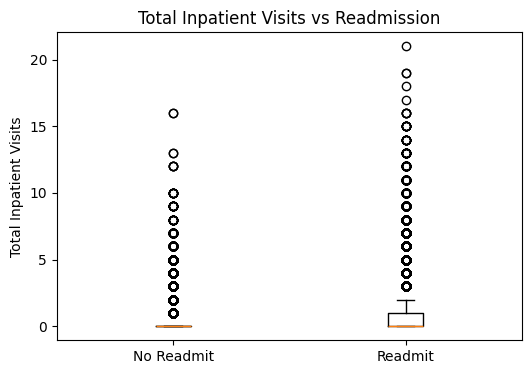

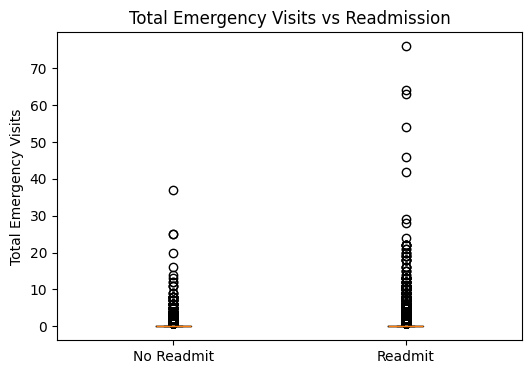

In [10]:
num_feats = [
    "Days Hospitalized",
    "Total Medications",
    "Total Lab Procedures",
    "Total Diagnoses",
    "Total Inpatient Visits",
    "Total Emergency Visits"
]


for feat in num_feats:
    # split into two groups using Polars
    yes = df.filter(pl.col("Readmitted") == 1)[feat].drop_nulls().to_list()
    no = df.filter(pl.col("Readmitted") == 0)[feat].drop_nulls().to_list()

    plt.figure(figsize=(6,4))
    plt.boxplot([no, yes], tick_labels=["No Readmit", "Readmit"])
    plt.title(f"{feat} vs Readmission")
    plt.ylabel(feat)
    plt.show()

In [11]:
# Get the baseline accuracy for readmission 

total_count = df.height 
baseline_acc = df["Readmitted"].value_counts(sort=True)["count"][0] / total_count 
print(f"Baseline Accuracy: {baseline_acc:.2%}")

Baseline Accuracy: 53.91%
